# Notebook 06 — Test-split main figures and end-of-day deliverable

**Purpose.** This notebook regenerates the Figure 6 panel family on the
**held-out 175-image test split**.

**Scope.** No model inference, training, optimisation, or matching is rerun.
Every number is derived from the frozen benchmark artefacts under
`release/frozen_results/or_matching/`, which are treated as read-only inputs.
Panels are regenerated with a `split == "test"` filter applied before pooling.


## Output location

`release/figures/` and `release/frozen_results/` are write-protected by design
(`chmod a-w`, applied 30 August 2026). All output from this notebook is written
to a fresh dated run directory:

`/proj/brunk_ecdna_cv_project/Poorya/runs/figures_2026-08-31/`


## What this notebook produces

| Section | Output | Purpose |
|---|---|---|
| §1 | `source_fig6_test_validation.csv` | Pooled test-split metrics checked against the locked table |
| §2 | `fig6_test_f1_overall.{svg,png}` + source CSV | Object-level F1, six models, test split |
| §3 | `fig6_test_f1_by_cell_line.{svg,png}` + heatmap + source CSV | Object-level F1 stratified by cell line |
| §4 | `fig6_test_f1_by_density.{svg,png}` + source CSV | Object-level F1 stratified by ecDNA density |
| §5 | `fig6_test_count_mae.{svg,png}` + source CSV | Count MAE and mean signed bias |
| §6 | `fig6_test_count_agreement.{svg,png}` + top-three variant + source CSVs | Predicted versus gold-standard count |
| §7 | `source_fig6_test_vs_all_locked_numbers.csv` | Test versus full-benchmark reference table |
| §8 | Console inventory | Locates the drug-treatment notebook for item B |
| §9 | `notebook06_output_manifest.csv`, `figure_captions_2026-08-31.md` | Deliverable manifest and draft captions |

## Matching policy

All panels use the canonical operating point: **OR matching, `d_max = 20 px`,
`IoU_min = 0.1`, `alpha = 0.5`, 8-connectivity, minimum object area 3 px.**

## Aggregation rule

Object-level F1 is **pooled (micro-averaged)**: `obj_tp`, `obj_fp` and `obj_fn`
are summed across the filtered rows first, and F1 is computed from the sums.
Per-image F1 is never averaged. The two differ materially (0.942 versus 0.931 on
the full benchmark), and pooled is the locked headline convention, Decision D11.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import json
import platform
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

from IPython.display import display

# ── Kernel check ────────────────────────────────────────────────────────────
# The canonical environment is envs/ecdna-bench. ecDNA_Hybrid is retired: it
# carries older matplotlib and scipy, and its panel spacing differs from the
# canonical kernel. Set ALLOW_ANY_KERNEL = True only to override deliberately.

ALLOW_ANY_KERNEL = False

print(f'Python executable : {sys.executable}')
print(f'Python version    : {platform.python_version()}')
print(f'matplotlib        : {matplotlib.__version__}')
print(f'pandas            : {pd.__version__}')
print(f'numpy             : {np.__version__}')

if 'envs/ecdna-bench' not in sys.executable and not ALLOW_ANY_KERNEL:
    raise RuntimeError(
        'This notebook must run on the "ecdna-bench (canonical)" kernel.\n'
        f'Current interpreter: {sys.executable}\n'
        'Switch kernel via Kernel > Change kernel, or set ALLOW_ANY_KERNEL = True '
        'if you are deliberately running elsewhere.'
    )

# ── Repository root ─────────────────────────────────────────────────────────
REPO_ROOT = Path('/proj/brunk_ecdna_cv_project/Poorya/ecdna-bench')

if not (REPO_ROOT / 'pyproject.toml').exists():
    candidate = Path(os.getcwd()).resolve()
    for probe in [candidate, candidate.parent, candidate.parent.parent]:
        if (probe / 'pyproject.toml').exists():
            REPO_ROOT = probe
            break

if not (REPO_ROOT / 'pyproject.toml').exists():
    raise FileNotFoundError(
        'Could not locate the repository root containing pyproject.toml. '
        f'Tried {REPO_ROOT} and the working directory {Path(os.getcwd()).resolve()}.'
    )

SRC_DIR = REPO_ROOT / 'src'
IMPORT_DIR = SRC_DIR if SRC_DIR.exists() else REPO_ROOT
if str(IMPORT_DIR) not in sys.path:
    sys.path.insert(0, str(IMPORT_DIR))

REPO = REPO_ROOT
print(f'\nRepo root         : {REPO_ROOT}')

# ── Frozen inputs (read-only) ───────────────────────────────────────────────
RELEASE = REPO_ROOT / 'release'
FROZEN_ROOT = RELEASE / 'frozen_results'
FROZEN_OR = FROZEN_ROOT / 'or_matching'
FROZEN_AND = FROZEN_ROOT / 'and_matching'
MANIFESTS = RELEASE / 'manifests'

# Hard stop: OR matching is canonical. AND matching holds identically named
# files and inverts the ecCount peaks versus threshold ranking.
assert FROZEN_OR.name == 'or_matching', (
    f'Expected the or_matching directory, got: {FROZEN_OR}'
)
if not FROZEN_OR.exists():
    raise FileNotFoundError(f'Frozen OR-matching directory not found: {FROZEN_OR}')

# Source-data directories produced by the earlier notebooks.
NB01 = RELEASE / 'figures' / 'notebook01'
NB02 = RELEASE / 'figures' / 'notebook02'
NB03 = RELEASE / 'figures' / 'notebook03'
NB04 = RELEASE / 'figures' / 'notebook04'
NB05 = RELEASE / 'figures' / 'notebook05'

# Drug-treatment analysis notebook, used for items B and C.
DRUG_NB_DIR = Path('/proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning')

# River predicted ROI masks, used for item D.
RIVER_ROI_DIR = Path('/proj/brunk_ecdna_cv_project/Poorya/River/output/all')

# ── Output directory (fresh, dated, writable) ───────────────────────────────
RUN_DATE = '2026-08-31'
OUT_DIR = Path(f'/proj/brunk_ecdna_cv_project/Poorya/runs/figures_{RUN_DATE}')
OUT_DIR.mkdir(parents=True, exist_ok=True)
NB06 = OUT_DIR

# Confirm the frozen directories really are protected, and the output is not.
print(f'Frozen results    : {FROZEN_OR}  (writable={os.access(FROZEN_OR, os.W_OK)})')
print(f'Output directory  : {OUT_DIR}  (writable={os.access(OUT_DIR, os.W_OK)})')

if not os.access(OUT_DIR, os.W_OK):
    raise PermissionError(f'Output directory is not writable: {OUT_DIR}')

# ── Model order, palette, aliases ───────────────────────────────────────────
MODEL_ORDER_6 = [
    'ecCount (peaks)',
    'ecCount (threshold mask)',
    'Label Engine',
    'MIA',
    'Classic (after opt)',
    'ecSeg',
]
MODEL_ORDER = MODEL_ORDER_6

MODEL_COLORS = {
    'Classic (before opt)':      '#A0A0A0',
    'Classic (after opt)':       '#54A24B',
    'Label Engine':              '#E45756',
    'ecSeg':                     '#B279A2',
    'MIA':                       '#4C78A8',
    'ecCount (threshold mask)':  '#9C755F',
    'ecCount (peaks)':           '#F58518',
}
MODEL_COLOURS = MODEL_COLORS

MODEL_ALIASES = {
    'classical_before_opt':      'Classic (before opt)',
    'classic_before_opt':        'Classic (before opt)',
    'Classic before opt':        'Classic (before opt)',
    'Classic (before opt)':      'Classic (before opt)',

    'classical':                 'Classic (after opt)',
    'classical_after_opt':       'Classic (after opt)',
    'classic_after_opt':         'Classic (after opt)',
    'Classic after opt':         'Classic (after opt)',
    'Classic (after opt)':       'Classic (after opt)',

    'label_engine':              'Label Engine',
    'Label Engine':              'Label Engine',

    'ecseg':                     'ecSeg',
    'ecSeg':                     'ecSeg',

    'mia':                       'MIA',
    'MIA':                       'MIA',

    'eccount_threshold':         'ecCount (threshold mask)',
    'ecCount threshold':         'ecCount (threshold mask)',
    'ecCount (threshold mask)':  'ecCount (threshold mask)',

    'eccount_peaks':             'ecCount (peaks)',
    'ecCount peaks':             'ecCount (peaks)',
    'ecCount (peaks)':           'ecCount (peaks)',
}

CELL_LINE_COLORS = {
    'NCI-H2170': '#E69F00',
    'SNU16':     '#009E73',
    'COLO320DM': '#CC79A7',
    'NCI-H716':  '#0072B2',
    'SUM159PT':  '#56B4E9',
}
CELL_LINE_COLOURS = CELL_LINE_COLORS

CL_ORDER = ['NCI-H2170', 'SNU16', 'COLO320DM', 'NCI-H716']
CELL_LINES = CL_ORDER

DENSITY_ORDER = ['0-9', '10-49', '50-149', '150-299', '300+']

# ── Canonical matching parameters ───────────────────────────────────────────
CANONICAL_D_MAX = 20
CANONICAL_IOU_MIN = 0.1
CANONICAL_ALPHA = 0.5
CANONICAL_POLICY = 'OR'
MIN_COMPONENT_AREA = 3

CAPTION_POLICY = (
    'OR matching, `d_max = 20 px`, `IoU_min = 0.1`, `alpha = 0.5`, '
    '8-connectivity, minimum object area 3 px.'
)

# ── Publication style (identical to Notebooks 03 and 05) ────────────────────
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':         7,
    'axes.titlesize':    8,
    'axes.labelsize':    7,
    'xtick.labelsize':   6.2,
    'ytick.labelsize':   6.2,
    'legend.fontsize':   6.2,
    'figure.titlesize':  8,
    'axes.linewidth':    0.8,
    'lines.linewidth':   1.2,
    'lines.markersize':  4,
    'savefig.dpi':       300,
    'svg.fonttype':      'none',
    'pdf.fonttype':      42,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ── Helper functions ────────────────────────────────────────────────────────
def save_fig(fig, name):
    """Save a figure as SVG and PNG in OUT_DIR."""
    svg_path = OUT_DIR / f'{name}.svg'
    png_path = OUT_DIR / f'{name}.png'
    fig.savefig(svg_path, format='svg', bbox_inches='tight')
    fig.savefig(png_path, format='png', dpi=150, bbox_inches='tight')
    print(f'  Saved: {svg_path.name}')
    print(f'  Saved: {png_path.name}')


save_panel = save_fig


def save_source(df, name):
    """Write a source-data CSV for one panel and report the path."""
    path = OUT_DIR / f'{name}.csv'
    df.to_csv(path, index=False)
    print(f'  Saved source data: {path.name}  ({len(df):,} rows)')
    return path


def canonical_cell_line(x):
    """Standardise cell-line labels for display and grouping."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper().replace('-', '').replace('_', '').replace(' ', '')
    return {
        'NCIH2170':  'NCI-H2170',
        'SUM159PT':  'SUM159PT',
        'SNU16':     'SNU16',
        'COLO320DM': 'COLO320DM',
        'NCIH716':   'NCI-H716',
    }.get(s, str(x).strip())


def canonical_model_name(x):
    """Standardise model labels across frozen CSV revisions."""
    if pd.isna(x):
        return np.nan
    raw = str(x).strip()
    if raw in MODEL_ALIASES:
        return MODEL_ALIASES[raw]
    key = raw.lower().replace('-', '_').replace(' ', '_')
    key = key.replace('(', '').replace(')', '')
    return MODEL_ALIASES.get(key, raw)


def find_metric_column(df, candidates, label):
    """Return the first matching metric column from a list of aliases."""
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(
        f'Could not find {label}. Tried {candidates}. '
        f'Available columns: {list(df.columns)}'
    )


def require_file(path, label=None):
    """Fail loudly if a required file is missing."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'{label or "Required file"} not found: {path}')
    return path


def pooled_f1(tp, fp, fn):
    """Micro-averaged object F1 from summed counts. Never average per-image F1."""
    denom = 2 * tp + fp + fn
    return np.where(denom > 0, (2 * tp) / denom, np.nan)


def pool_by(df, keys):
    """Sum obj_tp/obj_fp/obj_fn over `keys`, then compute pooled F1 and counts."""
    if isinstance(keys, str):
        keys = [keys]
    out = (
        df.groupby(keys, observed=False, as_index=False)
          .agg(
              n_images=('uid', 'nunique'),
              tp=('obj_tp', 'sum'),
              fp=('obj_fp', 'sum'),
              fn=('obj_fn', 'sum'),
              count_mae=('count_abs_error', 'mean'),
              count_bias=('signed_count_error', 'mean'),
              count_median_ae=('count_abs_error', 'median'),
          )
    )
    out['object_f1'] = pooled_f1(out['tp'], out['fp'], out['fn'])
    out['precision'] = np.where(
        (out['tp'] + out['fp']) > 0, out['tp'] / (out['tp'] + out['fp']), np.nan
    )
    out['recall'] = np.where(
        (out['tp'] + out['fn']) > 0, out['tp'] / (out['tp'] + out['fn']), np.nan
    )
    return out


THREE_DP = lambda x: f'{x:.3f}'
ONE_DP = lambda x: f'{x:.1f}'
SIGNED_ONE_DP = lambda x: f'{x:+.1f}'

print('\nSetup complete.')
print(f'Run date          : {RUN_DATE}')
print(f'Model order ({len(MODEL_ORDER)} models):')
for model_name in MODEL_ORDER:
    print(f'  - {model_name}')

Python executable : /proj/brunk_ecdna_cv_project/Poorya/envs/ecdna-bench/bin/python
Python version    : 3.10.16
matplotlib        : 3.10.0
pandas            : 2.2.3
numpy             : 2.2.5

Repo root         : /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench
Frozen results    : /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/frozen_results/or_matching  (writable=False)
Output directory  : /proj/brunk_ecdna_cv_project/Poorya/runs/figures_2026-08-31  (writable=True)

Setup complete.
Run date          : 2026-08-31
Model order (6 models):
  - ecCount (peaks)
  - ecCount (threshold mask)
  - Label Engine
  - MIA
  - Classic (after opt)
  - ecSeg


## §1 — Load frozen metrics and validate the test split

This is the gate for the whole notebook. Nothing is drawn until the pooled
test-split numbers reproduce the locked table exactly.

`per_image_metrics.csv` holds 6,870 rows: 1,145 benchmark images × 6 models.
Filtering to `split == "test"` should leave **1,050 rows across 175 unique
images**.

For each model the notebook computes:

- **Object-level F1**, pooled — `obj_tp`, `obj_fp`, `obj_fn` summed across the
  175 images, then `F1 = 2·TP / (2·TP + FP + FN)`.
- **Count MAE** — the mean of `count_abs_error` over the 175 images.
- **Mean signed bias** — the mean of `pred_count − gt_count`.

### Four checks, in order

**1. AND-policy detection.** The single most dangerous failure mode in this
project is reading `and_matching/` while believing it is `or_matching/`. The two
directories hold identically named files. The signature is unmistakable: under
AND the ecCount peaks versus threshold ranking **inverts**, giving F1 0.709 for
peaks against 0.765 for threshold. A path assertion cannot catch a copied or
mislabelled directory, so the notebook additionally checks the ranking itself
and reports the AND reference values if it fires.

**2. Exact reconciliation of TP, FP and FN.** The pooled integer counts must
equal the authoritative values recorded in
`release/figures/notebook05/source_fig6_global_performance_bars.csv`, which is
the frozen record of the OR-policy benchmark for both the full benchmark and the
test split. This is an exact integer comparison, not a tolerance.

**3. Gold-standard invariant.** `TP + FN` is the total number of gold-standard
objects and must be identical across all six models within a subset: **33,628**
on the test split and **228,039** across the full benchmark. A model-dependent
value means the wrong gold standard was matched.

**4. Locked headline values**, within display-rounding tolerance:

| Method | Object F1 | Count MAE | Signed bias |
|---|---|---|---|
| ecCount (peaks) | 0.939 | 13.3 | +1.9 |
| ecCount (threshold mask) | 0.916 | 17.6 | −9.1 |
| Label Engine | 0.825 | 34.4 | −26.9 |
| MIA | 0.813 | 40.4 | −35.7 |
| Classic (after opt) | 0.775 | 40.9 | −17.4 |
| ecSeg | 0.508 | 110.3 | −107.4 |

If any check fails the cell raises. **Do not adjust the locked table to match a
computed value.** Investigate in this order: matching directory, pooled versus
per-image F1, stale frozen CSV.

In [2]:
# ── §1: Load frozen per-image metrics and validate the test split ──────────
# Source:
#   release/frozen_results/or_matching/per_image_metrics.csv
#
# Reference:
#   release/figures/notebook05/source_fig6_global_performance_bars.csv
#   (authoritative OR-policy TP/FP/FN for both subsets)
#
# Outputs:
#   source_fig6_test_validation.csv

PER_IMAGE_CSV = require_file(
    FROZEN_OR / 'per_image_metrics.csv',
    label='Frozen per-image metrics (OR matching)',
)

per_image_raw = pd.read_csv(PER_IMAGE_CSV)

required_cols = {
    'uid', 'split', 'cell_line', 'density_bin', 'model',
    'obj_tp', 'obj_fp', 'obj_fn',
    'pred_count', 'gt_count', 'count_abs_error',
}
missing = required_cols - set(per_image_raw.columns)
if missing:
    raise KeyError(
        f'per_image_metrics.csv is missing required columns: {sorted(missing)}. '
        f'Available columns: {list(per_image_raw.columns)}'
    )

per_image = per_image_raw.copy()
per_image['model'] = per_image['model'].apply(canonical_model_name)
per_image['cell_line_display'] = per_image['cell_line'].apply(canonical_cell_line)
per_image['signed_count_error'] = per_image['pred_count'] - per_image['gt_count']

models_present = sorted(per_image['model'].dropna().unique().tolist())
missing_models = [m for m in MODEL_ORDER if m not in models_present]
if missing_models:
    raise ValueError(
        f'Missing required model(s): {missing_models}. '
        f'Models present after canonicalisation: {models_present}'
    )

per_image_6 = per_image[per_image['model'].isin(MODEL_ORDER)].copy()
per_image_6['model'] = pd.Categorical(
    per_image_6['model'], categories=MODEL_ORDER, ordered=True
)

test = per_image_6[per_image_6['split'].astype(str).str.lower() == 'test'].copy()

print(f'Loaded            : {PER_IMAGE_CSV}')
print(f'All rows          : {len(per_image_raw):,}')
print(f'Six-model rows    : {len(per_image_6):,}')
print(f'Test rows         : {len(test):,}')
print(f'Test images       : {test["uid"].nunique():,}')
print(f'Test cell lines   : {sorted(test["cell_line_display"].unique().tolist())}')

if len(test) != 1050 or test['uid'].nunique() != 175:
    raise ValueError(
        f'Expected 1,050 test rows across 175 unique images, got '
        f'{len(test):,} rows across {test["uid"].nunique():,} images. '
        'Stop and diagnose before drawing anything.'
    )

# ── Pooled metrics ──────────────────────────────────────────────────────────
test_pooled = pool_by(test, 'model').set_index('model').reindex(MODEL_ORDER).reset_index()
all_pooled = pool_by(per_image_6, 'model').set_index('model').reindex(MODEL_ORDER).reset_index()

# ── Locked OR-policy reference ──────────────────────────────────────────────
# TP / FP / FN taken verbatim from
# release/figures/notebook05/source_fig6_global_performance_bars.csv.
# F1, MAE and bias are the manuscript display values derived from them.

LOCKED_TEST = pd.DataFrame(
    [
        ('ecCount (peaks)',          31137, 1545,  2491, 0.939,  13.3,    1.9),
        ('ecCount (threshold mask)', 29674, 1512,  3954, 0.916,  17.6,   -9.1),
        ('Label Engine',             25498, 2689,  8130, 0.825,  34.4,  -26.9),
        ('MIA',                      24482, 2136,  9146, 0.813,  40.4,  -35.7),
        ('Classic (after opt)',      24312, 4819,  9316, 0.775,  40.9,  -17.4),
        ('ecSeg',                    12234, 2281, 21394, 0.508, 110.3, -107.4),
    ],
    columns=['model', 'tp_locked', 'fp_locked', 'fn_locked',
             'object_f1_locked', 'count_mae_locked', 'count_bias_locked'],
)

LOCKED_ALL = pd.DataFrame(
    [
        ('ecCount (peaks)',          211160,  9130,  16879, 0.942,  13.1,    0.4),
        ('ecCount (threshold mask)', 200818,  8923,  27221, 0.917,  18.1,  -11.4),
        ('Label Engine',             172365, 17639,  55674, 0.825,  36.0,  -28.8),
        ('MIA',                      161874, 14615,  66165, 0.800,  47.0,  -40.6),
        ('Classic (after opt)',      162540, 27720,  65499, 0.777,  44.9,  -24.3),
        ('ecSeg',                     73746, 16297, 154293, 0.464, 121.5, -118.5),
    ],
    columns=['model', 'tp_locked', 'fp_locked', 'fn_locked',
             'object_f1_locked', 'count_mae_locked', 'count_bias_locked'],
)

# AND-policy F1, for the diagnostic message only. Source:
# release/figures/notebook04/source_figS_or_vs_and_headline.csv
AND_REFERENCE_F1 = {
    'ecCount (peaks)':          0.7085,
    'ecCount (threshold mask)': 0.7652,
    'Label Engine':             0.5374,
    'MIA':                      0.4819,
    'Classic (after opt)':      0.4482,
    'ecSeg':                    0.2902,
}

GT_TOTAL_TEST = 33628
GT_TOTAL_ALL = 228039

F1_TOL = 0.0015
MAE_TOL = 0.15
BIAS_TOL = 0.15


# ── Check 1: AND-policy detection ───────────────────────────────────────────
f1_peaks = float(test_pooled.loc[test_pooled['model'] == 'ecCount (peaks)', 'object_f1'].iloc[0])
f1_thresh = float(test_pooled.loc[test_pooled['model'] == 'ecCount (threshold mask)', 'object_f1'].iloc[0])

print(f'\nCheck 1 — matching policy')
print(f'  ecCount (peaks)          F1 = {f1_peaks:.4f}')
print(f'  ecCount (threshold mask) F1 = {f1_thresh:.4f}')

if f1_thresh >= f1_peaks:
    raise ValueError(
        'AND-POLICY DATA DETECTED.\n'
        f'  ecCount (threshold mask) F1 = {f1_thresh:.4f} is not below '
        f'ecCount (peaks) F1 = {f1_peaks:.4f}.\n'
        'Under the canonical OR policy peaks ranks above threshold '
        '(0.939 versus 0.916 on the test split). The inversion is the '
        'signature of and_matching/, which holds identically named files.\n'
        f'  AND reference F1, full benchmark: peaks '
        f'{AND_REFERENCE_F1["ecCount (peaks)"]:.4f}, threshold '
        f'{AND_REFERENCE_F1["ecCount (threshold mask)"]:.4f}.\n'
        f'  Path currently in use: {PER_IMAGE_CSV}\n'
        'Point FROZEN_OR at release/frozen_results/or_matching and rerun.'
    )
print('  Ranking is consistent with the OR policy.')


# ── Check 2: exact TP/FP/FN reconciliation ──────────────────────────────────
def reconcile(pooled, locked, subset_label):
    """Compare pooled integer counts against the locked OR reference."""
    m = pooled.merge(locked, on='model', how='left')
    m['tp_match'] = m['tp'].astype(int) == m['tp_locked'].astype(int)
    m['fp_match'] = m['fp'].astype(int) == m['fp_locked'].astype(int)
    m['fn_match'] = m['fn'].astype(int) == m['fn_locked'].astype(int)

    bad = m[~(m['tp_match'] & m['fp_match'] & m['fn_match'])]
    if not bad.empty:
        raise ValueError(
            f'Pooled TP/FP/FN do not match the locked OR reference for '
            f'subset "{subset_label}":\n'
            + bad[['model', 'tp', 'tp_locked', 'fp', 'fp_locked',
                   'fn', 'fn_locked']].to_string(index=False)
        )
    return m


print('\nCheck 2 — exact TP/FP/FN reconciliation')

GLOBAL_BARS_CSV = NB05 / 'source_fig6_global_performance_bars.csv'
if GLOBAL_BARS_CSV.exists():
    bars = pd.read_csv(GLOBAL_BARS_CSV)
    bars['model'] = bars['model'].apply(canonical_model_name)
    for subset_key, locked_tbl in [('test_only', LOCKED_TEST), ('all_images', LOCKED_ALL)]:
        sub = bars[bars['subset'] == subset_key][['model', 'tp', 'fp', 'fn']]
        merged = locked_tbl.merge(sub, on='model', how='inner', suffixes=('', '_file'))
        drift = merged[
            (merged['tp_locked'] != merged['tp'])
            | (merged['fp_locked'] != merged['fp'])
            | (merged['fn_locked'] != merged['fn'])
        ]
        if not drift.empty:
            raise ValueError(
                f'The embedded locked table disagrees with {GLOBAL_BARS_CSV.name} '
                f'for subset "{subset_key}". The frozen file wins; update the '
                'embedded table.\n' + drift.to_string(index=False)
            )
    print(f'  Embedded locked table agrees with {GLOBAL_BARS_CSV.name}.')
else:
    print(f'  Not present, using embedded table only: {GLOBAL_BARS_CSV}')

check = reconcile(test_pooled, LOCKED_TEST, 'test')
check_all = reconcile(all_pooled, LOCKED_ALL, 'all benchmark')
print('  TP, FP and FN match exactly for all six models, both subsets.')


# ── Check 3: gold-standard invariant ─────────────────────────────────────────
print('\nCheck 3 — gold-standard object totals')
for pooled, expected, label in [
    (test_pooled, GT_TOTAL_TEST, 'test split'),
    (all_pooled, GT_TOTAL_ALL, 'full benchmark'),
]:
    totals = (pooled['tp'] + pooled['fn']).astype(int).unique()
    if len(totals) != 1 or int(totals[0]) != expected:
        raise ValueError(
            f'Gold-standard total (TP + FN) on the {label} should be '
            f'{expected:,} for every model, got {sorted(totals.tolist())}.'
        )
    print(f'  {label:15s}: {expected:,} gold-standard objects, identical across models.')


# ── Check 4: locked headline values ─────────────────────────────────────────
for m in (check, check_all):
    m['delta_f1'] = m['object_f1'] - m['object_f1_locked']
    m['delta_mae'] = m['count_mae'] - m['count_mae_locked']
    m['delta_bias'] = m['count_bias'] - m['count_bias_locked']

print('\nCheck 4 — locked headline values')
print('\n── Test split (175 images), pooled, OR matching ──')
display(
    check[[
        'model', 'n_images', 'tp', 'fp', 'fn', 'precision', 'recall',
        'object_f1', 'object_f1_locked', 'delta_f1',
        'count_mae', 'count_mae_locked', 'delta_mae',
        'count_bias', 'count_bias_locked', 'delta_bias',
    ]].round(4)
)

print('── Full benchmark (1,145 images), pooled, OR matching ──')
display(
    check_all[[
        'model', 'n_images', 'object_f1', 'object_f1_locked', 'delta_f1',
        'count_mae', 'count_mae_locked', 'delta_mae',
        'count_bias', 'count_bias_locked', 'delta_bias',
    ]].round(4)
)

for m, label in [(check, 'test split'), (check_all, 'full benchmark')]:
    bad = m[
        (m['delta_f1'].abs() > F1_TOL)
        | (m['delta_mae'].abs() > MAE_TOL)
        | (m['delta_bias'].abs() > BIAS_TOL)
    ]
    if not bad.empty:
        raise ValueError(
            f'Computed values disagree with the locked table on the {label} '
            f'for: {bad["model"].tolist()}. Do not adjust the locked table.'
        )

print('All four checks passed. Proceed to the panels.')

# ── Write the validation record ─────────────────────────────────────────────
validation = check[[
    'model', 'n_images', 'tp', 'fp', 'fn',
    'precision', 'recall', 'object_f1', 'object_f1_locked', 'delta_f1',
    'count_mae', 'count_mae_locked', 'delta_mae',
    'count_bias', 'count_bias_locked', 'delta_bias', 'count_median_ae',
]].copy()
validation['subset'] = 'test'
validation['policy'] = CANONICAL_POLICY
validation['d_max_px'] = CANONICAL_D_MAX
validation['iou_min'] = CANONICAL_IOU_MIN
validation['alpha'] = CANONICAL_ALPHA
validation['min_component_area_px'] = MIN_COMPONENT_AREA
validation['source_csv'] = str(PER_IMAGE_CSV)

save_source(validation, 'source_fig6_test_validation')

Loaded            : /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/frozen_results/or_matching/per_image_metrics.csv
All rows          : 6,870
Six-model rows    : 6,870
Test rows         : 1,050
Test images       : 175
Test cell lines   : ['COLO320DM', 'NCI-H2170', 'NCI-H716', 'SNU16']

Check 1 — matching policy
  ecCount (peaks)          F1 = 0.9391
  ecCount (threshold mask) F1 = 0.9157
  Ranking is consistent with the OR policy.

Check 2 — exact TP/FP/FN reconciliation
  Embedded locked table agrees with source_fig6_global_performance_bars.csv.
  TP, FP and FN match exactly for all six models, both subsets.

Check 3 — ground-truth object totals
  test split     : 33,628 ground-truth objects, identical across models.
  full benchmark : 228,039 ground-truth objects, identical across models.

Check 4 — locked headline values

── Test split (175 images), pooled, OR matching ──


,model,n_images,tp,fp,fn,precision,recall,object_f1,object_f1_locked,delta_f1,count_mae,count_mae_locked,delta_mae,count_bias,count_bias_locked,delta_bias
0,ecCount (peaks),175,31137,1545,2491,0.9527,0.9259,0.9391,0.939,0.0001,13.3086,13.3,0.0086,1.8800,1.9,-0.0200
1,ecCount (threshold mask),175,29674,1512,3954,0.9515,0.8824,0.9157,0.916,-0.0003,17.6171,17.6,0.0171,-9.1029,-9.1,-0.0029
2,Label Engine,175,25498,2689,8130,0.9046,0.7582,0.8250,0.825,-0.0000,34.3657,34.4,-0.0343,-26.8686,-26.9,0.0314
3,MIA,175,24482,2136,9146,0.9198,0.7280,0.8127,0.813,-0.0003,40.3943,40.4,-0.0057,-35.7429,-35.7,-0.0429
4,Classic (after opt),175,24312,4819,9316,0.8346,0.7230,0.7748,0.775,-0.0002,40.9429,40.9,0.0429,-17.3543,-17.4,0.0457
5,ecSeg,175,12234,2281,21394,0.8429,0.3638,0.5082,0.508,0.0002,110.2743,110.3,-0.0257,-107.4171,-107.4,-0.0171


── Full benchmark (1,145 images), pooled, OR matching ──


,model,n_images,object_f1,object_f1_locked,delta_f1,count_mae,count_mae_locked,delta_mae,count_bias,count_bias_locked,delta_bias
0,ecCount (peaks),1145,0.9420,0.942,-0.0000,13.1118,13.1,0.0118,0.3555,0.4,-0.0445
1,ecCount (threshold mask),1145,0.9174,0.917,0.0004,18.0769,18.1,-0.0231,-11.4410,-11.4,-0.0410
2,Label Engine,1145,0.8246,0.825,-0.0004,36.0279,36.0,0.0279,-28.7633,-28.8,0.0367
3,MIA,1145,0.8003,0.800,0.0003,46.9520,47.0,-0.0480,-40.6201,-40.6,-0.0201
4,Classic (after opt),1145,0.7771,0.777,0.0001,44.9240,44.9,0.0240,-24.2847,-24.3,0.0153
5,ecSeg,1145,0.4637,0.464,-0.0003,121.4865,121.5,-0.0135,-118.4681,-118.5,0.0319


All four checks passed. Proceed to the panels.
  Saved source data: source_fig6_test_validation.csv  (6 rows)


PosixPath('/proj/brunk_ecdna_cv_project/Poorya/runs/figures_2026-08-31/source_fig6_test_validation.csv')

All four checks passed. The matching policy is OR, pooled TP, FP and FN match
the frozen OR reference exactly, the gold-standard object totals are consistent
across models, and object-level F1, count MAE and mean signed bias reproduce the
locked display values on both the test split and the full benchmark.

Every panel below is therefore drawn from validated numbers, and each writes the
exact values it plots to a `source_*.csv` alongside the figure.

## §2 — Panel 1: overall object-level F1, test split

The headline panel. Six models, pooled object-level F1 over the 175 held-out
test images. This replaces `fig6_f1_overall` from Notebook 03, which pooled over
all 1,145 benchmark images and moves to supplementary.

Outputs:

- `fig6_test_f1_overall.{svg,png}`
- `source_fig6_test_f1_overall.csv`

  Saved source data: source_fig6_test_f1_overall.csv  (6 rows)


,model,n_images,tp,fp,fn,precision,recall,object_f1
0,ecCount (peaks),175,31137,1545,2491,0.953,0.926,0.939
1,ecCount (threshold mask),175,29674,1512,3954,0.952,0.882,0.916
2,Label Engine,175,25498,2689,8130,0.905,0.758,0.825
3,MIA,175,24482,2136,9146,0.920,0.728,0.813
4,Classic (after opt),175,24312,4819,9316,0.835,0.723,0.775
5,ecSeg,175,12234,2281,21394,0.843,0.364,0.508


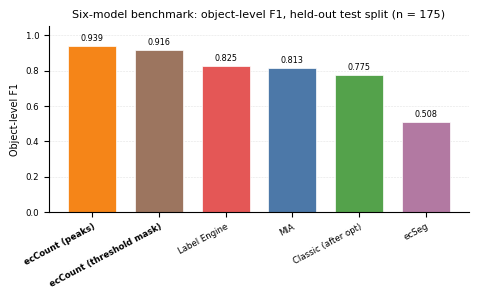

  Saved: fig6_test_f1_overall.svg
  Saved: fig6_test_f1_overall.png


In [3]:
# ── Panel 1: Overall object-level F1, test split ───────────────────────────
# Source: release/frozen_results/or_matching/per_image_metrics.csv (split == test)
# Output: fig6_test_f1_overall.{svg,png} + source_fig6_test_f1_overall.csv

plot_df = test_pooled[[
    'model', 'n_images', 'tp', 'fp', 'fn', 'precision', 'recall', 'object_f1'
]].copy()

save_source(plot_df, 'source_fig6_test_f1_overall')
display(plot_df.round(3))

fig, ax = plt.subplots(figsize=(4.8, 3.0))

x = np.arange(len(plot_df))
bar_colors = [MODEL_COLORS[str(m)] for m in plot_df['model']]

bars = ax.bar(
    x,
    plot_df['object_f1'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    width=0.72,
)

for bar, val in zip(bars, plot_df['object_f1']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        min(val + 0.018, 1.02),
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=5.8,
    )

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df['model'].astype(str),
    rotation=28,
    ha='right',
    rotation_mode='anchor',
)
ax.set_ylabel('Object-level F1')
ax.set_title('Six-model benchmark: object-level F1, held-out test split (n = 175)')
ax.set_ylim(0, 1.05)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.35)
ax.set_axisbelow(True)

for tick_label in ax.get_xticklabels():
    if tick_label.get_text().startswith('ecCount'):
        tick_label.set_fontweight('bold')

fig.tight_layout()
display(fig)
save_fig(fig, 'fig6_test_f1_overall')
plt.close(fig)

## §3 — Panel 2: object-level F1 by cell line, test split

Two views of the same numbers, both pooled within each model × cell-line cell:

1. **Grouped bars**, matching the layout of `fig6_f1_by_cell_line` from
   Notebook 03.
2. **Heatmap**, matching `fig6_f1_by_cell_line_heatmap` from Notebook 05, which
   is the more compact option.

The test split is small once divided four ways, so the per-cell-line image count
is printed and annotated on the heatmap. Cells backed by very few images should
not be over-interpreted, and the caption says so.

Outputs:

- `fig6_test_f1_by_cell_line.{svg,png}`
- `fig6_test_f1_by_cell_line_heatmap.{svg,png}`
- `source_fig6_test_f1_by_cell_line.csv`

  Saved source data: source_fig6_test_f1_by_cell_line.csv  (24 rows)
Test images per cell line:
  NCI-H2170     134
  SNU16          19
  COLO320DM      11
  NCI-H716       11


cell_line,NCI-H2170,SNU16,COLO320DM,NCI-H716
model,,,,
ecCount (peaks),0.941,0.931,0.886,0.949
ecCount (threshold mask),0.915,0.915,0.876,0.940
Label Engine,0.878,0.591,0.701,0.599
MIA,0.868,0.519,0.754,0.614
Classic (after opt),0.751,0.845,0.825,0.904
ecSeg,0.581,0.155,0.160,0.185


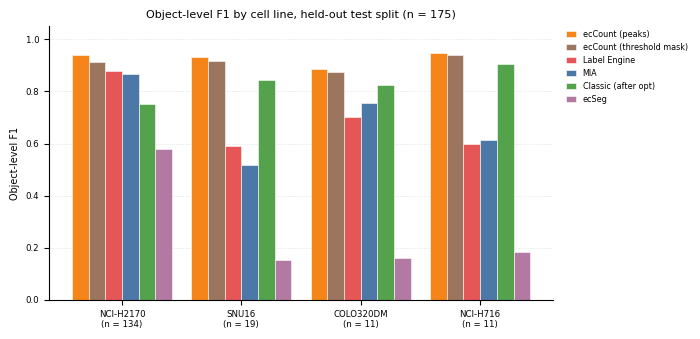

  Saved: fig6_test_f1_by_cell_line.svg
  Saved: fig6_test_f1_by_cell_line.png


In [4]:
# ── Panel 2a: Object-level F1 by cell line, test split (grouped bars) ──────
# Source: release/frozen_results/or_matching/per_image_metrics.csv (split == test)
# Output: fig6_test_f1_by_cell_line.{svg,png} + source_fig6_test_f1_by_cell_line.csv

cl_long = pool_by(test, ['model', 'cell_line_display'])
cl_long = cl_long.rename(columns={'cell_line_display': 'cell_line'})

cl_long = cl_long[
    cl_long['model'].isin(MODEL_ORDER) & cl_long['cell_line'].isin(CL_ORDER)
].copy()

cl_long['model'] = pd.Categorical(
    cl_long['model'], categories=MODEL_ORDER, ordered=True
)
cl_long['cell_line'] = pd.Categorical(
    cl_long['cell_line'], categories=CL_ORDER, ordered=True
)
cl_long = cl_long.sort_values(['cell_line', 'model']).reset_index(drop=True)

save_source(
    cl_long[[
        'model', 'cell_line', 'n_images', 'tp', 'fp', 'fn',
        'precision', 'recall', 'object_f1', 'count_mae', 'count_bias',
    ]],
    'source_fig6_test_f1_by_cell_line',
)

f1_by_cell_line = (
    cl_long.pivot(index='model', columns='cell_line', values='object_f1')
           .reindex(index=MODEL_ORDER, columns=CL_ORDER)
)

n_by_cell_line = (
    cl_long.pivot(index='model', columns='cell_line', values='n_images')
           .reindex(index=MODEL_ORDER, columns=CL_ORDER)
)

print('Test images per cell line:')
for cl in CL_ORDER:
    n = int(n_by_cell_line[cl].max()) if cl in n_by_cell_line else 0
    print(f'  {cl:12s} {n:4d}')

display(f1_by_cell_line.round(3))

fig, ax = plt.subplots(figsize=(8.6, 3.4))

n_cell_lines = len(CL_ORDER)
n_models = len(MODEL_ORDER)
x = np.arange(n_cell_lines)
bar_w = 0.14

for i, model_name in enumerate(MODEL_ORDER):
    vals = f1_by_cell_line.loc[model_name].astype(float).values
    offset = (i - (n_models - 1) / 2) * bar_w
    ax.bar(
        x + offset,
        vals,
        width=bar_w,
        color=MODEL_COLORS[model_name],
        edgecolor='white',
        linewidth=0.4,
        label=model_name,
    )

xtick_labels = [
    f'{cl}\n(n = {int(n_by_cell_line[cl].max())})' for cl in CL_ORDER
]

ax.set_xticks(x)
ax.set_xticklabels(xtick_labels)
ax.set_ylabel('Object-level F1')
ax.set_title(
    'Object-level F1 by cell line, held-out test split (n = 175)'
)
ax.set_ylim(0, 1.05)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.35)
ax.set_axisbelow(True)

ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0,
    frameon=False,
    fontsize=5.8,
    handlelength=1.2,
    ncol=1,
)

fig.tight_layout(rect=[0, 0, 0.82, 1])
display(fig)
save_fig(fig, 'fig6_test_f1_by_cell_line')
plt.close(fig)

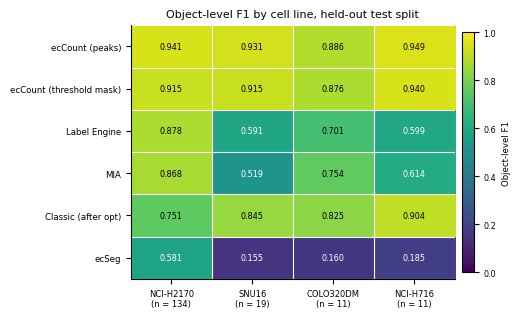

  Saved: fig6_test_f1_by_cell_line_heatmap.svg
  Saved: fig6_test_f1_by_cell_line_heatmap.png


In [5]:
# ── Panel 2b: Same numbers as a heatmap ────────────────────────────────────
# Output: fig6_test_f1_by_cell_line_heatmap.{svg,png}

mat = f1_by_cell_line.astype(float).values

fig, ax = plt.subplots(figsize=(5.2, 3.2))

im = ax.imshow(mat, cmap='viridis', vmin=0.0, vmax=1.0, aspect='auto')

ax.set_xticks(np.arange(len(CL_ORDER)))
ax.set_xticklabels(
    [f'{cl}\n(n = {int(n_by_cell_line[cl].max())})' for cl in CL_ORDER],
    fontsize=6.0,
)
ax.set_yticks(np.arange(len(MODEL_ORDER)))
ax.set_yticklabels(MODEL_ORDER, fontsize=6.2)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat[i, j]
        if np.isnan(val):
            continue
        ax.text(
            j, i, f'{val:.3f}',
            ha='center', va='center',
            fontsize=5.8,
            color='white' if val < 0.62 else 'black',
        )

ax.set_title('Object-level F1 by cell line, held-out test split')

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Object-level F1', fontsize=6.2)
cbar.ax.tick_params(labelsize=5.8)

ax.set_xticks(np.arange(-0.5, len(CL_ORDER), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(MODEL_ORDER), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=0.8)
ax.tick_params(which='minor', length=0)

fig.tight_layout()
display(fig)
save_fig(fig, 'fig6_test_f1_by_cell_line_heatmap')
plt.close(fig)

## §4 — Panel 3: object-level F1 by ecDNA count bin, test split

Count bins are the gold-standard count bands `0-9`, `10-49`, `50-149`,
`150-299`, `300+`. This is the panel that shows where the baselines fail:
performance separates as crowding increases, which is precisely the regime that
matters for the biological comparisons in items B and C.

Bins with no test images are dropped rather than plotted as gaps, and the image
count per bin is printed so sparse bins are visible.

Outputs:

- `fig6_test_f1_by_density.{svg,png}`
- `source_fig6_test_f1_by_density.csv`

  Saved source data: source_fig6_test_f1_by_density.csv  (30 rows)
Test images per density bin:
  0-9          1
  10-49       13
  50-149      64
  150-299     64
  300+        33


density_bin,0-9,10-49,50-149,150-299,300+
model,,,,,
ecCount (peaks),0.044,0.904,0.908,0.942,0.952
ecCount (threshold mask),0.045,0.899,0.894,0.925,0.918
Label Engine,0.000,0.681,0.765,0.820,0.860
MIA,0.114,0.687,0.761,0.809,0.843
Classic (after opt),0.050,0.736,0.715,0.786,0.795
ecSeg,0.000,0.241,0.355,0.483,0.601


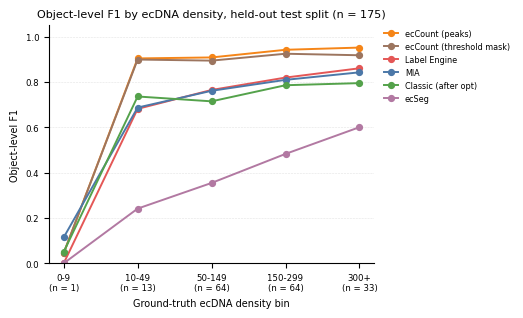

  Saved: fig6_test_f1_by_density.svg
  Saved: fig6_test_f1_by_density.png


In [6]:
# ── Panel 3: Object-level F1 by count bin, test split ────────────────────
# Source: release/frozen_results/or_matching/per_image_metrics.csv (split == test)
# Output: fig6_test_f1_by_density.{svg,png} + source_fig6_test_f1_by_density.csv

db_long = pool_by(test, ['model', 'density_bin'])

db_long = db_long[
    db_long['model'].isin(MODEL_ORDER) & db_long['density_bin'].isin(DENSITY_ORDER)
].copy()

density_present = [
    b for b in DENSITY_ORDER
    if b in set(db_long['density_bin']) and db_long.loc[db_long['density_bin'] == b, 'n_images'].max() > 0
]

if not density_present:
    raise ValueError('No count bins with test images were found.')

db_long['model'] = pd.Categorical(
    db_long['model'], categories=MODEL_ORDER, ordered=True
)
db_long['density_bin'] = pd.Categorical(
    db_long['density_bin'], categories=density_present, ordered=True
)
db_long = db_long.dropna(subset=['density_bin'])
db_long = db_long.sort_values(['density_bin', 'model']).reset_index(drop=True)

save_source(
    db_long[[
        'model', 'density_bin', 'n_images', 'tp', 'fp', 'fn',
        'precision', 'recall', 'object_f1', 'count_mae', 'count_bias',
    ]],
    'source_fig6_test_f1_by_density',
)

f1_by_density = (
    db_long.pivot(index='model', columns='density_bin', values='object_f1')
           .reindex(index=MODEL_ORDER, columns=density_present)
)

n_by_density = (
    db_long.pivot(index='model', columns='density_bin', values='n_images')
           .reindex(index=MODEL_ORDER, columns=density_present)
)

print('Test images per count bin:')
for b in density_present:
    print(f'  {b:9s} {int(n_by_density[b].max()):4d}')

display(f1_by_density.round(3))

fig, ax = plt.subplots(figsize=(6.6, 3.2))

x = np.arange(len(density_present))

for model_name in MODEL_ORDER:
    vals = f1_by_density.loc[model_name].astype(float).values
    ax.plot(
        x,
        vals,
        marker='o',
        markersize=4.2,
        linewidth=1.4,
        color=MODEL_COLORS[model_name],
        label=model_name,
    )

ax.set_xticks(x)
ax.set_xticklabels(
    [f'{b}\n(n = {int(n_by_density[b].max())})' for b in density_present]
)
ax.set_xlabel('Gold-standard ecDNA count bin')
ax.set_ylabel('Object-level F1')
ax.set_title('Object-level F1 by ecDNA density, held-out test split (n = 175)')
ax.set_ylim(0, 1.05)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.35)
ax.set_axisbelow(True)

ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0,
    frameon=False,
    fontsize=5.8,
    handlelength=1.8,
    ncol=1,
)

fig.tight_layout(rect=[0, 0, 0.80, 1])
display(fig)
save_fig(fig, 'fig6_test_f1_by_density')
plt.close(fig)

## §5 — Panel 4: count MAE and mean signed bias, test split

Two metrics on one figure, because they say different things and the paper's
argument depends on the second.

- **Count MAE** is how wrong a method is per image, without direction.
- **Mean signed bias** is the direction of that error. A method with bias −40
  does not merely report smaller numbers; it reports numbers smaller by an
  amount that depends on how crowded the image is. That is what distorts
  comparisons between experimental conditions.

The bias panel is drawn on a symmetric axis about zero with a zero reference
line, so the near-zero bias of ecCount (peaks) is legible against the large
negative bias of the other five methods.

Outputs:

- `fig6_test_count_mae.{svg,png}`
- `source_fig6_test_count_mae.csv`

  Saved source data: source_fig6_test_count_mae.csv  (6 rows)


,model,n_images,count_mae,count_median_ae,count_bias,gt_count_mean,pred_count_mean,gt_count_median,pred_count_median,bias_pct_of_gt,mae_pct_of_gt
0,ecCount (peaks),175,13.31,8.0,1.88,192.16,194.04,169.0,171.0,0.98,6.93
1,ecCount (threshold mask),175,17.62,11.0,-9.10,192.16,183.06,169.0,163.0,-4.74,9.17
2,Label Engine,175,34.37,18.0,-26.87,192.16,165.29,169.0,129.0,-13.98,17.88
3,MIA,175,40.39,21.0,-35.74,192.16,156.42,169.0,112.0,-18.60,21.02
4,Classic (after opt),175,40.94,25.0,-17.35,192.16,174.81,169.0,157.0,-9.03,21.31
5,ecSeg,175,110.27,77.0,-107.42,192.16,84.74,169.0,46.0,-55.90,57.39


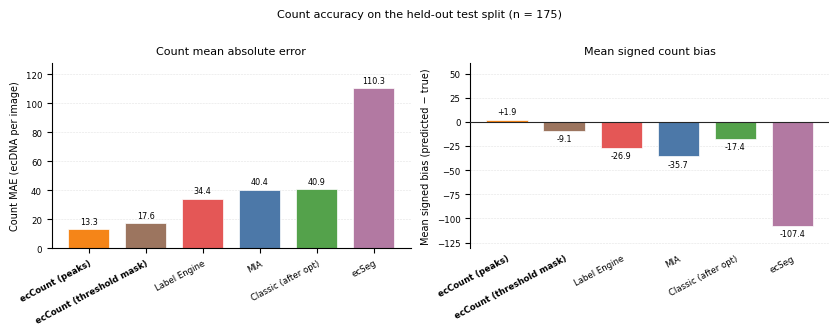

  Saved: fig6_test_count_mae.svg
  Saved: fig6_test_count_mae.png


In [7]:
# ── Panel 4: Count MAE and mean signed bias, test split ────────────────────
# Source: release/frozen_results/or_matching/per_image_metrics.csv (split == test)
# Output: fig6_test_count_mae.{svg,png} + source_fig6_test_count_mae.csv

mae_df = test_pooled[[
    'model', 'n_images', 'count_mae', 'count_median_ae', 'count_bias'
]].copy()

gt_pred_means = (
    test.groupby('model', observed=False)
        .agg(
            gt_count_mean=('gt_count', 'mean'),
            pred_count_mean=('pred_count', 'mean'),
            gt_count_median=('gt_count', 'median'),
            pred_count_median=('pred_count', 'median'),
        )
        .reindex(MODEL_ORDER)
        .reset_index()
)

mae_df = mae_df.merge(gt_pred_means, on='model', how='left')

# Bias expressed as a percentage of mean gold-standard burden, so the ranking is
# readable independently of absolute count scale.
mae_df['bias_pct_of_gt'] = 100.0 * mae_df['count_bias'] / mae_df['gt_count_mean']
mae_df['mae_pct_of_gt'] = 100.0 * mae_df['count_mae'] / mae_df['gt_count_mean']

save_source(mae_df, 'source_fig6_test_count_mae')
display(mae_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.2))

# ---- Left: count MAE -------------------------------------------------------
ax = axes[0]
x = np.arange(len(mae_df))
bar_colors = [MODEL_COLORS[str(m)] for m in mae_df['model']]

bars = ax.bar(
    x, mae_df['count_mae'],
    color=bar_colors, edgecolor='white', linewidth=0.5, width=0.72,
)

for bar, val in zip(bars, mae_df['count_mae']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + mae_df['count_mae'].max() * 0.02,
        f'{val:.1f}',
        ha='center', va='bottom', fontsize=5.8,
    )

ax.set_xticks(x)
ax.set_xticklabels(
    mae_df['model'].astype(str), rotation=28, ha='right', rotation_mode='anchor'
)
ax.set_ylabel('Count MAE (ecDNA per image)')
ax.set_title('Count mean absolute error')
ax.set_ylim(0, mae_df['count_mae'].max() * 1.16)
ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.35)
ax.set_axisbelow(True)

for tick_label in ax.get_xticklabels():
    if tick_label.get_text().startswith('ecCount'):
        tick_label.set_fontweight('bold')

# ---- Right: mean signed bias ----------------------------------------------
ax = axes[1]
bars = ax.bar(
    x, mae_df['count_bias'],
    color=bar_colors, edgecolor='white', linewidth=0.5, width=0.72,
)

bias_span = max(abs(mae_df['count_bias'].min()), abs(mae_df['count_bias'].max()))
pad = bias_span * 0.22

for bar, val in zip(bars, mae_df['count_bias']):
    offset = pad * 0.16
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val - offset if val < 0 else val + offset,
        f'{val:+.1f}',
        ha='center',
        va='top' if val < 0 else 'bottom',
        fontsize=5.8,
    )

ax.axhline(0, color='0.15', linewidth=0.8, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(
    mae_df['model'].astype(str), rotation=28, ha='right', rotation_mode='anchor'
)
ax.set_ylabel('Mean signed bias (predicted − true)')
ax.set_title('Mean signed count bias')
ax.set_ylim(-bias_span - pad, bias_span * 0.35 + pad)
ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.35)
ax.set_axisbelow(True)
ax.spines['bottom'].set_visible(False)
ax.tick_params(axis='x', length=0)

for tick_label in ax.get_xticklabels():
    if tick_label.get_text().startswith('ecCount'):
        tick_label.set_fontweight('bold')

fig.suptitle(
    'Count accuracy on the held-out test split (n = 175)', fontsize=8, y=1.02
)
fig.tight_layout()
display(fig)
save_fig(fig, 'fig6_test_count_mae')
plt.close(fig)

## §6 — Panel 5: predicted versus gold-standard count agreement, test split

A 2 × 3 grid, one panel per model, log–log axes with a dashed identity line.
Zero counts are displayed with a `+1` offset so images with no detected or no
annotated objects stay visible; MAE and bias in the panel titles are computed on
the original unshifted scale.

A three-model variant is also produced, showing only ecCount (peaks),
ecCount (threshold mask) and Label Engine. That version is easier to read at
main-figure size if the six-panel grid is too small once assembled.

Outputs:

- `fig6_test_count_agreement.{svg,png}`
- `fig6_test_count_agreement_top3.{svg,png}`
- `source_fig6_test_count_agreement.csv`
- `source_fig6_test_count_agreement_summary.csv`

  Saved source data: source_fig6_test_count_agreement.csv  (1,050 rows)
  Saved source data: source_fig6_test_count_agreement_summary.csv  (6 rows)


,model,n_images,count_mae,count_bias,median_abs_error,gt_count_median,pred_count_median,gt_count_max,pred_count_max,count_pearson_r
0,ecCount (peaks),175,13.309,1.880,8.0,169.0,171.0,912,919,0.989
1,ecCount (threshold mask),175,17.617,-9.103,11.0,169.0,163.0,912,768,0.985
2,Label Engine,175,34.366,-26.869,18.0,169.0,129.0,912,871,0.932
3,MIA,175,40.394,-35.743,21.0,169.0,112.0,912,872,0.906
4,Classic (after opt),175,40.943,-17.354,25.0,169.0,157.0,912,718,0.911
5,ecSeg,175,110.274,-107.417,77.0,169.0,46.0,912,830,0.679


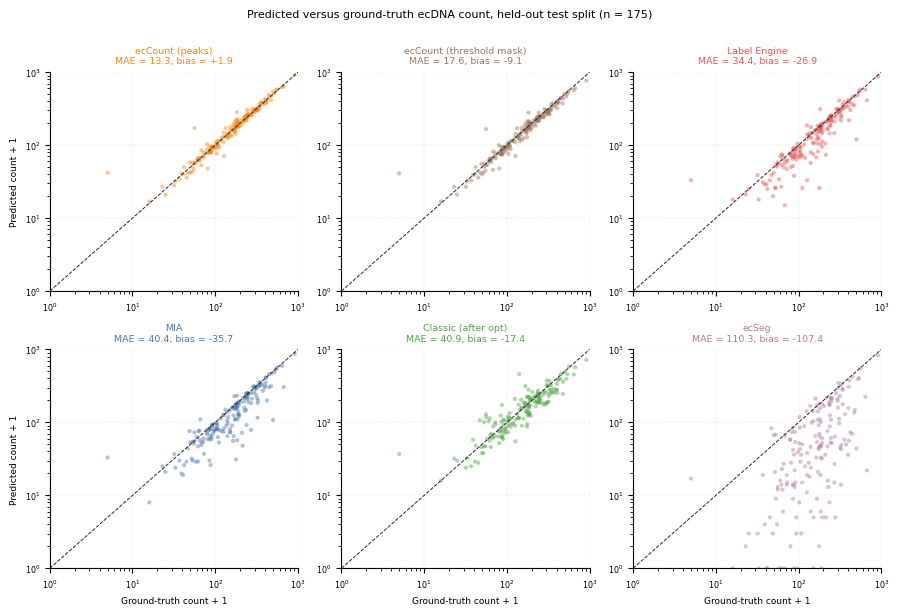

  Saved: fig6_test_count_agreement.svg
  Saved: fig6_test_count_agreement.png


In [8]:
# ── Panel 5a: Predicted vs GS count agreement, test split (six panels) ─────
# Source: release/frozen_results/or_matching/per_image_metrics.csv (split == test)
# Output: fig6_test_count_agreement.{svg,png} + source CSVs
#
# Notes:
#   - Axes are log-log, so counts are displayed with a +1 offset.
#   - MAE and bias are computed on the original unshifted scale.

count_long = test[[
    'uid', 'model', 'split', 'cell_line_display', 'density_bin',
    'gt_count', 'pred_count', 'count_abs_error', 'signed_count_error',
]].copy()

count_long = count_long.rename(columns={
    'count_abs_error': 'abs_error',
    'signed_count_error': 'signed_error',
})

count_long['gt_count_plot'] = count_long['gt_count'] + 1
count_long['pred_count_plot'] = count_long['pred_count'] + 1
count_long = count_long.sort_values(['model', 'gt_count']).reset_index(drop=True)

save_source(count_long, 'source_fig6_test_count_agreement')

count_summary = (
    count_long.groupby('model', observed=False)
    .agg(
        n_images=('uid', 'nunique'),
        count_mae=('abs_error', 'mean'),
        count_bias=('signed_error', 'mean'),
        median_abs_error=('abs_error', 'median'),
        gt_count_median=('gt_count', 'median'),
        pred_count_median=('pred_count', 'median'),
        gt_count_max=('gt_count', 'max'),
        pred_count_max=('pred_count', 'max'),
    )
    .reindex(MODEL_ORDER)
    .reset_index()
)

# Pearson r between predicted and gold-standard counts, per model.
pearson_rows = []
for model_name in MODEL_ORDER:
    sub = count_long[count_long['model'] == model_name]
    if len(sub) >= 2 and sub['gt_count'].std() > 0 and sub['pred_count'].std() > 0:
        r = float(np.corrcoef(sub['gt_count'], sub['pred_count'])[0, 1])
    else:
        r = np.nan
    pearson_rows.append({'model': model_name, 'count_pearson_r': r})

count_summary = count_summary.merge(pd.DataFrame(pearson_rows), on='model', how='left')

save_source(count_summary, 'source_fig6_test_count_agreement_summary')
display(count_summary.round(3))

axis_hi = 10 ** np.ceil(np.log10(max(
    count_long['gt_count_plot'].max(), count_long['pred_count_plot'].max()
)))
axis_lo = 1


def draw_agreement_grid(models, nrows, ncols, figsize, fig_name, suptitle):
    """Draw a log-log predicted-vs-gold-standard count grid for the given models."""
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).flatten()

    for ax, model_name in zip(axes, models):
        sub = count_long[count_long['model'] == model_name]

        if sub.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8)
            ax.set_title(model_name, fontsize=6.8)
            ax.axis('off')
            continue

        mae = float(sub['abs_error'].mean())
        bias = float(sub['signed_error'].mean())

        ax.scatter(
            sub['gt_count_plot'], sub['pred_count_plot'],
            s=9, alpha=0.45,
            color=MODEL_COLORS[model_name],
            edgecolor='none', rasterized=True,
        )

        ax.plot(
            [axis_lo, axis_hi], [axis_lo, axis_hi],
            color='0.15', linewidth=0.7, linestyle='--', zorder=1,
        )

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(axis_lo, axis_hi)
        ax.set_ylim(axis_lo, axis_hi)

        ax.set_title(
            f'{model_name}\nMAE = {mae:.1f}, bias = {bias:+.1f}',
            fontsize=6.8, color=MODEL_COLORS[model_name],
        )

        ax.grid(which='major', linestyle='--', linewidth=0.35, alpha=0.35)
        ax.set_axisbelow(True)
        ax.tick_params(axis='both', which='major', labelsize=5.8)

    for ax in axes[len(models):]:
        ax.axis('off')

    for ax in axes[(nrows - 1) * ncols:]:
        ax.set_xlabel('Gold-standard count + 1', fontsize=6.5)
    for ax in axes[::ncols]:
        ax.set_ylabel('Predicted count + 1', fontsize=6.5)

    fig.suptitle(suptitle, fontsize=8, y=1.01)
    fig.tight_layout()
    display(fig)
    save_fig(fig, fig_name)
    plt.close(fig)


draw_agreement_grid(
    models=MODEL_ORDER,
    nrows=2, ncols=3,
    figsize=(9.0, 6.0),
    fig_name='fig6_test_count_agreement',
    suptitle='Predicted versus gold-standard ecDNA count, held-out test split (n = 175)',
)

  Saved source data: source_fig6_test_count_agreement_top3_summary.csv  (3 rows)
  Saved source data: source_fig6_test_count_agreement_top3.csv  (525 rows)


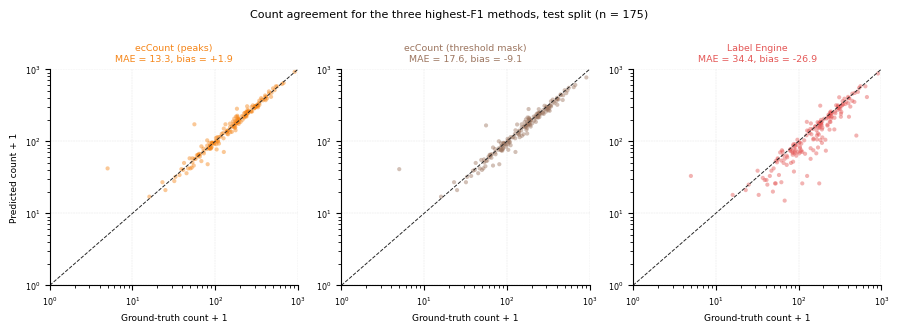

  Saved: fig6_test_count_agreement_top3.svg
  Saved: fig6_test_count_agreement_top3.png


In [9]:
# ── Panel 5b: Three-model variant for main-figure use ──────────────────────
# Output: fig6_test_count_agreement_top3.{svg,png}

TOP3 = ['ecCount (peaks)', 'ecCount (threshold mask)', 'Label Engine']

top3_summary = count_summary[count_summary['model'].isin(TOP3)].copy()
top3_summary['model'] = pd.Categorical(
    top3_summary['model'], categories=TOP3, ordered=True
)
top3_summary = top3_summary.sort_values('model').reset_index(drop=True)

save_source(top3_summary, 'source_fig6_test_count_agreement_top3_summary')
save_source(
    count_long[count_long['model'].isin(TOP3)].copy(),
    'source_fig6_test_count_agreement_top3',
)

draw_agreement_grid(
    models=TOP3,
    nrows=1, ncols=3,
    figsize=(9.0, 3.2),
    fig_name='fig6_test_count_agreement_top3',
    suptitle='Count agreement for the three highest-F1 methods, test split (n = 175)',
)

## §2b — Panel a: three-metric performance comparison, test split

The composite panel at the top of the assembled Figure 6: pooled object-level
F1, pooled pixel-level Dice, and count MAE, as three horizontal bar charts sharing a
single model legend.

Pixel-level Dice is the metric Notebook 06 has not touched so far. It follows the
same pooling convention as object F1: `pix_tp`, `pix_fp` and `pix_fn` are summed
across the filtered rows, then `Dice = 2·TP / (2·TP + FP + FN)`. This matters,
because the per-image mean gives a different answer (0.150 rather than 0.117 for
Classic (after opt) on the test split) and the locked value is the pooled one.

The cell therefore computes both, reports which reproduces
`release/figures/notebook05/pixel_dice_locked_numbers.csv`, and refuses to
proceed if neither does.

Locked test-split pixel-level Dice: 0.310, 0.302, 0.247, 0.217, 0.117, 0.165.

Outputs:

- `fig6_test_performance_comparison.{svg,png}`
- `source_fig6_test_performance_comparison.csv`

Locked pixel Dice loaded from pixel_dice_locked_numbers.csv.

Max |pooled  − locked| = 0.000000
Max |per-image mean − locked| = 0.070190
Pixel Dice convention: POOLED (micro-averaged). Matches the locked values.


,pix_tp,pix_fp,pix_fn,pixel_dice_pooled,pixel_dice_per_image_mean,pixel_dice_locked
model,,,,,,
ecCount (peaks),136318,305123,301730,0.309994,0.304334,0.309994
ecCount (threshold mask),310974,1311606,127074,0.301824,0.304126,0.301824
Label Engine,172219,781884,265829,0.247414,0.214962,0.247414
MIA,184000,1072289,254048,0.217194,0.193784,0.217194
Classic (after opt),276234,4018494,161814,0.116732,0.149965,0.116732
ecSeg,95836,629596,342212,0.164740,0.094550,0.164740


  Saved source data: source_fig6_test_performance_comparison.csv  (6 rows)


,model,object_f1_reported_3dp,pixel_dice_reported_3dp,count_mae_reported_1dp,count_bias_reported_1dp
0,ecCount (peaks),0.939,0.310,13.3,1.9
1,ecCount (threshold mask),0.916,0.302,17.6,-9.1
2,Label Engine,0.825,0.247,34.4,-26.9
3,MIA,0.813,0.217,40.4,-35.7
4,Classic (after opt),0.775,0.117,40.9,-17.4
5,ecSeg,0.508,0.165,110.3,-107.4


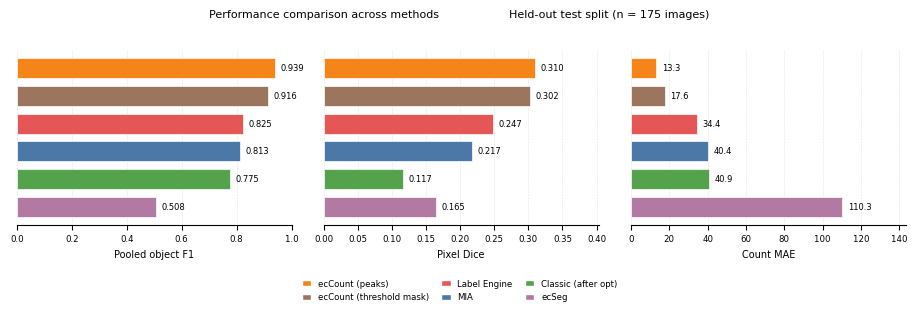

  Saved: fig6_test_performance_comparison.svg
  Saved: fig6_test_performance_comparison.png


In [10]:
# ── Panel a: Three-metric performance comparison, test split ───────────────
# Source:
#   release/frozen_results/or_matching/per_image_metrics.csv (split == test)
# Reference:
#   release/figures/notebook05/pixel_dice_locked_numbers.csv
# Output:
#   fig6_test_performance_comparison.{svg,png}
#   source_fig6_test_performance_comparison.csv

for col in ['pix_tp', 'pix_fp', 'pix_fn']:
    if col not in test.columns:
        raise KeyError(
            f'per_image_metrics.csv has no {col} column, so pixel-level Dice cannot '
            f'be pooled. Available columns: {list(test.columns)}'
        )

# Pooled pixel-level Dice, and the per-image mean for comparison.
pix = (
    test.groupby('model', observed=False)
        .agg(pix_tp=('pix_tp', 'sum'), pix_fp=('pix_fp', 'sum'), pix_fn=('pix_fn', 'sum'))
        .reindex(MODEL_ORDER)
)
pix['pixel_dice_pooled'] = pooled_f1(pix['pix_tp'], pix['pix_fp'], pix['pix_fn'])

if 'pix_dice' in test.columns:
    pix['pixel_dice_per_image_mean'] = (
        test.groupby('model', observed=False)['pix_dice'].mean().reindex(MODEL_ORDER)
    )
else:
    pix['pixel_dice_per_image_mean'] = np.nan

# Locked reference. Source: pixel_dice_locked_numbers.csv, subset == test_only.
PIXEL_DICE_LOCKED_TEST = {
    'ecCount (peaks)':          0.309994,
    'ecCount (threshold mask)': 0.301824,
    'Label Engine':             0.247414,
    'MIA':                      0.217194,
    'Classic (after opt)':      0.116732,
    'ecSeg':                    0.164740,
}

PIXEL_DICE_CSV = NB05 / 'pixel_dice_locked_numbers.csv'
if PIXEL_DICE_CSV.exists():
    pdl = pd.read_csv(PIXEL_DICE_CSV)
    pdl['model'] = pdl['model'].apply(canonical_model_name)
    pdl_test = pdl[pdl['subset'].astype(str).str.lower().str.startswith('test')]
    if not pdl_test.empty:
        PIXEL_DICE_LOCKED_TEST = dict(
            zip(pdl_test['model'], pdl_test['pixel_dice_raw'].astype(float))
        )
        print(f'Locked pixel-level Dice loaded from {PIXEL_DICE_CSV.name}.')
else:
    print(f'Not present, using embedded values: {PIXEL_DICE_CSV.name}')

pix['pixel_dice_locked'] = [PIXEL_DICE_LOCKED_TEST[m] for m in pix.index]

d_pooled = (pix['pixel_dice_pooled'] - pix['pixel_dice_locked']).abs().max()
d_mean = (pix['pixel_dice_per_image_mean'] - pix['pixel_dice_locked']).abs().max()

print(f'\nMax |pooled  − locked| = {d_pooled:.6f}')
print(f'Max |per-image mean − locked| = {d_mean:.6f}')

DICE_TOL = 0.0006
if d_pooled <= DICE_TOL:
    pix['pixel_dice'] = pix['pixel_dice_pooled']
    print('Pixel-level Dice convention: POOLED (micro-averaged). Matches the locked values.')
elif d_mean <= DICE_TOL:
    pix['pixel_dice'] = pix['pixel_dice_per_image_mean']
    print('Pixel-level Dice convention: PER-IMAGE MEAN. Matches the locked values.')
else:
    raise ValueError(
        'Neither pooled nor per-image-mean pixel-level Dice reproduces the locked '
        f'values (best deviation {min(d_pooled, d_mean):.6f}). Stop and '
        'diagnose before drawing.'
    )

display(pix[[
    'pix_tp', 'pix_fp', 'pix_fn',
    'pixel_dice_pooled', 'pixel_dice_per_image_mean', 'pixel_dice_locked',
]].round(6))

# ── Assemble the three-metric table ─────────────────────────────────────────
panel_a = test_pooled[['model', 'n_images', 'tp', 'fp', 'fn',
                       'precision', 'recall', 'object_f1',
                       'count_mae', 'count_bias']].copy()
panel_a = panel_a.merge(
    pix[['pixel_dice']].reset_index().rename(columns={'index': 'model'}),
    on='model', how='left',
)
panel_a['object_f1_reported_3dp'] = panel_a['object_f1'].round(3)
panel_a['pixel_dice_reported_3dp'] = panel_a['pixel_dice'].round(3)
panel_a['count_mae_reported_1dp'] = panel_a['count_mae'].round(1)
panel_a['count_bias_reported_1dp'] = panel_a['count_bias'].round(1)
panel_a['subset'] = 'test'

save_source(panel_a, 'source_fig6_test_performance_comparison')
display(panel_a[[
    'model', 'object_f1_reported_3dp', 'pixel_dice_reported_3dp',
    'count_mae_reported_1dp', 'count_bias_reported_1dp',
]])

# ── Draw ────────────────────────────────────────────────────────────────────
METRICS = [
    ('object_f1',  'Pooled object F1', '{:.3f}', (0, 1.0)),
    ('pixel_dice', 'Pixel-level Dice',       '{:.3f}', None),
    ('count_mae',  'Count MAE',        '{:.1f}', None),
]

fig, axes = plt.subplots(1, 3, figsize=(9.2, 2.5))

# Models run top to bottom in MODEL_ORDER, so ecCount (peaks) is the top bar.
y = np.arange(len(MODEL_ORDER))[::-1]
bar_colors = [MODEL_COLORS[m] for m in MODEL_ORDER]

for ax, (col, title, fmt, xlim) in zip(axes, METRICS):
    vals = panel_a.set_index('model').loc[MODEL_ORDER, col].astype(float).values

    ax.barh(y, vals, color=bar_colors, edgecolor='white', linewidth=0.5, height=0.72)

    hi = xlim[1] if xlim else vals.max() * 1.30
    lo = xlim[0] if xlim else 0
    ax.set_xlim(lo, hi)

    for yi, v in zip(y, vals):
        ax.text(v + (hi - lo) * 0.02, yi, fmt.format(v),
                va='center', ha='left', fontsize=6.0)

    ax.set_yticks(y)
    ax.set_yticklabels([])
    ax.tick_params(axis='y', length=0)
    ax.set_xlabel(title)
    ax.grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.35)
    ax.set_axisbelow(True)
    ax.spines['left'].set_visible(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=MODEL_COLORS[m], edgecolor='white')
    for m in MODEL_ORDER
]
fig.legend(
    handles, MODEL_ORDER,
    loc='lower center', bbox_to_anchor=(0.5, -0.16),
    ncol=3, frameon=False, fontsize=6.2, handlelength=1.1, columnspacing=1.4,
)

fig.suptitle(
    'Performance comparison across methods'
    '                    Held-out test split (n = 175 images)',
    fontsize=8, y=1.04,
)

fig.tight_layout()
display(fig)
save_fig(fig, 'fig6_test_performance_comparison')
plt.close(fig)

## §7 — Test split versus full benchmark: reference table

One table holding both sets of locked numbers, so that when the main figures
move to the test split and the full-benchmark versions move to supplementary,
every number in either place traces to a single file.

This table is what to check the manuscript against during the Results rewrite.

Output:

- `source_fig6_test_vs_all_locked_numbers.csv`

In [11]:
# ── §7: Test versus full-benchmark reference table ─────────────────────────
# Output: source_fig6_test_vs_all_locked_numbers.csv

ref_test = test_pooled[[
    'model', 'n_images', 'tp', 'fp', 'fn',
    'precision', 'recall', 'object_f1', 'count_mae', 'count_bias',
]].copy()
ref_test['subset'] = 'test'

ref_all = all_pooled[[
    'model', 'n_images', 'tp', 'fp', 'fn',
    'precision', 'recall', 'object_f1', 'count_mae', 'count_bias',
]].copy()
ref_all['subset'] = 'all_benchmark'

reference = pd.concat([ref_test, ref_all], ignore_index=True)

reference['object_f1_reported_3dp'] = reference['object_f1'].round(3)
reference['count_mae_reported_1dp'] = reference['count_mae'].round(1)
reference['count_bias_reported_1dp'] = reference['count_bias'].round(1)

reference['policy'] = CANONICAL_POLICY
reference['d_max_px'] = CANONICAL_D_MAX
reference['iou_min'] = CANONICAL_IOU_MIN
reference['alpha'] = CANONICAL_ALPHA
reference['min_component_area_px'] = MIN_COMPONENT_AREA

# Panel-name mapping, so the two figure sets stay unambiguous for assembly.
PANEL_MAP = pd.DataFrame(
    [
        ('fig6_test_f1_overall',              'fig6_f1_overall',              'notebook03'),
        ('fig6_test_f1_by_cell_line',         'fig6_f1_by_cell_line',         'notebook03'),
        ('fig6_test_f1_by_cell_line_heatmap', 'fig6_f1_by_cell_line_heatmap', 'notebook05'),
        ('fig6_test_f1_by_density',           'fig6_f1_by_density',           'notebook03'),
        ('fig6_test_count_mae',               'fig6_test_count_mae',          'notebook03'),
        ('fig6_test_count_agreement',         'fig6_count_agreement',         'notebook03'),
        ('fig6_test_count_agreement_top3',    'fig6_count_agreement_top3',    'notebook05'),
    ],
    columns=['panel_test_split', 'panel_full_benchmark', 'full_benchmark_source_dir'],
)

save_source(reference, 'source_fig6_test_vs_all_locked_numbers')
save_source(PANEL_MAP, 'source_fig6_panel_name_map')

print('\n── Reference table ──')
display(
    reference.pivot(
        index='model', columns='subset',
        values=['object_f1_reported_3dp', 'count_mae_reported_1dp', 'count_bias_reported_1dp'],
    ).reindex(MODEL_ORDER)
)

print('\n── Panel name mapping ──')
display(PANEL_MAP)

  Saved source data: source_fig6_test_vs_all_locked_numbers.csv  (12 rows)
  Saved source data: source_fig6_panel_name_map.csv  (7 rows)

── Reference table ──


object_f1_reported_3dp        count_mae_reported_1dp  \
subset                            all_benchmark   test          all_benchmark   
model                                                                           
ecCount (peaks)                           0.942  0.939                   13.1   
ecCount (threshold mask)                  0.917  0.916                   18.1   
Label Engine                              0.825  0.825                   36.0   
MIA                                       0.800  0.813                   47.0   
Classic (after opt)                       0.777  0.775                   44.9   
ecSeg                                     0.464  0.508                  121.5   

                                count_bias_reported_1dp         
subset                     test           all_benchmark   test  
model                                                           
ecCount (peaks)            13.3                     0.4    1.9  
ecCount (threshold mask)   17.6                   -11.4   -9.1  
Label Engine               34.4                   -28.8  -26.9  
MIA                        40.4                   -40.6  -35.7  
Classic (after opt)        40.9                   -24.3  -17.4  
ecSeg                     110.3                  -118.5 -107.4


── Panel name mapping ──


,panel_test_split,panel_full_benchmark,full_benchmark_source_dir
0,fig6_test_f1_overall,fig6_f1_overall,notebook03
1,fig6_test_f1_by_cell_line,fig6_f1_by_cell_line,notebook03
2,fig6_test_f1_by_cell_line_heatmap,fig6_f1_by_cell_line_heatmap,notebook05
3,fig6_test_f1_by_density,fig6_f1_by_density,notebook03
4,fig6_test_count_mae,fig6_test_count_mae,notebook03
5,fig6_test_count_agreement,fig6_count_agreement,notebook03
6,fig6_test_count_agreement_top3,fig6_count_agreement_top3,notebook05


## §7b — Panel e: robustness of F1 across the matching grid

The panel that answers the reviewer question "how much of your ranking is an
artefact of the operating point you chose?". For each method it shows the spread
of pooled object-level F1 across the whole `d_max × IoU_min` grid, with the
canonical point marked.

**The sensitivity sweep is already test-split only.** `sensitivity_sweep.csv`
holds 980 rows: 7 models × 2 policies × 70 grid points (`d_max` ∈ {5, 10, 15,
20, 25, 30, 40, 50, 75, 100} px × `IoU_min` ∈ {0, 0.05, 0.1, 0.2, 0.3, 0.4,
0.5}), and every row has `split == "test"`. Nothing needs regenerating, and the
existing `figS_sensitivity_range` panel from Notebook 04 was already computed on
the 175 held-out images.

Four elements per method:

- **Full range** — thin line from minimum to maximum F1 across the 70 grid points.
- **Interquartile range** — thick bar from the 25th to the 75th percentile.
- **Median** — black vertical tick.
- **Canonical point** — open circle at `d_max = 20 px`, `IoU_min = 0.1`.

The cell asserts that the canonical point reproduces the locked test-split F1
for every method, and reconciles the quartiles against
`source_figS_sensitivity_range.csv` where that file is present.

Outputs:

- `fig6_test_f1_robustness.{svg,png}`
- `source_fig6_test_f1_robustness.csv`

Loaded      : /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/frozen_results/sensitivity/sensitivity_sweep.csv
Rows        : 980
Splits      : ['test']
Policies    : ['and', 'or']
d_max grid  : [5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0, 75.0, 100.0]
IoU_min grid: [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

Sweep covers the test split only. No filtering needed.
Grid points per model: 70
Canonical grid point reproduces the locked test-split F1 for all six models.
Max deviation from source_figS_sensitivity_range.csv: 0.000000
  Saved source data: source_fig6_test_f1_robustness.csv  (6 rows)


,n_grid_points,min_f1,q25_f1,median_f1,q75_f1,max_f1,range_f1,canonical_f1,canonical_minus_median
model,,,,,,,,,
ecCount (peaks),70,0.8470,0.9331,0.9461,0.9623,0.9771,0.1301,0.9391,-0.0070
ecCount (threshold mask),70,0.8142,0.9095,0.9229,0.9397,0.9553,0.1411,0.9157,-0.0072
Label Engine,70,0.6567,0.8136,0.8386,0.8693,0.8963,0.2396,0.8250,-0.0136
MIA,70,0.6119,0.8022,0.8257,0.8546,0.8789,0.2670,0.8127,-0.0130
Classic (after opt),70,0.6225,0.7556,0.8027,0.8598,0.9013,0.2788,0.7748,-0.0280
ecSeg,70,0.4001,0.5013,0.5185,0.5466,0.5829,0.1828,0.5082,-0.0103


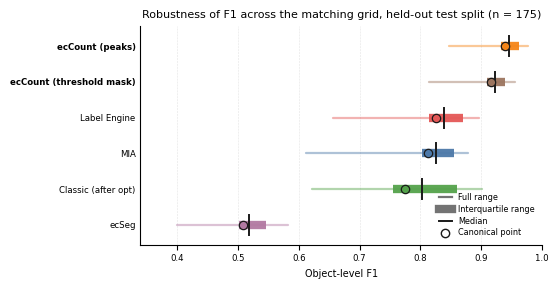

  Saved: fig6_test_f1_robustness.svg
  Saved: fig6_test_f1_robustness.png

Grid: d_max [5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0, 75.0, 100.0] px × IoU_min [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5], 70 points per method, OR policy.


In [12]:
# ── Panel e: Robustness of F1 across the matching grid, test split ─────────
# Source:
#   release/frozen_results/sensitivity/sensitivity_sweep.csv
# Reference:
#   release/figures/notebook04/source_figS_sensitivity_range.csv
# Output:
#   fig6_test_f1_robustness.{svg,png} + source_fig6_test_f1_robustness.csv

SENS_CSV = require_file(
    FROZEN_ROOT / 'sensitivity' / 'sensitivity_sweep.csv',
    label='Sensitivity sweep',
)

sweep = pd.read_csv(SENS_CSV)
sweep['model'] = sweep['model'].apply(canonical_model_name)

f1_col = find_metric_column(
    sweep, ['f1', 'object_f1', 'obj_f1'], 'sweep object-F1 column'
)

print(f'Loaded      : {SENS_CSV}')
print(f'Rows        : {len(sweep):,}')
print(f'Splits      : {sorted(sweep["split"].astype(str).unique().tolist())}')
print(f'Policies    : {sorted(sweep["policy"].astype(str).unique().tolist())}')
print(f'd_max grid  : {sorted(sweep["d_max"].unique().tolist())}')
print(f'IoU_min grid: {sorted(sweep["iou_min"].unique().tolist())}')

# The sweep is expected to be test-split only. If a future rerun adds other
# splits, filter to test rather than silently pooling across them.
splits_present = set(sweep['split'].astype(str).str.lower().unique())
if splits_present == {'test'}:
    sweep_sub = sweep.copy()
    SWEEP_SUBSET_LABEL = 'held-out test split (n = 175)'
    print('\nSweep covers the test split only. No filtering needed.')
elif 'test' in splits_present:
    sweep_sub = sweep[sweep['split'].astype(str).str.lower() == 'test'].copy()
    SWEEP_SUBSET_LABEL = 'held-out test split (n = 175)'
    print(f'\nFiltered to split == "test": {len(sweep_sub):,} rows.')
else:
    raise ValueError(
        f'The sensitivity sweep contains no test-split rows (splits present: '
        f'{sorted(splits_present)}). Regenerate with:\n'
        '  python -m ecdna_bench.cli.sensitivity --config configs/default.yaml '
        '--split test'
    )

# Canonical policy only.
sweep_or = sweep_sub[sweep_sub['policy'].astype(str).str.lower() == 'or'].copy()
if sweep_or.empty:
    raise ValueError(
        'No OR-policy rows in the sensitivity sweep. Policies present: '
        f'{sorted(sweep_sub["policy"].astype(str).unique().tolist())}'
    )

sweep_or = sweep_or[sweep_or['model'].isin(MODEL_ORDER)].copy()

n_grid = sweep_or.groupby('model').size()
if n_grid.nunique() != 1:
    raise ValueError(
        f'Uneven grid coverage across models: {n_grid.to_dict()}'
    )
print(f'Grid points per model: {int(n_grid.iloc[0])}')

# ── Robustness summary ──────────────────────────────────────────────────────
rob = (
    sweep_or.groupby('model', observed=False)[f1_col]
    .agg(
        n_grid_points='size',
        min_f1='min',
        q25_f1=lambda s: s.quantile(0.25),
        median_f1='median',
        q75_f1=lambda s: s.quantile(0.75),
        max_f1='max',
    )
    .reindex(MODEL_ORDER)
)
rob['range_f1'] = rob['max_f1'] - rob['min_f1']

canonical = sweep_or[
    (sweep_or['d_max'] == CANONICAL_D_MAX)
    & (np.isclose(sweep_or['iou_min'], CANONICAL_IOU_MIN))
]
if len(canonical) != len(MODEL_ORDER):
    raise ValueError(
        f'Expected one canonical grid point per model at d_max='
        f'{CANONICAL_D_MAX}, IoU_min={CANONICAL_IOU_MIN}; found {len(canonical)} rows.'
    )

rob['canonical_f1'] = canonical.set_index('model')[f1_col].reindex(MODEL_ORDER)
rob['canonical_minus_median'] = rob['canonical_f1'] - rob['median_f1']

# ── Check: canonical point must equal the locked test-split F1 ──────────────
locked_f1 = LOCKED_TEST.set_index('model')['object_f1_locked']
delta = (rob['canonical_f1'] - locked_f1.reindex(MODEL_ORDER)).abs()
if (delta > F1_TOL).any():
    raise ValueError(
        'The canonical grid point does not reproduce the locked test-split F1:\n'
        + pd.DataFrame({
            'canonical_f1': rob['canonical_f1'],
            'locked': locked_f1.reindex(MODEL_ORDER),
            'delta': delta,
        }).to_string()
    )
print('Canonical grid point reproduces the locked test-split F1 for all six models.')

# ── Reconcile against the Notebook 04 source data ───────────────────────────
RANGE_CSV = NB04 / 'source_figS_sensitivity_range.csv'
if RANGE_CSV.exists():
    prior = pd.read_csv(RANGE_CSV)
    prior['model'] = prior['model'].apply(canonical_model_name)
    prior = prior.set_index('model').reindex(MODEL_ORDER)
    cols = ['min_f1', 'q25_f1', 'median_f1', 'q75_f1', 'max_f1', 'canonical_f1']
    drift = (rob[cols] - prior[cols]).abs().max().max()
    print(f'Max deviation from {RANGE_CSV.name}: {drift:.6f}')
    if drift > 1e-4:
        raise ValueError(
            f'Robustness summary disagrees with {RANGE_CSV.name} by {drift:.6f}.'
        )
else:
    print(f'Not present, skipping reconciliation: {RANGE_CSV.name}')

rob_out = rob.reset_index()
rob_out['subset'] = 'test'
rob_out['policy'] = CANONICAL_POLICY
save_source(rob_out, 'source_fig6_test_f1_robustness')
display(rob.round(4))

# ── Draw ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.6, 2.9))

y = np.arange(len(MODEL_ORDER))[::-1]

for yi, model_name in zip(y, MODEL_ORDER):
    r = rob.loc[model_name]
    colour = MODEL_COLORS[model_name]

    # Full range
    ax.plot([r['min_f1'], r['max_f1']], [yi, yi],
            color=colour, linewidth=1.6, alpha=0.45, solid_capstyle='round',
            zorder=2)
    # Interquartile range
    ax.plot([r['q25_f1'], r['q75_f1']], [yi, yi],
            color=colour, linewidth=6.0, alpha=0.95, solid_capstyle='butt',
            zorder=3)
    # Median
    ax.plot([r['median_f1'], r['median_f1']], [yi - 0.28, yi + 0.28],
            color='0.10', linewidth=1.4, zorder=5)
    # Canonical operating point
    ax.plot(r['canonical_f1'], yi, marker='o', markersize=6.0,
            markerfacecolor=colour, markeredgecolor='0.10',
            markeredgewidth=0.9, linestyle='none', zorder=6)

ax.set_yticks(y)
ax.set_yticklabels(MODEL_ORDER, fontsize=6.2)
ax.set_xlabel('Object-level F1')
ax.set_title(f'Robustness of F1 across the matching grid, {SWEEP_SUBSET_LABEL}')

lo = max(0.0, float(rob['min_f1'].min()) - 0.06)
hi = min(1.0, float(rob['max_f1'].max()) + 0.06)
ax.set_xlim(lo, hi)
ax.grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.35)
ax.set_axisbelow(True)
ax.tick_params(axis='y', length=0)

for tick_label in ax.get_yticklabels():
    if tick_label.get_text().startswith('ecCount'):
        tick_label.set_fontweight('bold')

legend_handles = [
    Line2D([0], [0], color='0.45', linewidth=1.6, label='Full range'),
    Line2D([0], [0], color='0.45', linewidth=6.0, label='Interquartile range'),
    Line2D([0], [0], color='0.10', linewidth=1.4, label='Median'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='white',
           markeredgecolor='0.10', markersize=6.0, label='Canonical point'),
]
ax.legend(
    handles=legend_handles, loc='lower right', frameon=False,
    fontsize=5.8, handlelength=1.6, labelspacing=0.35,
)

fig.tight_layout()
display(fig)
save_fig(fig, 'fig6_test_f1_robustness')
plt.close(fig)

print(
    f'\nGrid: d_max {sorted(sweep_or["d_max"].unique().tolist())} px '
    f'× IoU_min {sorted(sweep_or["iou_min"].unique().tolist())}, '
    f'{int(n_grid.iloc[0])} points per method, OR policy.'
)

## §8 — Item B preparation: locate the drug-treatment analysis

Item B is the SNU16 box plot showing that gold standard and ecCount detect no
significant change in ecDNA burden under JQ1 at IC50 for 24 h, while Label
Engine, MIA and ecSeg each report a significant decrease. The brief is explicit
that this should be **re-exported, not rebuilt**.

This cell does not draw anything. It inventories `Notebooks-reruning` so the
existing figure code can be located: notebook filenames, cell headers, any
`savefig` targets, and any cells mentioning SNU16 or JQ1.

Run it, then read the output. Once the source cell is identified, the export
code goes in §8b below.

In [13]:
# ── §8: Inventory the drug-treatment notebook directory ────────────────────
# Read-only. Locates the existing SNU16 panel code for item B.

import re

if not DRUG_NB_DIR.exists():
    print(f'Directory not found: {DRUG_NB_DIR}')
else:
    entries = sorted(DRUG_NB_DIR.rglob('*'))
    notebooks = [p for p in entries if p.suffix == '.ipynb' and '.ipynb_checkpoints' not in str(p)]
    others = [
        p for p in entries
        if p.is_file() and p.suffix in {'.csv', '.svg', '.png', '.py'}
        and '.ipynb_checkpoints' not in str(p)
    ]

    print(f'Directory : {DRUG_NB_DIR}')
    print(f'Notebooks : {len(notebooks)}')
    print(f'Other files: {len(others)}\n')

    for nb_path in notebooks:
        print('=' * 78)
        print(f'{nb_path.relative_to(DRUG_NB_DIR)}  '
              f'({nb_path.stat().st_size / 1024:.0f} KB)')
        print('=' * 78)

        try:
            nb = json.loads(nb_path.read_text(encoding='utf-8', errors='replace'))
        except Exception as exc:
            print(f'  Could not parse: {exc}')
            continue

        for idx, cell in enumerate(nb.get('cells', [])):
            src = ''.join(cell.get('source', []))
            if not src.strip():
                continue

            first = src.strip().split('\n')[0][:96]
            flags = []
            if re.search(r'savefig|save_fig|save_panel', src):
                flags.append('SAVES-FIG')
            if re.search(r'SNU16|snu16', src):
                flags.append('SNU16')
            if re.search(r'JQ1|jq1', src):
                flags.append('JQ1')
            if re.search(r'boxplot|box_plot|sns\.box', src):
                flags.append('BOXPLOT')
            if re.search(r'mannwhitney|ttest|wilcoxon|statannot', src, re.I):
                flags.append('STATS')

            marker = ('  [' + ', '.join(flags) + ']') if flags else ''
            print(f'  {idx:3d} {cell["cell_type"]:8s} | {first}{marker}')

            for m in re.finditer(r'save_fig\(\s*\w+\s*,\s*[\'"]([^\'"]+)[\'"]', src):
                print(f'        -> save_fig name: {m.group(1)}')
            for m in re.finditer(r'savefig\(\s*[^\)]{0,120}?[\'"]([^\'"]+\.(?:svg|png))[\'"]', src):
                print(f'        -> savefig path: {m.group(1)}')

    if others:
        print('\n' + '=' * 78)
        print('Existing outputs in this directory')
        print('=' * 78)
        for p in others[:60]:
            print(f'  {p.relative_to(DRUG_NB_DIR)}  ({p.stat().st_size / 1024:.0f} KB)')
        if len(others) > 60:
            print(f'  ... and {len(others) - 60} more')

Directory : /proj/brunk_ecdna_cv_project/Poorya/Notebooks-reruning
Notebooks : 8
Other files: 44

06_cells_test_split_count_heatmaps.ipynb  (54 KB)
    0 markdown | ## §12 — Count heatmaps on the held-out test split  [SAVES-FIG]
    1 markdown | ### §12a — Condition labels for the test split, and the gate that proves them
    2 code     | # ── §12 — Test-split condition labels: build them, then prove them ────────
    3 markdown | ### §12b — One drawing function for all four panels
    4 code     | # ── §12b — One drawing function for every version of the count heatmap ────  [SAVES-FIG]
    5 markdown | ### §12c — Panel a: one column per condition
    6 code     | # ── Panel C3-test-a: one column per condition, test split ─────────────────  [SNU16]
    7 markdown | ### §12d — Panel b: one column per cell line
    8 code     | # ── Panel C3-test-b: one column per cell line, test split ─────────────────
    9 markdown | ### §12e — Panel c: treated versus control
   10 code     | # ── Pan

### §8b — SNU16 panel re-export

*Placeholder.* Fill this in once §8 has identified the cell that builds the
SNU16 box plot. The export should:

1. Re-run the identified cell against the same source data.
2. Write the panel to `OUT_DIR` through `save_fig` so it lands in the dated run
   directory alongside the Figure 6 panels, at the same rcParams.
3. Write the per-arm counts and the per-method significance verdicts to
   `source_figB_snu16_jq1.csv`.


## §9 — Output manifest and draft captions

Two deliverables: a manifest of everything written by this notebook, and
a caption block for the new panels following the pattern in
`all_figure_captions_v3.md` — title, what is shown, key takeaway, matching
policy and non-default parameters, source CSV filename.

In [14]:
# ── §9a: Draft captions for the new panels ────────────────────────────────
# Output: figure_captions_2026-08-31.md

captions = [
    (
        'fig6_test_f1_overall',
        'Object-level detection accuracy on the held-out test split.',
        'Pooled object-level F1 for six ecDNA detection methods, evaluated on '
        'the 175-image held-out test split. Bars are micro-averaged: true '
        'positives, false positives and false negatives are summed across '
        'images before F1 is computed.',
        'ecCount (peaks) achieved the highest object-level F1 at '
        '{f1_peaks:.3f}, compared with {f1_ecseg:.3f} for ecSeg.',
        'source_fig6_test_f1_overall.csv',
    ),
    (
        'fig6_test_f1_by_cell_line',
        'Detection accuracy by cell line on the held-out test split.',
        'Pooled object-level F1 for each method within each of the four '
        'benchmark cell lines. The number of held-out test images contributing '
        'to each cell line is given beneath the axis label.',
        'The ranking of methods was preserved across all four cell lines.',
        'source_fig6_test_f1_by_cell_line.csv',
    ),
    (
        'fig6_test_f1_by_cell_line_heatmap',
        'Detection accuracy by cell line, compact view.',
        'The same pooled object-level F1 values as the grouped-bar panel, '
        'presented as a method × cell-line matrix with values annotated.',
        'No method exceeded ecCount (peaks) in any cell line.',
        'source_fig6_test_f1_by_cell_line.csv',
    ),
    (
        'fig6_test_f1_by_density',
        'Detection accuracy as a function of ecDNA density.',
        'Pooled object-level F1 for each method across gold-standard count bins, '
        'on the held-out test split. Bins are defined on the gold-standard '
        'count per image. The number of test images per bin is given beneath '
        'the axis label.',
        'Method separation increased with ecDNA density, the regime in which '
        'counting accuracy determines the biological conclusion.',
        'source_fig6_test_f1_by_density.csv',
    ),
    (
        'fig6_test_count_mae',
        'Count accuracy and directional bias on the held-out test split.',
        'Left, mean absolute error between predicted and gold-standard ecDNA count per '
        'image. Right, mean signed bias, defined as predicted minus gold-standard count. '
        'Negative bias indicates systematic under-counting.',
        'ecCount (peaks) had both the lowest count MAE ({mae_peaks:.1f}) and a '
        'mean signed bias closest to zero ({bias_peaks:+.1f} ecDNA per image); '
        'the remaining five methods all under-counted.',
        'source_fig6_test_count_mae.csv',
    ),
    (
        'fig6_test_count_agreement',
        'Per-image agreement between predicted and gold-standard ecDNA count.',
        'Predicted against gold-standard ecDNA count for each of the 175 '
        'held-out test images, one panel per method. Axes are logarithmic and '
        'counts are displayed with a +1 offset so that images with zero counts '
        'remain visible; MAE and bias in each panel title are computed on the '
        'unshifted scale. The dashed line is the identity.',
        'Points for ecCount (peaks) track the identity line across the full '
        'count range, whereas the other methods fall progressively below it as '
        'ecDNA burden increases.',
        'source_fig6_test_count_agreement.csv',
    ),
    (
        'fig6_test_count_agreement_top3',
        'Per-image count agreement for the three highest-F1 methods.',
        'As the six-panel version, restricted to ecCount (peaks), '
        'ecCount (threshold mask) and Label Engine for legibility at '
        'main-figure size.',
        'Only ecCount (peaks) remained centred on the identity line at high '
        'ecDNA burden.',
        'source_fig6_test_count_agreement_top3.csv',
    ),
]

f1_lookup = test_pooled.set_index('model')['object_f1'].to_dict()
mae_lookup = test_pooled.set_index('model')['count_mae'].to_dict()
bias_lookup = test_pooled.set_index('model')['count_bias'].to_dict()

fmt_values = {
    'f1_peaks': f1_lookup['ecCount (peaks)'],
    'f1_ecseg': f1_lookup['ecSeg'],
    'mae_peaks': mae_lookup['ecCount (peaks)'],
    'bias_peaks': bias_lookup['ecCount (peaks)'],
}

lines = [
    f'# Figure captions — test-split panels, {RUN_DATE}',
    '',
    'Draft captions for the panels produced by Notebook 06. Every panel below is',
    'computed on the **held-out 175-image test split**. The corresponding',
    'full-benchmark panels in `release/figures/notebook03/` and',
    '`release/figures/notebook05/` are unchanged and move to supplementary.',
    '',
    f'Matching policy for all panels: {CAPTION_POLICY}',
    '',
    '---',
    '',
]

for name, title, shown, takeaway, source_csv in captions:
    lines.append(f'- `{name}.svg` — **{title}** '
                 + shown.format(**fmt_values) + ' '
                 + takeaway.format(**fmt_values) + ' '
                 + f'{CAPTION_POLICY} Source data: `{source_csv}`.')
    lines.append('')

caption_path = OUT_DIR / f'figure_captions_{RUN_DATE}.md'
caption_path.write_text('\n'.join(lines), encoding='utf-8')

print(f'Saved captions: {caption_path.name}')
print()
print('\n'.join(lines))

Saved captions: figure_captions_2026-08-31.md

# Figure captions — test-split panels, 2026-08-31

Draft captions for the panels produced by Notebook 06. Every panel below is
computed on the **held-out 175-image test split**. The corresponding
full-benchmark panels in `release/figures/notebook03/` and
`release/figures/notebook05/` are unchanged and move to supplementary.

Matching policy for all panels: OR matching, `d_max = 20 px`, `IoU_min = 0.1`, `alpha = 0.5`, 8-connectivity, minimum object area 3 px.

---

- `fig6_test_f1_overall.svg` — **Object-level detection accuracy on the held-out test split.** Pooled object-level F1 for six ecDNA detection methods, evaluated on the 175-image held-out test split. Bars are micro-averaged: true positives, false positives and false negatives are summed across images before F1 is computed. ecCount (peaks) achieved the highest object-level F1 at 0.939, compared with 0.508 for ecSeg. OR matching, `d_max = 20 px`, `IoU_min = 0.1`, `alpha = 0.5`, 8-co

## §10 — Drug-condition figures: ingest, do not rebuild

The §8 inventory found that items B and C are largely **already built**. The
biology-demonstration notebook in `Notebooks-reruning` has produced, as SVG:

| File | Relevance |
|---|---|
| `fig7a_snu16_jq1_burden_by_method.svg` | **Item B**, the SNU16 + JQ1 box plot |
| `fig7a_headline_contrast.svg` | Candidate simplified headline contrast |
| `fig7b_effect_recovery.svg` | Effect-size recovery by method |
| `fig7c_recovery_vs_density.svg` | Recovery against ecDNA density |
| `fig7d_agreement_matrix.svg` | Between-method agreement |
| `fig7e_mae_bias_heatmaps.svg` |
| `fig7f_bias_significance.svg` | Bias significance by condition |
| `fig8a`–`fig8d` | ROI-model validation, groundwork for item D |

Alongside them are the source tables, including
`heatmap_relative_bias_pct_by_condition.csv`, which is exactly the
percentage-of-burden column the brief requires so that a 2–7 % shift is not read
as equivalent to a 40 % one.

Nothing is recomputed and nothing in `Notebooks-reruning` is modified.

In [15]:
# ── §10: Ingest the existing drug-condition and ROI figures ────────────────
# Read-only with respect to Notebooks-reruning. Copies into OUT_DIR only.

import shutil

DRUG_FIG_DIR = DRUG_NB_DIR / 'figures'
DRUG_TAB_DIR = DRUG_NB_DIR / 'tables'

# Item B is the priority; item C candidates follow; fig8* is item D groundwork.
FIGURES_TO_COPY = {
    'item B — SNU16 + JQ1 burden by method': ['fig7a_snu16_jq1_burden_by_method'],
    'item C candidates': [
        'fig7a_headline_contrast',
        'fig7b_effect_recovery',
        'fig7c_recovery_vs_density',
        'fig7d_agreement_matrix',
        'fig7e_mae_bias_heatmaps',
        'fig7f_bias_significance',
    ],
    'item D groundwork — ROI validation': [
        'fig8a_roi_validation_overview',
        'fig8b_roi_loss_by_burden',
        'fig8c_roi_cost_to_eccount',
        'fig8d_roi_worst_cases',
    ],
}

TABLES_TO_COPY = [
    'treatment_contrasts_by_method.csv',
    'error_significance_by_condition.csv',
    'bias_shift_treated_vs_control.csv',
    'heatmap_mae_by_condition.csv',
    'heatmap_bias_by_condition.csv',
    'heatmap_relative_bias_pct_by_condition.csv',
    'error_by_condition_and_method.csv',
    'condition_map.csv',
    'drug_condition_inventory.csv',
    'method_agreement_summary.csv',
    'recovery_fraction_by_density.csv',
]

copied, missing = [], []

print('── Copying figures ──')
for group, stems in FIGURES_TO_COPY.items():
    print(f'\n{group}')
    for stem in stems:
        for ext in ('svg', 'png'):
            src = DRUG_FIG_DIR / f'{stem}.{ext}'
            if src.exists():
                dst = OUT_DIR / src.name
                shutil.copy2(src, dst)
                copied.append(dst.name)
                print(f'  copied  {src.name}  ({src.stat().st_size / 1024:.0f} KB)')
            else:
                missing.append(str(src))
                print(f'  MISSING {src.name}')

print('\n── Copying source tables ──')
for name in TABLES_TO_COPY:
    src = DRUG_TAB_DIR / name
    if src.exists():
        dst = OUT_DIR / f'source_{name}'
        shutil.copy2(src, dst)
        copied.append(dst.name)
        print(f'  copied  {name} -> {dst.name}  ({src.stat().st_size / 1024:.0f} KB)')
    else:
        missing.append(str(src))
        print(f'  MISSING {name}')

print(f'\nCopied {len(copied)} files into {OUT_DIR}')
if missing:
    print(f'{len(missing)} expected files were not found:')
    for m in missing:
        print(f'  {m}')

# ── Inspect the schemas, so item C can be written against the real tables ──
print('\n' + '=' * 78)
print('Table schemas')
print('=' * 78)

for name in TABLES_TO_COPY:
    src = DRUG_TAB_DIR / name
    if not src.exists():
        continue
    try:
        t = pd.read_csv(src)
    except Exception as exc:
        print(f'\n{name}: could not read ({exc})')
        continue

    print(f'\n{name}  —  {t.shape[0]:,} rows x {t.shape[1]} columns')
    print(f'  columns: {list(t.columns)}')
    for c in t.columns:
        if t[c].dtype == object and t[c].nunique() <= 14:
            print(f'    {c}: {sorted(t[c].dropna().astype(str).unique().tolist())}')
    with pd.option_context('display.max_columns', 40, 'display.width', 200):
        print(t.head(6).to_string())

# ── Locate the locked SNU16 + JQ1 finding ──────────────────────────────────
print('\n' + '=' * 78)
print('SNU16 + JQ1 rows, for verification of the locked biological claim')
print('=' * 78)

for name in ['treatment_contrasts_by_method.csv', 'error_significance_by_condition.csv']:
    src = DRUG_TAB_DIR / name
    if not src.exists():
        continue
    t = pd.read_csv(src)
    text_cols = [c for c in t.columns if t[c].dtype == object]
    if not text_cols:
        continue
    mask = pd.Series(False, index=t.index)
    for c in text_cols:
        s = t[c].astype(str).str.lower()
        mask |= s.str.contains('snu16', na=False) & s.str.contains('jq1', na=False)
    if not mask.any():
        for c in text_cols:
            s = t[c].astype(str).str.lower()
            mask |= s.str.contains('jq1', na=False)
    hit = t[mask]
    print(f'\n{name}: {len(hit)} matching rows')
    if not hit.empty:
        with pd.option_context('display.max_columns', 40, 'display.width', 220):
            print(hit.to_string())

── Copying figures ──

item B — SNU16 + JQ1 burden by method
  copied  fig7a_snu16_jq1_burden_by_method.svg  (125 KB)
  copied  fig7a_snu16_jq1_burden_by_method.png  (265 KB)

item C candidates
  copied  fig7a_headline_contrast.svg  (132 KB)
  copied  fig7a_headline_contrast.png  (264 KB)
  copied  fig7b_effect_recovery.svg  (66 KB)
  copied  fig7b_effect_recovery.png  (261 KB)
  copied  fig7c_recovery_vs_density.svg  (18 KB)
  copied  fig7c_recovery_vs_density.png  (178 KB)
  copied  fig7d_agreement_matrix.svg  (43 KB)
  copied  fig7d_agreement_matrix.png  (192 KB)
  copied  fig7e_mae_bias_heatmaps.svg  (127 KB)
  copied  fig7e_mae_bias_heatmaps.png  (687 KB)
  copied  fig7f_bias_significance.svg  (77 KB)
  copied  fig7f_bias_significance.png  (381 KB)

item D groundwork — ROI validation
  copied  fig8a_roi_validation_overview.svg  (180 KB)
  copied  fig8a_roi_validation_overview.png  (206 KB)
  copied  fig8b_roi_loss_by_burden.svg  (53 KB)
  copied  fig8b_roi_loss_by_burden.png  (151

## §11 — Item C: two simple panels to replace five heatmaps


### On using "just MAE or bias"

Almost. Raw count MAE is **not comparable across conditions**, which is why the
existing panel carries the warning "compare within a column, not across": a MAE
of 19 against a burden of 229 is a good result, while a MAE of 19 against a
burden of 42 is a poor one. The metric that is comparable is **relative bias,
the signed error as a percentage of gold-standard burden**, and it is already computed in
`error_by_condition_and_method.csv`. Using it collapses three heatmaps into one
readable panel.

### What the two panels say

**Panel C1 — relative bias across all conditions.** One row per method, one dot
per condition, a line spanning the range. It reduces 66 heatmap cells to six
rows, and the ranking is unmistakable:

| Method | Range (% of gold-standard burden) | Within ±10 % |
|---|---|---|
| ecCount (peaks) | −7.1 to +5.0 | 11 of 11 |
| ecCount (threshold mask) | −14.8 to +0.7 | 8 of 11 |
| Classic (after opt) | −35.1 to +5.7 | 6 of 11 |
| Label Engine | −51.5 to −0.8 | 4 of 11 |
| MIA | −60.9 to −2.4 | 3 of 11 |
| ecSeg | −92.8 to −13.2 | 0 of 11 |

**Panel C2 — treated versus control, as a forest plot.** Two or three contrasts,
gold standard alongside all six methods, effect size as log₂ fold change with a
95 % confidence interval. A filled marker means the method called the change
significant, an open marker means it did not, and a red ring marks a method
whose call disagrees with gold standard. This is the standard way biologists read
an effect, and it shows magnitude and verdict in the same glyph rather than
splitting them across two heatmaps.

Both cells derive every plotted value from the frozen tables and verify the
aggregation against `heatmap_relative_bias_pct_by_condition.csv` before drawing.

Outputs:

- `figC1_relative_bias_by_method.{svg,png}` + source CSV
- `figC2_contrast_forest.{svg,png}` + source CSV

Conditions in error table : 14
Group labels              : 11
Labels merging >1 condition: 2
  NCI-H2170 · control: 3 conditions -> {'ncih2170_antibiotics_blank_ctrl': 94, 'ncih2170_ctrl_1': 33, 'ncih2170_ctrl_2': 44}
  NCI-H716 · control: 2 conditions -> {'ncih716_jc_ctrl_1': 29, 'ncih716_jc_ctrl_2': 35}

One-to-one labels: 54 cells compared, max deviation 0.0000 pp
  The two files agree wherever they can be compared directly.

Candidate aggregation rules for the merged labels:


heatmap  \
model                    group_label                    
Classic (after opt)      NCI-H2170 · control  -14.480   
                         NCI-H716 · control     5.676   
Label Engine             NCI-H2170 · control   -2.034   
                         NCI-H716 · control   -34.561   
MIA                      NCI-H2170 · control   -4.476   
                         NCI-H716 · control   -32.254   
ecCount (peaks)          NCI-H2170 · control    1.292   
                         NCI-H716 · control     5.028   
ecCount (threshold mask) NCI-H2170 · control   -4.811   
                         NCI-H716 · control     0.674   
ecSeg                    NCI-H2170 · control  -49.150   
                         NCI-H716 · control   -70.132   

                                              A ratio of n-weighted sums  \
model                    group_label                                       
Classic (after opt)      NCI-H2170 · control                     -10.822   
                         NCI-H716 · control                        5.177   
Label Engine             NCI-H2170 · control                      -2.023   
                         NCI-H716 · control                      -34.651   
MIA                      NCI-H2170 · control                      -3.475   
                         NCI-H716 · control                      -32.189   
ecCount (peaks)          NCI-H2170 · control                       1.652   
                         NCI-H716 · control                        4.908   
ecCount (threshold mask) NCI-H2170 · control                      -4.438   
                         NCI-H716 · control                        0.595   
ecSeg                    NCI-H2170 · control                     -40.572   
                         NCI-H716 · control                      -69.849   

                                              B unweighted mean of per-condition %  \
model                    group_label                                                 
Classic (after opt)      NCI-H2170 · control                               -14.480   
                         NCI-H716 · control                                  5.676   
Label Engine             NCI-H2170 · control                                -2.034   
                         NCI-H716 · control                                -34.561   
MIA                      NCI-H2170 · control                                -4.476   
                         NCI-H716 · control                                -32.254   
ecCount (peaks)          NCI-H2170 · control                                 1.292   
                         NCI-H716 · control                                  5.028   
ecCount (threshold mask) NCI-H2170 · control                                -4.811   
                         NCI-H716 · control                                  0.674   
ecSeg                    NCI-H2170 · control                               -49.150   
                         NCI-H716 · control                                -70.132   

                                              C n-weighted mean of per-condition %  \
model                    group_label                                                 
Classic (after opt)      NCI-H2170 · control                                -9.207   
                         NCI-H716 · control                                  5.146   
Label Engine             NCI-H2170 · control                                -1.878   
                         NCI-H716 · control                                -34.657   
MIA                      NCI-H2170 · control                                -2.870   
                         NCI-H716 · control                                -32.185   
ecCount (peaks)          NCI-H2170 · control                                 1.867   
                         NCI-H716 · control                                  4.901   
ecCount (threshold mask) NCI-H2170 · control                                -4.192   
                         NCI-H7

  Max |rule − heatmap| per rule:
    A ratio of n-weighted sums               8.5784 pp
    B unweighted mean of per-condition %     0.0000 pp   <- reproduces the heatmap
    C n-weighted mean of per-condition %    12.4165 pp
    D n-weighted sums, gt_median             7.0068 pp
    E largest condition only                39.8157 pp

Grouping: group_label  (values read from heatmap_relative_bias_pct_by_condition.csv)
Conditions plotted: 11
  COLO320DM · JQ1 24 h  (n = 59)
  NCI-H2170 · JQ1 IC50 24 h  (n = 66)
  NCI-H2170 · P/S  (n = 95)
  NCI-H2170 · P/S+G  (n = 64)
  NCI-H2170 · control  (n = 171)
  NCI-H2170 · lapatinib IC50 24 h  (n = 72)
  NCI-H2170 · neratinib IC50 24 h  (n = 16)
  NCI-H2170 · neratinib IC50 72 h  (n = 8)
  NCI-H716 · control  (n = 64)
  SNU16 · JQ1 IC50 24 h  (n = 50)
  SNU16 · control  (n = 72)


,n_conditions,min_rel_bias,median_rel_bias,max_rel_bias,abs_max_rel_bias,n_within_band
model,,,,,,
ecCount (peaks),11,-7.06,1.13,5.03,7.06,11
ecCount (threshold mask),11,-14.77,-5.53,0.67,14.77,8
Label Engine,11,-51.49,-17.16,-0.77,51.49,4
MIA,11,-60.93,-29.36,-2.36,60.93,3
Classic (after opt),11,-35.11,-9.89,5.68,35.11,6
ecSeg,11,-92.83,-76.69,-13.17,92.83,0


  Saved source data: source_figC1_relative_bias_by_method.csv  (66 rows)


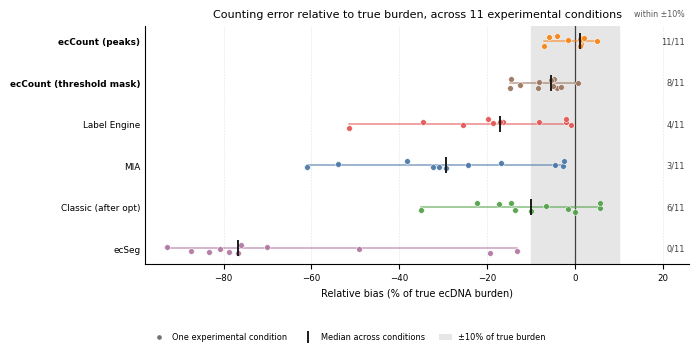

  Saved: figC1_relative_bias_by_method.svg
  Saved: figC1_relative_bias_by_method.png

Headline sentence available from this panel:
  ecCount (peaks) stayed within ±10% of the true burden in 11 of 11 conditions (range -7.1% to +5.0%); ecSeg in 0 of 11 (range -92.8% to -13.2%).


In [16]:
# ── Panel C1 (corrected): Relative bias across conditions ─────────────────
# Sources (values read directly, nothing recomputed):
#   Notebooks-reruning/tables/heatmap_relative_bias_pct_by_condition.csv
#   Notebooks-reruning/tables/error_by_condition_and_method.csv
# Output:
#   figC1_relative_bias_by_method.{svg,png}
#   source_figC1_relative_bias_by_method.csv

DRUG_TAB_DIR = DRUG_NB_DIR / 'tables'

GROUPING = 'group_label'      # 'group_label' (11 dots) or 'cond' (14 dots)
BAND_PCT = 10.0               # reference band, per cent of gold-standard burden

err = pd.read_csv(require_file(
    DRUG_TAB_DIR / 'error_by_condition_and_method.csv',
    label='Per-condition error table',
))
err['model'] = err['model'].apply(canonical_model_name)

ref_wide = pd.read_csv(require_file(
    DRUG_TAB_DIR / 'heatmap_relative_bias_pct_by_condition.csv',
    label='Relative-bias heatmap table',
))
ref_wide['model'] = ref_wide['model'].apply(canonical_model_name)
ref = ref_wide.melt(id_vars='model', var_name='group_label',
                    value_name='relative_bias_pct')

# ── Diagnostic: which labels merge more than one condition? ────────────────
per_label = err.groupby('group_label')['cond'].nunique().sort_values(ascending=False)
merged = per_label[per_label > 1]
single = per_label[per_label == 1].index.tolist()

print(f'Conditions in error table : {err["cond"].nunique()}')
print(f'Group labels              : {err["group_label"].nunique()}')
print(f'Labels merging >1 condition: {len(merged)}')
for lab, n in merged.items():
    members = sorted(err.loc[err['group_label'] == lab, 'cond'].unique().tolist())
    ns = {c: int(err.loc[err['cond'] == c, 'n_images'].max()) for c in members}
    print(f'  {lab}: {n} conditions -> {ns}')

# ── Check the nine one-to-one labels, where no aggregation is involved ─────
one_to_one = (
    err[err['group_label'].isin(single)][['model', 'group_label', 'relative_bias_pct']]
    .merge(ref, on=['model', 'group_label'], how='inner',
           suffixes=('_table', '_heatmap'))
)
d1 = (one_to_one['relative_bias_pct_table']
      - one_to_one['relative_bias_pct_heatmap']).abs().max()
print(f'\nOne-to-one labels: {len(one_to_one)} cells compared, '
      f'max deviation {d1:.4f} pp')
if d1 > 0.05:
    raise ValueError(
        'The per-condition table and the heatmap disagree even where no '
        f'aggregation is involved (max {d1:.4f} pp). The two files are not '
        'describing the same run. Stop and reconcile them before drawing.'
    )
print('  The two files agree wherever they can be compared directly.')

# ── Which rule reproduces the merged columns? Reported, not relied upon. ───
if len(merged):
    print('\nCandidate aggregation rules for the merged labels:')
    sub = err[err['group_label'].isin(merged.index)].copy()

    cand = {}
    g = sub.groupby(['model', 'group_label'], observed=False)
    cand['A ratio of n-weighted sums'] = (
        100.0
        * g.apply(lambda d: (d['count_bias'] * d['n_images']).sum() / d['n_images'].sum(),
                  include_groups=False)
        / g.apply(lambda d: (d['gt_mean'] * d['n_images']).sum() / d['n_images'].sum(),
                  include_groups=False)
    )
    cand['B unweighted mean of per-condition %'] = g['relative_bias_pct'].mean()
    cand['C n-weighted mean of per-condition %'] = g.apply(
        lambda d: np.average(d['relative_bias_pct'], weights=d['n_images']),
        include_groups=False,
    )
    cand['D n-weighted sums, gt_median'] = (
        100.0
        * g.apply(lambda d: (d['count_bias'] * d['n_images']).sum() / d['n_images'].sum(),
                  include_groups=False)
        / g.apply(lambda d: (d['gt_median'] * d['n_images']).sum() / d['n_images'].sum(),
                  include_groups=False)
    )
    cand['E largest condition only'] = g.apply(
        lambda d: d.loc[d['n_images'].idxmax(), 'relative_bias_pct'],
        include_groups=False,
    )

    ref_idx = ref.set_index(['model', 'group_label'])['relative_bias_pct']
    rule_table = pd.DataFrame({'heatmap': ref_idx.reindex(cand['B unweighted mean of per-condition %'].index)})
    for name, series in cand.items():
        rule_table[name] = series
    display(rule_table.round(3))

    print('  Max |rule − heatmap| per rule:')
    matched = []
    for name in cand:
        dev = (rule_table[name] - rule_table['heatmap']).abs().max()
        flag = '   <- reproduces the heatmap' if dev <= 0.05 else ''
        print(f'    {name:38s} {dev:8.4f} pp{flag}')
        if dev <= 0.05:
            matched.append(name)
    if not matched:
        print('    No candidate rule reproduces the merged columns. The heatmap was '
              'built from the per-image data by some other route; worth a note in '
              'the handover, but it does not affect this panel.')

# ── Build the plot table. No recomputation of any plotted value. ───────────
# One row per (condition, model), so de-duplicate before summing image counts.
n_by_cond = err.groupby('cond')['n_images'].max()
n_by_label = (
    err.drop_duplicates(subset=['group_label', 'cond'])
       .groupby('group_label')['n_images'].sum()
)

if GROUPING == 'group_label':
    plot_src = ref.copy()
    plot_src['n_images'] = plot_src['group_label'].map(n_by_label)
    plot_src = plot_src.rename(columns={'group_label': 'condition'})
    SOURCE_NOTE = 'heatmap_relative_bias_pct_by_condition.csv'
elif GROUPING == 'cond':
    plot_src = err[['model', 'cond', 'group_label',
                    'n_images', 'relative_bias_pct']].copy()
    plot_src = plot_src.rename(columns={'cond': 'condition'})
    SOURCE_NOTE = 'error_by_condition_and_method.csv'
else:
    raise ValueError(f"GROUPING must be 'group_label' or 'cond', got {GROUPING!r}")

plot_src = plot_src[plot_src['model'].isin(MODEL_ORDER)].copy()
plot_src = plot_src.dropna(subset=['relative_bias_pct'])

conditions = sorted(plot_src['condition'].unique().tolist())
print(f'\nGrouping: {GROUPING}  (values read from {SOURCE_NOTE})')
print(f'Conditions plotted: {len(conditions)}')
for c in conditions:
    print(f'  {c}  (n = {int(n_by_label.get(c, n_by_cond.get(c, 0)))})')

summary = (
    plot_src.groupby('model', observed=False)
    .agg(n_conditions=('condition', 'nunique'),
         min_rel_bias=('relative_bias_pct', 'min'),
         median_rel_bias=('relative_bias_pct', 'median'),
         max_rel_bias=('relative_bias_pct', 'max'))
    .reindex(MODEL_ORDER)
)
summary['abs_max_rel_bias'] = (
    plot_src.assign(a=plot_src['relative_bias_pct'].abs())
            .groupby('model', observed=False)['a'].max().reindex(MODEL_ORDER)
)
summary['n_within_band'] = (
    plot_src.assign(w=plot_src['relative_bias_pct'].abs() <= BAND_PCT)
            .groupby('model', observed=False)['w'].sum().reindex(MODEL_ORDER).astype(int)
)
display(summary.round(2))

out = plot_src.copy()
out['model'] = pd.Categorical(out['model'], categories=MODEL_ORDER, ordered=True)
out['grouping'] = GROUPING
out['value_source'] = SOURCE_NOTE
out = out.sort_values(['model', 'condition'])
save_source(out, 'source_figC1_relative_bias_by_method')

# ── Draw ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.0, 3.1))

y = np.arange(len(MODEL_ORDER))[::-1]
rng_jitter = np.random.default_rng(0)

ax.axvspan(-BAND_PCT, BAND_PCT, color='0.90', zorder=0)
ax.axvline(0, color='0.25', linewidth=0.9, zorder=1)

for yi, model_name in zip(y, MODEL_ORDER):
    vals = plot_src.loc[plot_src['model'] == model_name,
                        'relative_bias_pct'].to_numpy(float)
    colour = MODEL_COLORS[model_name]

    ax.plot([vals.min(), vals.max()], [yi, yi], color=colour, linewidth=1.4,
            alpha=0.55, solid_capstyle='round', zorder=2)
    ax.scatter(vals, yi + rng_jitter.uniform(-0.13, 0.13, size=len(vals)),
               s=17, color=colour, edgecolor='white', linewidth=0.4,
               alpha=0.95, zorder=4)
    ax.plot([np.median(vals)], [yi], marker='|', color='0.10',
            markersize=11, markeredgewidth=1.4, zorder=5)

ax.set_yticks(y)
ax.set_yticklabels(MODEL_ORDER, fontsize=6.4)
ax.tick_params(axis='y', length=0)
for tick_label in ax.get_yticklabels():
    if tick_label.get_text().startswith('ecCount'):
        tick_label.set_fontweight('bold')

ax.set_xlabel('Relative bias (% of gold-standard ecDNA burden)')
ax.set_title(
    f'Counting error relative to gold-standard burden, across {len(conditions)} '
    'experimental conditions'
)

lo = float(plot_src['relative_bias_pct'].min())
ax.set_xlim(lo - 5, 26)
ax.grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.35)
ax.set_axisbelow(True)

for yi, model_name in zip(y, MODEL_ORDER):
    r = summary.loc[model_name]
    ax.text(25, yi, f'{r["n_within_band"]:.0f}/{r["n_conditions"]:.0f}',
            va='center', ha='right', fontsize=5.9, color='0.25')

ax.text(25, len(MODEL_ORDER) - 0.35, f'within ±{BAND_PCT:.0f}%',
        va='center', ha='right', fontsize=5.7, color='0.35')

legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='0.45',
           markeredgecolor='white', markersize=4.4,
           label='One experimental condition'),
    Line2D([0], [0], marker='|', color='0.10', markersize=9,
           markeredgewidth=1.4, linestyle='none', label='Median across conditions'),
    plt.Rectangle((0, 0), 1, 1, facecolor='0.90', edgecolor='none',
                  label=f'±{BAND_PCT:.0f}% of gold-standard burden'),
]
fig.legend(handles=legend_handles, loc='lower center',
           bbox_to_anchor=(0.5, -0.13), ncol=3, frameon=False,
           fontsize=5.9, handlelength=1.5, columnspacing=1.8)

fig.tight_layout()
display(fig)
save_fig(fig, 'figC1_relative_bias_by_method')
plt.close(fig)

pk = summary.loc['ecCount (peaks)']
es = summary.loc['ecSeg']
print('\nHeadline sentence available from this panel:')
print(f'  ecCount (peaks) stayed within ±{BAND_PCT:.0f}% of the gold-standard burden in '
      f'{pk["n_within_band"]:.0f} of {pk["n_conditions"]:.0f} conditions '
      f'(range {pk["min_rel_bias"]:+.1f}% to {pk["max_rel_bias"]:+.1f}%); '
      f'ecSeg in {es["n_within_band"]:.0f} of {es["n_conditions"]:.0f} '
      f'(range {es["min_rel_bias"]:+.1f}% to {es["max_rel_bias"]:+.1f}%).')

### §11b — Panel C2: treated versus control as a forest plot

Read the panel as: gold standard at the top with a dashed vertical line at its
effect size, then each method below it. A marker sitting far from the dashed
line means the method distorted the effect; a red ring means it reached a
different biological conclusion.

Two things the cell prints that must inform the caption:

- **How many contrasts flip.** In the current data only SNU16 + JQ1 flips a
  verdict. The other contrasts show effect-size distortion without a change of
  conclusion, which is a weaker but still real claim, and the caption must not
  imply otherwise.
- **Which methods agree.** Classic (after opt) also reaches the correct verdict
  on SNU16 + JQ1 (P = 0.157). The locked claim is "three of six methods reach
  the wrong biological conclusion", and the three are Label Engine, MIA and
  ecSeg. The panel should not be captioned as though ecCount alone succeeds.

Subset            : all benchmark drug images
Contrasts available: ['H2170 JQ1 24 h', 'H2170 antibiotics P/S', 'H2170 antibiotics P/S+G', 'H2170 lapatinib 24 h', 'H2170 neratinib 24 h', 'H2170 neratinib 72 h', 'SNU16 JQ1 24 h']

Methods disagreeing with the ground-truth significance call, per contrast:
  H2170 JQ1 24 h             0 of 6
  H2170 antibiotics P/S      0 of 6
  H2170 antibiotics P/S+G    0 of 6
  H2170 lapatinib 24 h       0 of 6
  H2170 neratinib 24 h       0 of 6
  H2170 neratinib 72 h       0 of 6
  SNU16 JQ1 24 h             3 of 6  <- verdict flips

1 of 7 contrasts flip a verdict: ['SNU16 JQ1 24 h']
NOTE: the verdict-flip claim rests on a single experiment. State it as such in the caption.
  Saved source data: source_figC2_contrast_forest.csv  (21 rows)


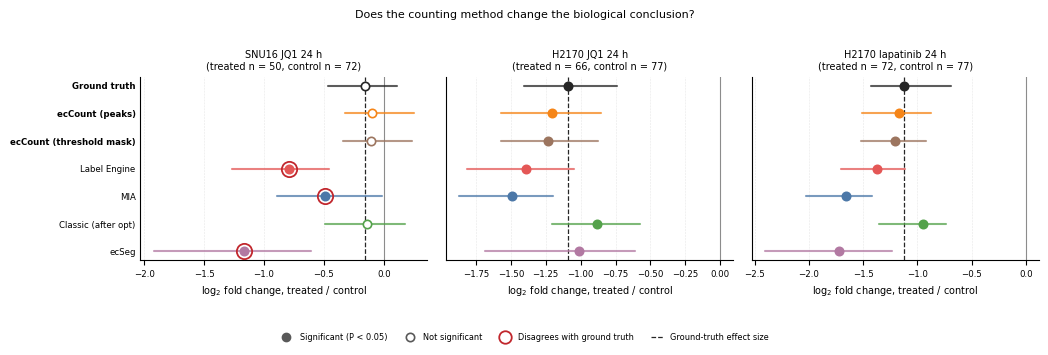

  Saved: figC2_contrast_forest.svg
  Saved: figC2_contrast_forest.png

Verdict table:


,contrast,model,n_treated,n_control,median_treated,median_control,log2_fc,p_mwu,sig_005,gt_log2fc,gt_sig,log2fc_error,sig_agrees,verdict
7,H2170 JQ1 24 h,Ground truth,66,77,131.0,280.0,-1.0929,0.0000,True,-1.0929,True,0.0000,True,significant decrease
8,H2170 JQ1 24 h,ecCount (peaks),66,77,120.5,279.0,-1.2078,0.0000,True,-1.0929,True,-0.1149,True,significant decrease
9,H2170 JQ1 24 h,ecCount (threshold mask),66,77,110.0,259.0,-1.2317,0.0000,True,-1.0929,True,-0.1388,True,significant decrease
11,H2170 JQ1 24 h,Label Engine,66,77,103.0,271.0,-1.3913,0.0000,True,-1.0929,True,-0.2984,True,significant decrease
12,H2170 JQ1 24 h,MIA,66,77,90.5,255.0,-1.4894,0.0000,True,-1.0929,True,-0.3964,True,significant decrease
10,H2170 JQ1 24 h,Classic (after opt),66,77,116.0,214.0,-0.8806,0.0000,True,-1.0929,True,0.2123,True,significant decrease
13,H2170 JQ1 24 h,ecSeg,66,77,31.5,64.0,-1.0112,0.0000,True,-1.0929,True,0.0817,True,significant decrease
14,H2170 lapatinib 24 h,Ground truth,72,77,128.5,280.0,-1.1206,0.0000,True,-1.1206,True,0.0000,True,significant decrease
15,H2170 lapatinib 24 h,ecCount (peaks),72,77,124.0,279.0,-1.1667,0.0000,True,-1.1206,True,-0.0461,True,significant decrease
16,H2170 lapatinib 24 h,ecCount (threshold mask),72,77,112.0,259.0,-1.2058,0.0000,True,-1.1206,True,-0.0852,True,significant decrease


In [17]:
# ── Panel C2: Treated versus control effect size, forest plot ──────────────
# Source:
#   Notebooks-reruning/tables/treatment_contrasts_by_method.csv
# Output:
#   figC2_contrast_forest.{svg,png} + source_figC2_contrast_forest.csv

con = pd.read_csv(require_file(
    DRUG_TAB_DIR / 'treatment_contrasts_by_method.csv',
    label='Treatment contrast table',
))
con['model'] = con['model'].apply(canonical_model_name)

SUBSET = 'all benchmark drug images'
CONTRASTS_TO_SHOW = ['SNU16 JQ1 24 h', 'H2170 JQ1 24 h', 'H2170 lapatinib 24 h']

subsets_present = sorted(con['subset'].unique().tolist())
if SUBSET not in subsets_present:
    raise ValueError(f'Subset "{SUBSET}" not found. Present: {subsets_present}')

cs = con[con['subset'] == SUBSET].copy()
available = sorted(cs['contrast'].unique().tolist())
print(f'Subset            : {SUBSET}')
print(f'Contrasts available: {available}')

missing = [c for c in CONTRASTS_TO_SHOW if c not in available]
if missing:
    raise ValueError(f'Requested contrasts not present: {missing}')

ROW_ORDER = ['Ground truth'] + MODEL_ORDER

# ── How many contrasts actually flip a verdict? ────────────────────────────
flips = (
    cs[cs['model'] != 'Ground truth']
    .groupby('contrast', observed=False)['sig_agrees']
    .apply(lambda s: int((~s.astype(bool)).sum()))
    .reindex(available)
)
print('\nMethods disagreeing with the gold-standard significance call, per contrast:')
for c, n in flips.items():
    marker = '  <- verdict flips' if n > 0 else ''
    print(f'  {c:26s} {n} of 6{marker}')

flipping = [c for c, n in flips.items() if n > 0]
print(f'\n{len(flipping)} of {len(available)} contrasts flip a verdict: {flipping}')
if len(flipping) <= 1:
    print('NOTE: the verdict-flip claim rests on a single experiment. '
          'State it as such in the caption.')

plot_df = cs[cs['contrast'].isin(CONTRASTS_TO_SHOW)].copy()
plot_df['model'] = pd.Categorical(plot_df['model'], categories=ROW_ORDER, ordered=True)
plot_df = plot_df.sort_values(['contrast', 'model'])
save_source(plot_df, 'source_figC2_contrast_forest')

# ── Draw ────────────────────────────────────────────────────────────────────
n_panels = len(CONTRASTS_TO_SHOW)
fig, axes = plt.subplots(1, n_panels, figsize=(3.5 * n_panels, 2.9), sharey=True)
axes = np.atleast_1d(axes)

y = np.arange(len(ROW_ORDER))[::-1]

for ax, contrast in zip(axes, CONTRASTS_TO_SHOW):
    sub = plot_df[plot_df['contrast'] == contrast].set_index('model')
    gt_fc = float(sub.loc['Ground truth', 'log2_fc'])
    n_t = int(sub.loc['Ground truth', 'n_treated'])
    n_c = int(sub.loc['Ground truth', 'n_control'])

    ax.axvline(0, color='0.55', linewidth=0.8, zorder=1)
    ax.axvline(gt_fc, color='0.15', linewidth=0.9, linestyle='--', zorder=2)

    for yi, row_name in zip(y, ROW_ORDER):
        if row_name not in sub.index:
            continue
        r = sub.loc[row_name]
        colour = '0.15' if row_name == 'Ground truth' else MODEL_COLORS[row_name]
        is_sig = bool(r['sig_005'])
        agrees = bool(r['sig_agrees']) if row_name != 'Ground truth' else True

        ax.plot([r['log2_fc_lo'], r['log2_fc_hi']], [yi, yi],
                color=colour, linewidth=1.5, alpha=0.75,
                solid_capstyle='round', zorder=3)
        ax.plot(r['log2_fc'], yi, marker='o', markersize=6.0,
                markerfacecolor=colour if is_sig else 'white',
                markeredgecolor=colour, markeredgewidth=1.2,
                linestyle='none', zorder=5)

        if not agrees:
            ax.plot(r['log2_fc'], yi, marker='o', markersize=11.0,
                    markerfacecolor='none', markeredgecolor='#C1272D',
                    markeredgewidth=1.3, linestyle='none', zorder=6)

    ax.set_yticks(y)
    ax.set_yticklabels(ROW_ORDER, fontsize=6.2)
    ax.tick_params(axis='y', length=0)
    ax.set_xlabel('log$_2$ fold change, treated / control')
    ax.set_title(f'{contrast}\n(treated n = {n_t}, control n = {n_c})', fontsize=7.0)
    ax.grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.3)
    ax.set_axisbelow(True)

for tick_label in axes[0].get_yticklabels():
    txt = tick_label.get_text()
    if txt == 'Ground truth':
        tick_label.set_fontweight('bold')
    elif txt.startswith('ecCount'):
        tick_label.set_fontweight('bold')

legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='0.35',
           markeredgecolor='0.35', markersize=6, label='Significant (P < 0.05)'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='white',
           markeredgecolor='0.35', markeredgewidth=1.2, markersize=6,
           label='Not significant'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='none',
           markeredgecolor='#C1272D', markeredgewidth=1.3, markersize=9,
           label='Disagrees with gold standard'),
    Line2D([0], [0], color='0.15', linewidth=0.9, linestyle='--',
           label='Gold-standard effect size'),
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.14),
           ncol=4, frameon=False, fontsize=5.9, handlelength=1.6)

fig.suptitle(
    'Does the counting method change the biological conclusion?',
    fontsize=8, y=1.03,
)
fig.tight_layout()
display(fig)
save_fig(fig, 'figC2_contrast_forest')
plt.close(fig)

# ── Verdict table for the caption ──────────────────────────────────────────
verdict = plot_df[[
    'contrast', 'model', 'n_treated', 'n_control',
    'median_treated', 'median_control', 'log2_fc', 'p_mwu', 'sig_005',
    'gt_log2fc', 'gt_sig', 'log2fc_error', 'sig_agrees',
]].copy()
verdict['verdict'] = np.where(verdict['sig_005'], 'significant decrease', 'no change')

print('\nVerdict table:')
with pd.option_context('display.max_columns', 40, 'display.width', 200):
    display(verdict.round(4))

### §11c — Panel C3: count heatmap with a gold-standard row

What makes gold standard useful in a heatmap is showing **counts**. Each cell then
holds the mean ecDNA per image that the method reported, with the true value in
the top row. The reader scans down a column and compares directly:

> SNU16 · JQ1 IC50 24 h — truth 261, ecCount (peaks) 266, ecSeg 19.

That is the same comparison the error heatmaps were trying to convey, but in
units a biologist reads without translation.

**Text and colour carry different things.** The number in each cell is the mean
count. The colour is relative bias, the signed error as a percentage of true
burden, which stays comparable across conditions of very different burden. The
gold-standard row sits at zero by construction and is drawn in neutral grey, so it
reads as the reference rather than as a competitor.

`COLOUR_BY` offers three options:

- `'relative_bias_pct'` (default) — the frozen column, comparable across columns.
- `'mae_pct_of_gt'` — count MAE as a percentage of gold-standard burden, also comparable.
- `'count_MAE'` — the raw MAE. Kept available, but **not
  comparable across columns**, because an MAE of 19 means something different
  against a burden of 261 than against a burden of 42. The cell prints that
  warning when the option is selected.

**Legibility.** The annotation colour is chosen from each cell's own background
luminance rather than fixed, so no value can disappear into its cell. That is the
defect that hid the ecCount row in `fig7e` and the ecSeg row in `fig7f`.

**Sourcing.** `GROUPING` defaults to `'cond'`, giving one column per condition
straight out of `error_by_condition_and_method.csv` with no aggregation at all.
Setting it to `'group_label'` pools the three H2170 control experiments and the
two H716 control experiments; pooling means by image count is exact, so this is
safe, but it is a different set of columns from the frozen heatmap and is not
compared against it.

Outputs:

- `figC3_count_heatmap_with_gt.{svg,png}`
- `source_figC3_count_heatmap_with_gt.csv`

Ground-truth mean is identical across models within every condition (max spread 0.00e+00).
pred_mean − gt_mean vs count_bias      : max deviation 0.000000
100·count_bias/gt_mean vs relative_bias : max deviation 0.000000
  Saved source data: source_figC3_count_heatmap_with_gt.csv  (98 rows)

Grouping : cond (one column per condition, no pooling)
Columns  : 14
Colour   : relative_bias_pct


,ncih2170_ctrl_2,ncih2170_ctrl_1,ncih2170_antibiotics_blank_ctrl,ncih2170_jc_ner_ic50_72h,ncih2170_antibiotics_ps_g,ncih2170_antibiotics_ps,ncih2170_jc_ner_ic50_24h,ncih2170_jc_jq1_ic50_24h,ncih2170_jc_lap_ic50_24h,snu16_jc_ctrl,snu16_jc_jq1_ic50_24h,colo320dm_qpcr_jq1_24h_ctrl,ncih716_jc_ctrl_1,ncih716_jc_ctrl_2
Ground truth,331,321,255,421,222,192,188,166,150,302,260,50,193,191
ecCount (peaks),327,326,263,426,225,194,190,154,141,289,266,49,205,198
ecCount (threshold mask),305,308,248,369,211,182,172,141,128,277,252,48,196,190
Label Engine,313,321,252,387,217,191,155,135,120,225,126,41,128,123
MIA,293,310,258,318,217,187,130,117,92,139,102,41,129,131
Classic (after opt),246,256,261,273,200,180,155,143,116,302,257,52,215,191
ecSeg,76,124,231,98,179,167,31,40,29,38,19,11,51,63


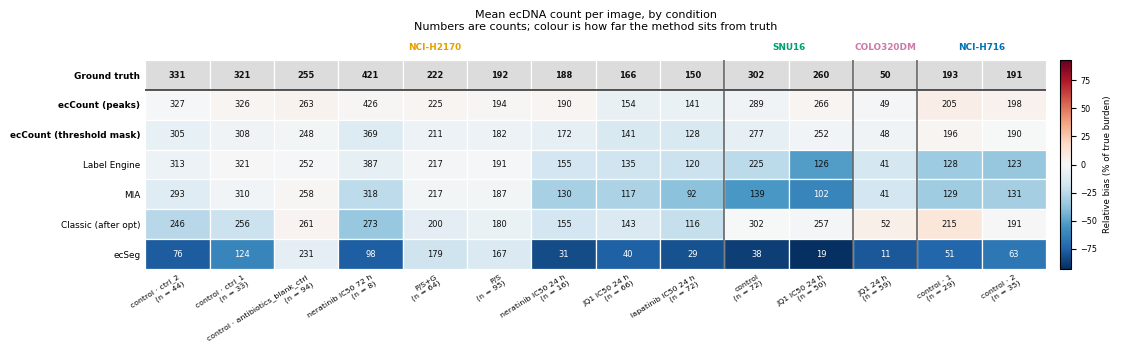

  Saved: figC3_count_heatmap_with_gt_relative_bias_pct.svg
  Saved: figC3_count_heatmap_with_gt_relative_bias_pct.png

Worst-case departure from truth across all columns (relative bias):
  ecCount (peaks)                7.1
  ecCount (threshold mask)      14.8
  Label Engine                  51.5
  MIA                           60.9
  Classic (after opt)           35.1
  ecSeg                         92.8

Highest-burden column: ncih2170_jc_ner_ic50_72h (truth 421 ecDNA per image, ecCount (peaks) 426, ecSeg 98)


In [18]:
# ── Panel C3: Count heatmap with a gold-standard row ───────────────────────
# Source:
#   Notebooks-reruning/tables/error_by_condition_and_method.csv
# Output:
#   figC3_count_heatmap_with_gt.{svg,png}
#   source_figC3_count_heatmap_with_gt.csv

from matplotlib.colors import TwoSlopeNorm, Normalize

DRUG_TAB_DIR = DRUG_NB_DIR / 'tables'

GROUPING = 'cond'                      # 'cond' (no pooling) or 'group_label'
COLOUR_BY = 'relative_bias_pct'        # or 'mae_pct_of_gt' or 'count_MAE' or 'relative_bias_pct'

err = pd.read_csv(require_file(
    DRUG_TAB_DIR / 'error_by_condition_and_method.csv',
    label='Per-condition error table',
))
err['model'] = err['model'].apply(canonical_model_name)
err = err[err['model'].isin(MODEL_ORDER)].copy()

# ── Integrity checks on the frozen table ───────────────────────────────────
gt_spread = err.groupby('cond')['gt_mean'].agg(lambda s: s.max() - s.min()).max()
if gt_spread > 1e-6:
    raise ValueError(
        f'gt_mean varies across models within a condition (max spread '
        f'{gt_spread:.6f}). The models are not being scored on the same images.'
    )
print(f'Gold-standard mean is identical across models within every condition '
      f'(max spread {gt_spread:.2e}).')

d_bias = (err['pred_mean'] - err['gt_mean'] - err['count_bias']).abs().max()
d_rel = (100.0 * err['count_bias'] / err['gt_mean']
         - err['relative_bias_pct']).abs().max()
print(f'pred_mean − gt_mean vs count_bias      : max deviation {d_bias:.6f}')
print(f'100·count_bias/gt_mean vs relative_bias : max deviation {d_rel:.6f}')
if max(d_bias, d_rel) > 1e-4:
    raise ValueError(
        'The frozen table is internally inconsistent between count_bias, '
        'pred_mean/gt_mean and relative_bias_pct. Stop and reconcile.'
    )

# ── Column construction ────────────────────────────────────────────────────
if GROUPING == 'cond':
    cell = err.copy()
    cell['column'] = cell['cond']
    POOLED_NOTE = 'one column per condition, no pooling'
elif GROUPING == 'group_label':
    # Pooling means by image count is exact: sum(n_i * mean_i) / sum(n_i).
    cell = (
        err.assign(_gt=lambda d: d['gt_mean'] * d['n_images'],
                   _pr=lambda d: d['pred_mean'] * d['n_images'],
                   _ae=lambda d: d['count_MAE'] * d['n_images'])
        .groupby(['model', 'group_label', 'cell_line', 'arm'],
                 observed=False, as_index=False)
        .agg(n_images=('n_images', 'sum'), _gt=('_gt', 'sum'),
             _pr=('_pr', 'sum'), _ae=('_ae', 'sum'))
    )
    cell['gt_mean'] = cell['_gt'] / cell['n_images']
    cell['pred_mean'] = cell['_pr'] / cell['n_images']
    cell['count_MAE'] = cell['_ae'] / cell['n_images']
    cell['count_bias'] = cell['pred_mean'] - cell['gt_mean']
    cell['relative_bias_pct'] = 100.0 * cell['count_bias'] / cell['gt_mean']
    cell['column'] = cell['group_label']
    cell = cell.drop(columns=['_gt', '_pr', '_ae'])
    POOLED_NOTE = 'conditions pooled to group labels, image-count weighted'
else:
    raise ValueError(f"GROUPING must be 'cond' or 'group_label', got {GROUPING!r}")

cell['mae_pct_of_gt'] = 100.0 * cell['count_MAE'] / cell['gt_mean']

if COLOUR_BY not in {'relative_bias_pct', 'mae_pct_of_gt', 'count_MAE'}:
    raise ValueError(f'Unsupported COLOUR_BY: {COLOUR_BY!r}')
if COLOUR_BY == 'count_MAE':
    print('\nWARNING: raw count MAE is not comparable across columns, because '
          'burden differs between conditions. Compare within a column only, or '
          "use COLOUR_BY = 'mae_pct_of_gt'.")

# Column order: cell line, then control before treated, then burden descending.
col_meta = (
    cell.drop_duplicates('column')[['column', 'cell_line', 'arm', 'gt_mean']]
    .assign(cell_line=lambda d: d['cell_line'].apply(canonical_cell_line))
)
col_meta['cl_rank'] = col_meta['cell_line'].apply(
    lambda c: CL_ORDER.index(c) if c in CL_ORDER else len(CL_ORDER)
)
col_meta['arm_rank'] = (col_meta['arm'].astype(str).str.lower() != 'control').astype(int)
col_meta = col_meta.sort_values(['cl_rank', 'arm_rank', 'gt_mean'],
                                ascending=[True, True, False])
COLUMNS = col_meta['column'].tolist()

n_images = cell.drop_duplicates('column').set_index('column')['n_images']

# Short, readable column labels; disambiguate pooled-away conditions.
def short_label(col):
    row = col_meta[col_meta['column'] == col].iloc[0]
    if GROUPING == 'group_label':
        text = col.split(' · ')[-1]
    else:
        sub = err[err['cond'] == col].iloc[0]
        text = str(sub['group_label']).split(' · ')[-1]
        siblings = err.loc[err['group_label'] == sub['group_label'], 'cond'].unique()
        if len(siblings) > 1:
            prefix = os.path.commonprefix(sorted(siblings.tolist()))
            tag = col[len(prefix):] or col
            text = f'{text} · {tag}'
    return f'{text}\n(n = {int(n_images[col])})'

# ── Matrices ───────────────────────────────────────────────────────────────
ROW_ORDER = ['Ground truth'] + MODEL_ORDER

counts = pd.DataFrame(index=ROW_ORDER, columns=COLUMNS, dtype=float)
colour = pd.DataFrame(index=ROW_ORDER, columns=COLUMNS, dtype=float)

piv_pred = cell.pivot_table(index='model', columns='column', values='pred_mean')
piv_col = cell.pivot_table(index='model', columns='column', values=COLOUR_BY)
gt_by_col = cell.drop_duplicates('column').set_index('column')['gt_mean']

counts.loc['Ground truth', COLUMNS] = gt_by_col.reindex(COLUMNS).values
colour.loc['Ground truth', COLUMNS] = 0.0
for m in MODEL_ORDER:
    counts.loc[m, COLUMNS] = piv_pred.loc[m, COLUMNS].values
    colour.loc[m, COLUMNS] = piv_col.loc[m, COLUMNS].values

long = (
    counts.reset_index().melt(id_vars='index', var_name='column',
                              value_name='mean_count')
    .rename(columns={'index': 'row'})
    .merge(colour.reset_index().melt(id_vars='index', var_name='column',
                                     value_name=COLOUR_BY)
           .rename(columns={'index': 'row'}),
           on=['row', 'column'], how='left')
)
long['n_images'] = long['column'].map(n_images)
long['grouping'] = GROUPING
long['colour_metric'] = COLOUR_BY
save_source(long, 'source_figC3_count_heatmap_with_gt')

print(f'\nGrouping : {GROUPING} ({POOLED_NOTE})')
print(f'Columns  : {len(COLUMNS)}')
print(f'Colour   : {COLOUR_BY}')
display(counts.round(0).astype('Int64'))

# ── Draw ───────────────────────────────────────────────────────────────────
def annot_colour(rgba):
    """Pick black or white text from the cell's own background luminance."""
    lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
    return 'white' if lum < 0.52 else '#111111'


vals = colour.loc[MODEL_ORDER].to_numpy(dtype=float)
if COLOUR_BY == 'count_MAE':
    cmap = plt.get_cmap('Reds')
    norm = Normalize(vmin=0, vmax=np.nanmax(vals))
    cbar_label = 'Count MAE (ecDNA per image)'
elif COLOUR_BY == 'mae_pct_of_gt':
    cmap = plt.get_cmap('Reds')
    norm = Normalize(vmin=0, vmax=np.nanmax(vals))
    cbar_label = 'Count MAE (% of gold-standard burden)'
else:
    cmap = plt.get_cmap('RdBu_r')
    lim = float(np.nanmax(np.abs(vals)))
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-lim, vmax=lim)
    cbar_label = 'Relative bias (% of gold-standard burden)'

GT_FILL = '#DCDCDC'

fig, ax = plt.subplots(figsize=(0.62 * len(COLUMNS) + 2.6, 3.6))

for i, row_name in enumerate(ROW_ORDER):
    for j, col_name in enumerate(COLUMNS):
        v_count = counts.iloc[i, j]
        v_col = colour.iloc[i, j]

        if row_name == 'Ground truth':
            rgba = matplotlib.colors.to_rgba(GT_FILL)
        elif np.isnan(v_col):
            rgba = (1.0, 1.0, 1.0, 1.0)
        else:
            rgba = cmap(norm(v_col))

        ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=rgba,
                                   edgecolor='white', linewidth=0.9))
        if not np.isnan(v_count):
            ax.text(j + 0.5, i + 0.5, f'{v_count:.0f}',
                    ha='center', va='center', fontsize=6.0,
                    color=annot_colour(rgba),
                    fontweight='bold' if row_name == 'Ground truth' else 'normal')

ax.set_xlim(0, len(COLUMNS))
ax.set_ylim(len(ROW_ORDER), 0)

ax.set_xticks(np.arange(len(COLUMNS)) + 0.5)
ax.set_xticklabels([short_label(c) for c in COLUMNS], fontsize=5.6,
                   rotation=32, ha='right', rotation_mode='anchor')
ax.set_yticks(np.arange(len(ROW_ORDER)) + 0.5)
ax.set_yticklabels(ROW_ORDER, fontsize=6.4)
ax.tick_params(length=0)

for tick_label in ax.get_yticklabels():
    txt = tick_label.get_text()
    if txt == 'Ground truth' or txt.startswith('ecCount'):
        tick_label.set_fontweight('bold')

# Separate the gold-standard row from the methods.
ax.plot([0, len(COLUMNS)], [1, 1], color='0.15', linewidth=1.1, zorder=6)

# Cell-line group separators and headers.
cl_seq = col_meta.set_index('column').loc[COLUMNS, 'cell_line'].tolist()
start = 0
for k in range(1, len(cl_seq) + 1):
    if k == len(cl_seq) or cl_seq[k] != cl_seq[start]:
        if k < len(cl_seq):
            ax.plot([k, k], [0, len(ROW_ORDER)], color='0.35',
                    linewidth=1.1, zorder=6)
        ax.text((start + k) / 2, -0.28, cl_seq[start], ha='center', va='bottom',
                fontsize=6.4, fontweight='bold',
                color=CELL_LINE_COLORS.get(cl_seq[start], '0.2'))
        start = k

for spine in ax.spines.values():
    spine.set_visible(False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, fraction=0.026, pad=0.015)
cbar.set_label(cbar_label, fontsize=6.2)
cbar.ax.tick_params(labelsize=5.8)

ax.set_title(
    'Mean ecDNA count per image, by condition\n'
    'Numbers are counts; colour is how far the method sits from truth',
    fontsize=8, pad=22,
)

fig.tight_layout()
display(fig)
save_fig(fig, 'figC3_count_heatmap_with_gt_relative_bias_pct')
plt.close(fig)

# ── A sentence the panel supports ──────────────────────────────────────────
worst = colour.loc[MODEL_ORDER].abs().max(axis=1).sort_values()
best_col = counts.columns[int(np.argmax(counts.loc['Ground truth'].values))]
print('\nWorst-case departure from truth across all columns '
      f'({cbar_label.split(" (")[0].lower()}):')
for m in MODEL_ORDER:
    print(f'  {m:26s} {worst[m]:7.1f}')
print(f'\nHighest-burden column: {best_col} '
      f'(truth {counts.loc["Ground truth", best_col]:.0f} ecDNA per image, '
      f'ecCount (peaks) {counts.loc["ecCount (peaks)", best_col]:.0f}, '
      f'ecSeg {counts.loc["ecSeg", best_col]:.0f})')

Ground-truth mean is identical across models within every condition (max spread 0.00e+00).
pred_mean − gt_mean vs count_bias      : max deviation 0.000000
100·count_bias/gt_mean vs relative_bias : max deviation 0.000000
  Saved source data: source_figC3_count_heatmap_with_gt.csv  (98 rows)

Grouping : cond (one column per condition, no pooling)
Columns  : 14
Colour   : mae_pct_of_gt


,ncih2170_ctrl_2,ncih2170_ctrl_1,ncih2170_antibiotics_blank_ctrl,ncih2170_jc_ner_ic50_72h,ncih2170_antibiotics_ps_g,ncih2170_antibiotics_ps,ncih2170_jc_ner_ic50_24h,ncih2170_jc_jq1_ic50_24h,ncih2170_jc_lap_ic50_24h,snu16_jc_ctrl,snu16_jc_jq1_ic50_24h,colo320dm_qpcr_jq1_24h_ctrl,ncih716_jc_ctrl_1,ncih716_jc_ctrl_2
Ground truth,331,321,255,421,222,192,188,166,150,302,260,50,193,191
ecCount (peaks),327,326,263,426,225,194,190,154,141,289,266,49,205,198
ecCount (threshold mask),305,308,248,369,211,182,172,141,128,277,252,48,196,190
Label Engine,313,321,252,387,217,191,155,135,120,225,126,41,128,123
MIA,293,310,258,318,217,187,130,117,92,139,102,41,129,131
Classic (after opt),246,256,261,273,200,180,155,143,116,302,257,52,215,191
ecSeg,76,124,231,98,179,167,31,40,29,38,19,11,51,63


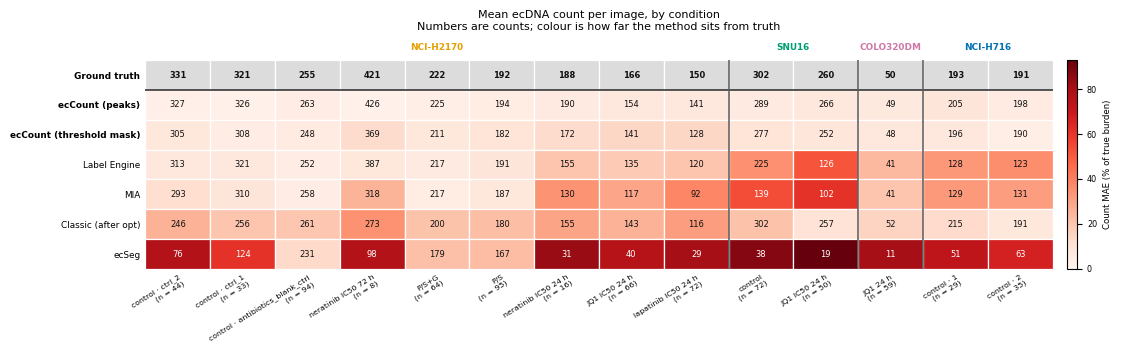

  Saved: figC3_count_heatmap_with_gt_mae_pct_of_gt.svg
  Saved: figC3_count_heatmap_with_gt_mae_pct_of_gt.png

Worst-case departure from truth across all columns (count mae):
  ecCount (peaks)                8.8
  ecCount (threshold mask)      14.8
  Label Engine                  51.6
  MIA                           61.2
  Classic (after opt)           35.1
  ecSeg                         92.8

Highest-burden column: ncih2170_jc_ner_ic50_72h (truth 421 ecDNA per image, ecCount (peaks) 426, ecSeg 98)


In [19]:
# ── Panel C3: Count heatmap with a gold-standard row ───────────────────────
# Source:
#   Notebooks-reruning/tables/error_by_condition_and_method.csv
# Output:
#   figC3_count_heatmap_with_gt.{svg,png}
#   source_figC3_count_heatmap_with_gt.csv

from matplotlib.colors import TwoSlopeNorm, Normalize

DRUG_TAB_DIR = DRUG_NB_DIR / 'tables'

GROUPING = 'cond'                      # 'cond' (no pooling) or 'group_label'
COLOUR_BY = 'mae_pct_of_gt'        # or 'mae_pct_of_gt' or 'count_MAE' or 'relative_bias_pct'

err = pd.read_csv(require_file(
    DRUG_TAB_DIR / 'error_by_condition_and_method.csv',
    label='Per-condition error table',
))
err['model'] = err['model'].apply(canonical_model_name)
err = err[err['model'].isin(MODEL_ORDER)].copy()

# ── Integrity checks on the frozen table ───────────────────────────────────
gt_spread = err.groupby('cond')['gt_mean'].agg(lambda s: s.max() - s.min()).max()
if gt_spread > 1e-6:
    raise ValueError(
        f'gt_mean varies across models within a condition (max spread '
        f'{gt_spread:.6f}). The models are not being scored on the same images.'
    )
print(f'Gold-standard mean is identical across models within every condition '
      f'(max spread {gt_spread:.2e}).')

d_bias = (err['pred_mean'] - err['gt_mean'] - err['count_bias']).abs().max()
d_rel = (100.0 * err['count_bias'] / err['gt_mean']
         - err['relative_bias_pct']).abs().max()
print(f'pred_mean − gt_mean vs count_bias      : max deviation {d_bias:.6f}')
print(f'100·count_bias/gt_mean vs relative_bias : max deviation {d_rel:.6f}')
if max(d_bias, d_rel) > 1e-4:
    raise ValueError(
        'The frozen table is internally inconsistent between count_bias, '
        'pred_mean/gt_mean and relative_bias_pct. Stop and reconcile.'
    )

# ── Column construction ────────────────────────────────────────────────────
if GROUPING == 'cond':
    cell = err.copy()
    cell['column'] = cell['cond']
    POOLED_NOTE = 'one column per condition, no pooling'
elif GROUPING == 'group_label':
    # Pooling means by image count is exact: sum(n_i * mean_i) / sum(n_i).
    cell = (
        err.assign(_gt=lambda d: d['gt_mean'] * d['n_images'],
                   _pr=lambda d: d['pred_mean'] * d['n_images'],
                   _ae=lambda d: d['count_MAE'] * d['n_images'])
        .groupby(['model', 'group_label', 'cell_line', 'arm'],
                 observed=False, as_index=False)
        .agg(n_images=('n_images', 'sum'), _gt=('_gt', 'sum'),
             _pr=('_pr', 'sum'), _ae=('_ae', 'sum'))
    )
    cell['gt_mean'] = cell['_gt'] / cell['n_images']
    cell['pred_mean'] = cell['_pr'] / cell['n_images']
    cell['count_MAE'] = cell['_ae'] / cell['n_images']
    cell['count_bias'] = cell['pred_mean'] - cell['gt_mean']
    cell['relative_bias_pct'] = 100.0 * cell['count_bias'] / cell['gt_mean']
    cell['column'] = cell['group_label']
    cell = cell.drop(columns=['_gt', '_pr', '_ae'])
    POOLED_NOTE = 'conditions pooled to group labels, image-count weighted'
else:
    raise ValueError(f"GROUPING must be 'cond' or 'group_label', got {GROUPING!r}")

cell['mae_pct_of_gt'] = 100.0 * cell['count_MAE'] / cell['gt_mean']

if COLOUR_BY not in {'relative_bias_pct', 'mae_pct_of_gt', 'count_MAE'}:
    raise ValueError(f'Unsupported COLOUR_BY: {COLOUR_BY!r}')
if COLOUR_BY == 'count_MAE':
    print('\nWARNING: raw count MAE is not comparable across columns, because '
          'burden differs between conditions. Compare within a column only, or '
          "use COLOUR_BY = 'mae_pct_of_gt'.")

# Column order: cell line, then control before treated, then burden descending.
col_meta = (
    cell.drop_duplicates('column')[['column', 'cell_line', 'arm', 'gt_mean']]
    .assign(cell_line=lambda d: d['cell_line'].apply(canonical_cell_line))
)
col_meta['cl_rank'] = col_meta['cell_line'].apply(
    lambda c: CL_ORDER.index(c) if c in CL_ORDER else len(CL_ORDER)
)
col_meta['arm_rank'] = (col_meta['arm'].astype(str).str.lower() != 'control').astype(int)
col_meta = col_meta.sort_values(['cl_rank', 'arm_rank', 'gt_mean'],
                                ascending=[True, True, False])
COLUMNS = col_meta['column'].tolist()

n_images = cell.drop_duplicates('column').set_index('column')['n_images']

# Short, readable column labels; disambiguate pooled-away conditions.
def short_label(col):
    row = col_meta[col_meta['column'] == col].iloc[0]
    if GROUPING == 'group_label':
        text = col.split(' · ')[-1]
    else:
        sub = err[err['cond'] == col].iloc[0]
        text = str(sub['group_label']).split(' · ')[-1]
        siblings = err.loc[err['group_label'] == sub['group_label'], 'cond'].unique()
        if len(siblings) > 1:
            prefix = os.path.commonprefix(sorted(siblings.tolist()))
            tag = col[len(prefix):] or col
            text = f'{text} · {tag}'
    return f'{text}\n(n = {int(n_images[col])})'

# ── Matrices ───────────────────────────────────────────────────────────────
ROW_ORDER = ['Ground truth'] + MODEL_ORDER

counts = pd.DataFrame(index=ROW_ORDER, columns=COLUMNS, dtype=float)
colour = pd.DataFrame(index=ROW_ORDER, columns=COLUMNS, dtype=float)

piv_pred = cell.pivot_table(index='model', columns='column', values='pred_mean')
piv_col = cell.pivot_table(index='model', columns='column', values=COLOUR_BY)
gt_by_col = cell.drop_duplicates('column').set_index('column')['gt_mean']

counts.loc['Ground truth', COLUMNS] = gt_by_col.reindex(COLUMNS).values
colour.loc['Ground truth', COLUMNS] = 0.0
for m in MODEL_ORDER:
    counts.loc[m, COLUMNS] = piv_pred.loc[m, COLUMNS].values
    colour.loc[m, COLUMNS] = piv_col.loc[m, COLUMNS].values

long = (
    counts.reset_index().melt(id_vars='index', var_name='column',
                              value_name='mean_count')
    .rename(columns={'index': 'row'})
    .merge(colour.reset_index().melt(id_vars='index', var_name='column',
                                     value_name=COLOUR_BY)
           .rename(columns={'index': 'row'}),
           on=['row', 'column'], how='left')
)
long['n_images'] = long['column'].map(n_images)
long['grouping'] = GROUPING
long['colour_metric'] = COLOUR_BY
save_source(long, 'source_figC3_count_heatmap_with_gt')

print(f'\nGrouping : {GROUPING} ({POOLED_NOTE})')
print(f'Columns  : {len(COLUMNS)}')
print(f'Colour   : {COLOUR_BY}')
display(counts.round(0).astype('Int64'))

# ── Draw ───────────────────────────────────────────────────────────────────
def annot_colour(rgba):
    """Pick black or white text from the cell's own background luminance."""
    lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
    return 'white' if lum < 0.52 else '#111111'


vals = colour.loc[MODEL_ORDER].to_numpy(dtype=float)
if COLOUR_BY == 'count_MAE':
    cmap = plt.get_cmap('Reds')
    norm = Normalize(vmin=0, vmax=np.nanmax(vals))
    cbar_label = 'Count MAE (ecDNA per image)'
elif COLOUR_BY == 'mae_pct_of_gt':
    cmap = plt.get_cmap('Reds')
    norm = Normalize(vmin=0, vmax=np.nanmax(vals))
    cbar_label = 'Count MAE (% of gold-standard burden)'
else:
    cmap = plt.get_cmap('RdBu_r')
    lim = float(np.nanmax(np.abs(vals)))
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-lim, vmax=lim)
    cbar_label = 'Relative bias (% of gold-standard burden)'

GT_FILL = '#DCDCDC'

fig, ax = plt.subplots(figsize=(0.62 * len(COLUMNS) + 2.6, 3.6))

for i, row_name in enumerate(ROW_ORDER):
    for j, col_name in enumerate(COLUMNS):
        v_count = counts.iloc[i, j]
        v_col = colour.iloc[i, j]

        if row_name == 'Ground truth':
            rgba = matplotlib.colors.to_rgba(GT_FILL)
        elif np.isnan(v_col):
            rgba = (1.0, 1.0, 1.0, 1.0)
        else:
            rgba = cmap(norm(v_col))

        ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=rgba,
                                   edgecolor='white', linewidth=0.9))
        if not np.isnan(v_count):
            ax.text(j + 0.5, i + 0.5, f'{v_count:.0f}',
                    ha='center', va='center', fontsize=6.0,
                    color=annot_colour(rgba),
                    fontweight='bold' if row_name == 'Ground truth' else 'normal')

ax.set_xlim(0, len(COLUMNS))
ax.set_ylim(len(ROW_ORDER), 0)

ax.set_xticks(np.arange(len(COLUMNS)) + 0.5)
ax.set_xticklabels([short_label(c) for c in COLUMNS], fontsize=5.6,
                   rotation=32, ha='right', rotation_mode='anchor')
ax.set_yticks(np.arange(len(ROW_ORDER)) + 0.5)
ax.set_yticklabels(ROW_ORDER, fontsize=6.4)
ax.tick_params(length=0)

for tick_label in ax.get_yticklabels():
    txt = tick_label.get_text()
    if txt == 'Ground truth' or txt.startswith('ecCount'):
        tick_label.set_fontweight('bold')

# Separate the gold-standard row from the methods.
ax.plot([0, len(COLUMNS)], [1, 1], color='0.15', linewidth=1.1, zorder=6)

# Cell-line group separators and headers.
cl_seq = col_meta.set_index('column').loc[COLUMNS, 'cell_line'].tolist()
start = 0
for k in range(1, len(cl_seq) + 1):
    if k == len(cl_seq) or cl_seq[k] != cl_seq[start]:
        if k < len(cl_seq):
            ax.plot([k, k], [0, len(ROW_ORDER)], color='0.35',
                    linewidth=1.1, zorder=6)
        ax.text((start + k) / 2, -0.28, cl_seq[start], ha='center', va='bottom',
                fontsize=6.4, fontweight='bold',
                color=CELL_LINE_COLORS.get(cl_seq[start], '0.2'))
        start = k

for spine in ax.spines.values():
    spine.set_visible(False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, fraction=0.026, pad=0.015)
cbar.set_label(cbar_label, fontsize=6.2)
cbar.ax.tick_params(labelsize=5.8)

ax.set_title(
    'Mean ecDNA count per image, by condition\n'
    'Numbers are counts; colour is how far the method sits from truth',
    fontsize=8, pad=22,
)

fig.tight_layout()
display(fig)
save_fig(fig, 'figC3_count_heatmap_with_gt_mae_pct_of_gt')
plt.close(fig)

# ── A sentence the panel supports ──────────────────────────────────────────
worst = colour.loc[MODEL_ORDER].abs().max(axis=1).sort_values()
best_col = counts.columns[int(np.argmax(counts.loc['Ground truth'].values))]
print('\nWorst-case departure from truth across all columns '
      f'({cbar_label.split(" (")[0].lower()}):')
for m in MODEL_ORDER:
    print(f'  {m:26s} {worst[m]:7.1f}')
print(f'\nHighest-burden column: {best_col} '
      f'(truth {counts.loc["Ground truth", best_col]:.0f} ecDNA per image, '
      f'ecCount (peaks) {counts.loc["ecCount (peaks)", best_col]:.0f}, '
      f'ecSeg {counts.loc["ecSeg", best_col]:.0f})')

Ground-truth mean is identical across models within every condition (max spread 0.00e+00).
pred_mean − gt_mean vs count_bias      : max deviation 0.000000
100·count_bias/gt_mean vs relative_bias : max deviation 0.000000

  Saved source data: source_figC3_count_heatmap_with_gt.csv  (98 rows)

Grouping : cond (one column per condition, no pooling)
Columns  : 14
Colour   : count_MAE


,ncih2170_ctrl_2,ncih2170_ctrl_1,ncih2170_antibiotics_blank_ctrl,ncih2170_jc_ner_ic50_72h,ncih2170_antibiotics_ps_g,ncih2170_antibiotics_ps,ncih2170_jc_ner_ic50_24h,ncih2170_jc_jq1_ic50_24h,ncih2170_jc_lap_ic50_24h,snu16_jc_ctrl,snu16_jc_jq1_ic50_24h,colo320dm_qpcr_jq1_24h_ctrl,ncih716_jc_ctrl_1,ncih716_jc_ctrl_2
Ground truth,331,321,255,421,222,192,188,166,150,302,260,50,193,191
ecCount (peaks),327,326,263,426,225,194,190,154,141,289,266,49,205,198
ecCount (threshold mask),305,308,248,369,211,182,172,141,128,277,252,48,196,190
Label Engine,313,321,252,387,217,191,155,135,120,225,126,41,128,123
MIA,293,310,258,318,217,187,130,117,92,139,102,41,129,131
Classic (after opt),246,256,261,273,200,180,155,143,116,302,257,52,215,191
ecSeg,76,124,231,98,179,167,31,40,29,38,19,11,51,63


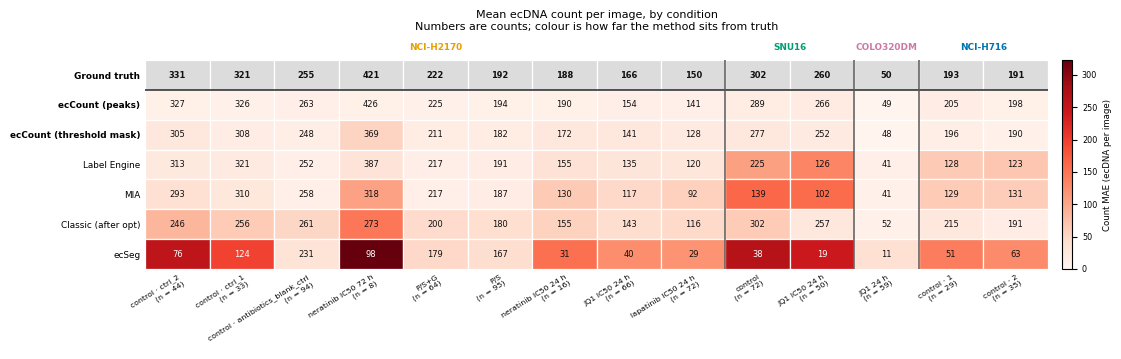

  Saved: figC3_count_heatmap_with_gt_count_MAE.svg
  Saved: figC3_count_heatmap_with_gt_count_MAE.png

Worst-case departure from truth across all columns (count mae):
  ecCount (peaks)               19.0
  ecCount (threshold mask)      54.9
  Label Engine                 134.4
  MIA                          162.8
  Classic (after opt)          147.8
  ecSeg                        322.8

Highest-burden column: ncih2170_jc_ner_ic50_72h (truth 421 ecDNA per image, ecCount (peaks) 426, ecSeg 98)


In [20]:
# ── Panel C3: Count heatmap with a gold-standard row ───────────────────────
# Source:
#   Notebooks-reruning/tables/error_by_condition_and_method.csv
# Output:
#   figC3_count_heatmap_with_gt.{svg,png}
#   source_figC3_count_heatmap_with_gt.csv

from matplotlib.colors import TwoSlopeNorm, Normalize

DRUG_TAB_DIR = DRUG_NB_DIR / 'tables'

GROUPING = 'cond'                      # 'cond' (no pooling) or 'group_label'
COLOUR_BY = 'count_MAE'        # or 'mae_pct_of_gt' or 'count_MAE' or 'relative_bias_pct'

err = pd.read_csv(require_file(
    DRUG_TAB_DIR / 'error_by_condition_and_method.csv',
    label='Per-condition error table',
))
err['model'] = err['model'].apply(canonical_model_name)
err = err[err['model'].isin(MODEL_ORDER)].copy()

# ── Integrity checks on the frozen table ───────────────────────────────────
gt_spread = err.groupby('cond')['gt_mean'].agg(lambda s: s.max() - s.min()).max()
if gt_spread > 1e-6:
    raise ValueError(
        f'gt_mean varies across models within a condition (max spread '
        f'{gt_spread:.6f}). The models are not being scored on the same images.'
    )
print(f'Gold-standard mean is identical across models within every condition '
      f'(max spread {gt_spread:.2e}).')

d_bias = (err['pred_mean'] - err['gt_mean'] - err['count_bias']).abs().max()
d_rel = (100.0 * err['count_bias'] / err['gt_mean']
         - err['relative_bias_pct']).abs().max()
print(f'pred_mean − gt_mean vs count_bias      : max deviation {d_bias:.6f}')
print(f'100·count_bias/gt_mean vs relative_bias : max deviation {d_rel:.6f}')
if max(d_bias, d_rel) > 1e-4:
    raise ValueError(
        'The frozen table is internally inconsistent between count_bias, '
        'pred_mean/gt_mean and relative_bias_pct. Stop and reconcile.'
    )

# ── Column construction ────────────────────────────────────────────────────
if GROUPING == 'cond':
    cell = err.copy()
    cell['column'] = cell['cond']
    POOLED_NOTE = 'one column per condition, no pooling'
elif GROUPING == 'group_label':
    # Pooling means by image count is exact: sum(n_i * mean_i) / sum(n_i).
    cell = (
        err.assign(_gt=lambda d: d['gt_mean'] * d['n_images'],
                   _pr=lambda d: d['pred_mean'] * d['n_images'],
                   _ae=lambda d: d['count_MAE'] * d['n_images'])
        .groupby(['model', 'group_label', 'cell_line', 'arm'],
                 observed=False, as_index=False)
        .agg(n_images=('n_images', 'sum'), _gt=('_gt', 'sum'),
             _pr=('_pr', 'sum'), _ae=('_ae', 'sum'))
    )
    cell['gt_mean'] = cell['_gt'] / cell['n_images']
    cell['pred_mean'] = cell['_pr'] / cell['n_images']
    cell['count_MAE'] = cell['_ae'] / cell['n_images']
    cell['count_bias'] = cell['pred_mean'] - cell['gt_mean']
    cell['relative_bias_pct'] = 100.0 * cell['count_bias'] / cell['gt_mean']
    cell['column'] = cell['group_label']
    cell = cell.drop(columns=['_gt', '_pr', '_ae'])
    POOLED_NOTE = 'conditions pooled to group labels, image-count weighted'
else:
    raise ValueError(f"GROUPING must be 'cond' or 'group_label', got {GROUPING!r}")

cell['mae_pct_of_gt'] = 100.0 * cell['count_MAE'] / cell['gt_mean']

if COLOUR_BY not in {'relative_bias_pct', 'mae_pct_of_gt', 'count_MAE'}:
    raise ValueError(f'Unsupported COLOUR_BY: {COLOUR_BY!r}')
if COLOUR_BY == 'count_MAE':
    print('\nWARNING: raw count MAE is not comparable across columns, because '
          'burden differs between conditions. Compare within a column only, or '
          "use COLOUR_BY = 'mae_pct_of_gt'.")

# Column order: cell line, then control before treated, then burden descending.
col_meta = (
    cell.drop_duplicates('column')[['column', 'cell_line', 'arm', 'gt_mean']]
    .assign(cell_line=lambda d: d['cell_line'].apply(canonical_cell_line))
)
col_meta['cl_rank'] = col_meta['cell_line'].apply(
    lambda c: CL_ORDER.index(c) if c in CL_ORDER else len(CL_ORDER)
)
col_meta['arm_rank'] = (col_meta['arm'].astype(str).str.lower() != 'control').astype(int)
col_meta = col_meta.sort_values(['cl_rank', 'arm_rank', 'gt_mean'],
                                ascending=[True, True, False])
COLUMNS = col_meta['column'].tolist()

n_images = cell.drop_duplicates('column').set_index('column')['n_images']

# Short, readable column labels; disambiguate pooled-away conditions.
def short_label(col):
    row = col_meta[col_meta['column'] == col].iloc[0]
    if GROUPING == 'group_label':
        text = col.split(' · ')[-1]
    else:
        sub = err[err['cond'] == col].iloc[0]
        text = str(sub['group_label']).split(' · ')[-1]
        siblings = err.loc[err['group_label'] == sub['group_label'], 'cond'].unique()
        if len(siblings) > 1:
            prefix = os.path.commonprefix(sorted(siblings.tolist()))
            tag = col[len(prefix):] or col
            text = f'{text} · {tag}'
    return f'{text}\n(n = {int(n_images[col])})'

# ── Matrices ───────────────────────────────────────────────────────────────
ROW_ORDER = ['Ground truth'] + MODEL_ORDER

counts = pd.DataFrame(index=ROW_ORDER, columns=COLUMNS, dtype=float)
colour = pd.DataFrame(index=ROW_ORDER, columns=COLUMNS, dtype=float)

piv_pred = cell.pivot_table(index='model', columns='column', values='pred_mean')
piv_col = cell.pivot_table(index='model', columns='column', values=COLOUR_BY)
gt_by_col = cell.drop_duplicates('column').set_index('column')['gt_mean']

counts.loc['Ground truth', COLUMNS] = gt_by_col.reindex(COLUMNS).values
colour.loc['Ground truth', COLUMNS] = 0.0
for m in MODEL_ORDER:
    counts.loc[m, COLUMNS] = piv_pred.loc[m, COLUMNS].values
    colour.loc[m, COLUMNS] = piv_col.loc[m, COLUMNS].values

long = (
    counts.reset_index().melt(id_vars='index', var_name='column',
                              value_name='mean_count')
    .rename(columns={'index': 'row'})
    .merge(colour.reset_index().melt(id_vars='index', var_name='column',
                                     value_name=COLOUR_BY)
           .rename(columns={'index': 'row'}),
           on=['row', 'column'], how='left')
)
long['n_images'] = long['column'].map(n_images)
long['grouping'] = GROUPING
long['colour_metric'] = COLOUR_BY
save_source(long, 'source_figC3_count_heatmap_with_gt')

print(f'\nGrouping : {GROUPING} ({POOLED_NOTE})')
print(f'Columns  : {len(COLUMNS)}')
print(f'Colour   : {COLOUR_BY}')
display(counts.round(0).astype('Int64'))

# ── Draw ───────────────────────────────────────────────────────────────────
def annot_colour(rgba):
    """Pick black or white text from the cell's own background luminance."""
    lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
    return 'white' if lum < 0.52 else '#111111'


vals = colour.loc[MODEL_ORDER].to_numpy(dtype=float)
if COLOUR_BY == 'count_MAE':
    cmap = plt.get_cmap('Reds')
    norm = Normalize(vmin=0, vmax=np.nanmax(vals))
    cbar_label = 'Count MAE (ecDNA per image)'
elif COLOUR_BY == 'mae_pct_of_gt':
    cmap = plt.get_cmap('Reds')
    norm = Normalize(vmin=0, vmax=np.nanmax(vals))
    cbar_label = 'Count MAE (% of gold-standard burden)'
else:
    cmap = plt.get_cmap('RdBu_r')
    lim = float(np.nanmax(np.abs(vals)))
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-lim, vmax=lim)
    cbar_label = 'Relative bias (% of gold-standard burden)'

GT_FILL = '#DCDCDC'

fig, ax = plt.subplots(figsize=(0.62 * len(COLUMNS) + 2.6, 3.6))

for i, row_name in enumerate(ROW_ORDER):
    for j, col_name in enumerate(COLUMNS):
        v_count = counts.iloc[i, j]
        v_col = colour.iloc[i, j]

        if row_name == 'Ground truth':
            rgba = matplotlib.colors.to_rgba(GT_FILL)
        elif np.isnan(v_col):
            rgba = (1.0, 1.0, 1.0, 1.0)
        else:
            rgba = cmap(norm(v_col))

        ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=rgba,
                                   edgecolor='white', linewidth=0.9))
        if not np.isnan(v_count):
            ax.text(j + 0.5, i + 0.5, f'{v_count:.0f}',
                    ha='center', va='center', fontsize=6.0,
                    color=annot_colour(rgba),
                    fontweight='bold' if row_name == 'Ground truth' else 'normal')

ax.set_xlim(0, len(COLUMNS))
ax.set_ylim(len(ROW_ORDER), 0)

ax.set_xticks(np.arange(len(COLUMNS)) + 0.5)
ax.set_xticklabels([short_label(c) for c in COLUMNS], fontsize=5.6,
                   rotation=32, ha='right', rotation_mode='anchor')
ax.set_yticks(np.arange(len(ROW_ORDER)) + 0.5)
ax.set_yticklabels(ROW_ORDER, fontsize=6.4)
ax.tick_params(length=0)

for tick_label in ax.get_yticklabels():
    txt = tick_label.get_text()
    if txt == 'Ground truth' or txt.startswith('ecCount'):
        tick_label.set_fontweight('bold')

# Separate the gold-standard row from the methods.
ax.plot([0, len(COLUMNS)], [1, 1], color='0.15', linewidth=1.1, zorder=6)

# Cell-line group separators and headers.
cl_seq = col_meta.set_index('column').loc[COLUMNS, 'cell_line'].tolist()
start = 0
for k in range(1, len(cl_seq) + 1):
    if k == len(cl_seq) or cl_seq[k] != cl_seq[start]:
        if k < len(cl_seq):
            ax.plot([k, k], [0, len(ROW_ORDER)], color='0.35',
                    linewidth=1.1, zorder=6)
        ax.text((start + k) / 2, -0.28, cl_seq[start], ha='center', va='bottom',
                fontsize=6.4, fontweight='bold',
                color=CELL_LINE_COLORS.get(cl_seq[start], '0.2'))
        start = k

for spine in ax.spines.values():
    spine.set_visible(False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, fraction=0.026, pad=0.015)
cbar.set_label(cbar_label, fontsize=6.2)
cbar.ax.tick_params(labelsize=5.8)

ax.set_title(
    'Mean ecDNA count per image, by condition\n'
    'Numbers are counts; colour is how far the method sits from truth',
    fontsize=8, pad=22,
)

fig.tight_layout()
display(fig)
save_fig(fig, 'figC3_count_heatmap_with_gt_count_MAE')
plt.close(fig)

# ── A sentence the panel supports ──────────────────────────────────────────
worst = colour.loc[MODEL_ORDER].abs().max(axis=1).sort_values()
best_col = counts.columns[int(np.argmax(counts.loc['Ground truth'].values))]
print('\nWorst-case departure from truth across all columns '
      f'({cbar_label.split(" (")[0].lower()}):')
for m in MODEL_ORDER:
    print(f'  {m:26s} {worst[m]:7.1f}')
print(f'\nHighest-burden column: {best_col} '
      f'(truth {counts.loc["Ground truth", best_col]:.0f} ecDNA per image, '
      f'ecCount (peaks) {counts.loc["ecCount (peaks)", best_col]:.0f}, '
      f'ecSeg {counts.loc["ecSeg", best_col]:.0f})')

Integrity checks passed (gt spread 0.00e+00, bias 7.11e-14, relative bias 1.42e-14).
  Saved source data: source_figC4_signed_error_heatmap.csv  (98 rows)

Grouping    : cond (one column per condition, no pooling)
Columns     : 14
Cell value  : count_bias
Cell colour : relative_bias_pct


,ncih2170_ctrl_2,ncih2170_ctrl_1,ncih2170_antibiotics_blank_ctrl,ncih2170_jc_ner_ic50_72h,ncih2170_antibiotics_ps_g,ncih2170_antibiotics_ps,ncih2170_jc_ner_ic50_24h,ncih2170_jc_jq1_ic50_24h,ncih2170_jc_lap_ic50_24h,snu16_jc_ctrl,snu16_jc_jq1_ic50_24h,colo320dm_qpcr_jq1_24h_ctrl,ncih716_jc_ctrl_1,ncih716_jc_ctrl_2
Ground truth,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ecCount (peaks),-3.8,5.4,8.5,4.8,3.5,2.1,2.8,-11.7,-8.7,-12.6,5.2,-0.8,12.3,7.0
ecCount (threshold mask),-26.1,-12.9,-6.4,-52.1,-11.3,-10.6,-15.3,-24.5,-21.9,-25.1,-8.0,-2.1,3.0,-0.4
Label Engine,-17.8,0.8,-2.5,-34.0,-4.4,-1.5,-32.2,-30.8,-29.7,-76.6,-134.1,-8.1,-64.7,-67.9
MIA,-37.8,-10.5,3.3,-102.5,-5.2,-5.3,-58.1,-48.6,-57.3,-162.6,-158.7,-8.4,-63.6,-60.1
Classic (after opt),-85.5,-64.1,6.0,-147.8,-21.9,-12.5,-32.2,-22.5,-33.4,-0.2,-3.8,2.8,21.9,0.0
ecSeg,-254.8,-196.1,-23.8,-322.8,-42.7,-25.3,-156.2,-126.0,-120.7,-263.5,-241.8,-39.1,-141.4,-127.6


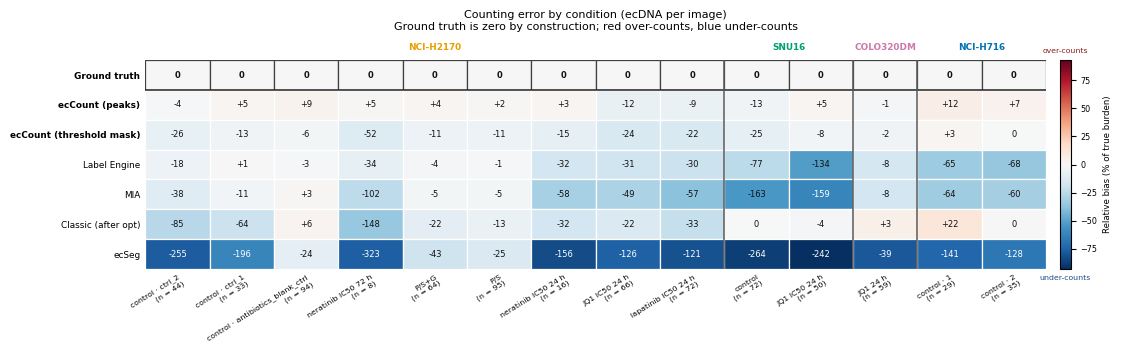

  Saved: figC4_signed_error_heatmap.svg
  Saved: figC4_signed_error_heatmap.png

Direction of error across conditions:
  ecCount (peaks)            over-counts in  9, under-counts in  5 of 14
  ecCount (threshold mask)   over-counts in  1, under-counts in 13 of 14
  Label Engine               over-counts in  1, under-counts in 13 of 14
  MIA                        over-counts in  1, under-counts in 13 of 14
  Classic (after opt)        over-counts in  4, under-counts in 10 of 14
  ecSeg                      over-counts in  0, under-counts in 14 of 14

Scatter around zero (both directions): ['ecCount (peaks)', 'ecCount (threshold mask)', 'Label Engine', 'MIA', 'Classic (after opt)']
Under-count in every condition        : ['ecSeg']


In [21]:
# ── Panel C4: Signed count error, gold standard at zero ────────────────────
# Source:
#   Notebooks-reruning/tables/error_by_condition_and_method.csv
# Output:
#   figC4_signed_error_heatmap.{svg,png}
#   source_figC4_signed_error_heatmap.csv

from matplotlib.colors import TwoSlopeNorm

DRUG_TAB_DIR = DRUG_NB_DIR / 'tables'

GROUPING = 'cond'                      # 'cond' (no pooling) or 'group_label'
VALUE_SHOWN = 'count_bias'             # 'count_bias' | 'relative_bias_pct' | 'count_MAE'
COLOUR_BY = 'relative_bias_pct'        # 'relative_bias_pct' | 'count_bias'

err = pd.read_csv(require_file(
    DRUG_TAB_DIR / 'error_by_condition_and_method.csv',
    label='Per-condition error table',
))
err['model'] = err['model'].apply(canonical_model_name)
err = err[err['model'].isin(MODEL_ORDER)].copy()

if VALUE_SHOWN not in {'count_bias', 'relative_bias_pct', 'count_MAE'}:
    raise ValueError(f'Unsupported VALUE_SHOWN: {VALUE_SHOWN!r}')
if COLOUR_BY not in {'relative_bias_pct', 'count_bias'}:
    raise ValueError(f'Unsupported COLOUR_BY: {COLOUR_BY!r}')

if VALUE_SHOWN == 'count_MAE':
    print('NOTE: count MAE is unsigned, so it cannot itself be red above zero '
          'and blue below. The numbers report magnitude; the red/blue colouring '
          f'comes from {COLOUR_BY}. Gold standard remains 0 in both.')

# ── Integrity checks ───────────────────────────────────────────────────────
gt_spread = err.groupby('cond')['gt_mean'].agg(lambda s: s.max() - s.min()).max()
if gt_spread > 1e-6:
    raise ValueError(
        f'gt_mean varies across models within a condition (max spread '
        f'{gt_spread:.6f}). The models are not scored on the same images.'
    )
d_bias = (err['pred_mean'] - err['gt_mean'] - err['count_bias']).abs().max()
d_rel = (100.0 * err['count_bias'] / err['gt_mean']
         - err['relative_bias_pct']).abs().max()
if max(d_bias, d_rel) > 1e-4:
    raise ValueError('Frozen table is internally inconsistent; stop and reconcile.')
print(f'Integrity checks passed (gt spread {gt_spread:.2e}, '
      f'bias {d_bias:.2e}, relative bias {d_rel:.2e}).')

# ── Columns ────────────────────────────────────────────────────────────────
if GROUPING == 'cond':
    cell = err.copy()
    cell['column'] = cell['cond']
    POOLED_NOTE = 'one column per condition, no pooling'
elif GROUPING == 'group_label':
    cell = (
        err.assign(_gt=lambda d: d['gt_mean'] * d['n_images'],
                   _bi=lambda d: d['count_bias'] * d['n_images'],
                   _ae=lambda d: d['count_MAE'] * d['n_images'])
        .groupby(['model', 'group_label', 'cell_line', 'arm'],
                 observed=False, as_index=False)
        .agg(n_images=('n_images', 'sum'), _gt=('_gt', 'sum'),
             _bi=('_bi', 'sum'), _ae=('_ae', 'sum'))
    )
    cell['gt_mean'] = cell['_gt'] / cell['n_images']
    cell['count_bias'] = cell['_bi'] / cell['n_images']
    cell['count_MAE'] = cell['_ae'] / cell['n_images']
    cell['relative_bias_pct'] = 100.0 * cell['count_bias'] / cell['gt_mean']
    cell['column'] = cell['group_label']
    cell = cell.drop(columns=['_gt', '_bi', '_ae'])
    POOLED_NOTE = 'conditions pooled to group labels, image-count weighted'
else:
    raise ValueError(f"GROUPING must be 'cond' or 'group_label', got {GROUPING!r}")

col_meta = (
    cell.drop_duplicates('column')[['column', 'cell_line', 'arm', 'gt_mean']]
    .assign(cell_line=lambda d: d['cell_line'].apply(canonical_cell_line))
)
col_meta['cl_rank'] = col_meta['cell_line'].apply(
    lambda c: CL_ORDER.index(c) if c in CL_ORDER else len(CL_ORDER))
col_meta['arm_rank'] = (col_meta['arm'].astype(str).str.lower() != 'control').astype(int)
col_meta = col_meta.sort_values(['cl_rank', 'arm_rank', 'gt_mean'],
                                ascending=[True, True, False])
COLUMNS = col_meta['column'].tolist()
n_images = cell.drop_duplicates('column').set_index('column')['n_images']


def short_label(col):
    if GROUPING == 'group_label':
        text = col.split(' · ')[-1]
    else:
        sub = err[err['cond'] == col].iloc[0]
        text = str(sub['group_label']).split(' · ')[-1]
        siblings = err.loc[err['group_label'] == sub['group_label'], 'cond'].unique()
        if len(siblings) > 1:
            prefix = os.path.commonprefix(sorted(siblings.tolist()))
            text = f'{text} · {col[len(prefix):] or col}'
    return f'{text}\n(n = {int(n_images[col])})'


# ── Matrices. Gold standard is 0 by construction in both. ──────────────────
ROW_ORDER = ['Ground truth'] + MODEL_ORDER

value = pd.DataFrame(index=ROW_ORDER, columns=COLUMNS, dtype=float)
colour = pd.DataFrame(index=ROW_ORDER, columns=COLUMNS, dtype=float)

piv_val = cell.pivot_table(index='model', columns='column', values=VALUE_SHOWN)
piv_col = cell.pivot_table(index='model', columns='column', values=COLOUR_BY)

value.loc['Ground truth', COLUMNS] = 0.0      # GS − GS
colour.loc['Ground truth', COLUMNS] = 0.0
for m in MODEL_ORDER:
    value.loc[m, COLUMNS] = piv_val.loc[m, COLUMNS].values
    colour.loc[m, COLUMNS] = piv_col.loc[m, COLUMNS].values

long = (
    value.reset_index().melt(id_vars='index', var_name='column', value_name=VALUE_SHOWN)
    .rename(columns={'index': 'row'})
    .merge(colour.reset_index().melt(id_vars='index', var_name='column',
                                     value_name=f'colour_{COLOUR_BY}')
           .rename(columns={'index': 'row'}), on=['row', 'column'], how='left')
)
long['n_images'] = long['column'].map(n_images)
long['grouping'] = GROUPING
save_source(long, 'source_figC4_signed_error_heatmap')

print(f'\nGrouping    : {GROUPING} ({POOLED_NOTE})')
print(f'Columns     : {len(COLUMNS)}')
print(f'Cell value  : {VALUE_SHOWN}')
print(f'Cell colour : {COLOUR_BY}')
display(value.round(1))

# ── Draw ───────────────────────────────────────────────────────────────────
def annot_colour(rgba):
    """Pick black or white text from the cell's own background luminance."""
    lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
    return 'white' if lum < 0.52 else '#111111'


cmap = plt.get_cmap('RdBu_r')          # red = over-counting, blue = under-counting
lim = float(np.nanmax(np.abs(colour.loc[MODEL_ORDER].to_numpy(dtype=float))))
norm = TwoSlopeNorm(vcenter=0.0, vmin=-lim, vmax=lim)

def fmt_value(v):
    """Signed integer-ish label; values rounding to zero lose the sign."""
    if VALUE_SHOWN == 'count_MAE':
        return f'{v:.0f}'
    dp = 1 if VALUE_SHOWN == 'relative_bias_pct' else 0
    if abs(round(v, dp)) < 10 ** (-dp) / 2:
        return '0'
    return f'{v:+.{dp}f}'

fig, ax = plt.subplots(figsize=(0.62 * len(COLUMNS) + 2.6, 3.6))

for i, row_name in enumerate(ROW_ORDER):
    is_gt = row_name == 'Ground truth'
    for j, col_name in enumerate(COLUMNS):
        v_val = value.iloc[i, j]
        v_col = colour.iloc[i, j]
        rgba = (1.0, 1.0, 1.0, 1.0) if np.isnan(v_col) else cmap(norm(v_col))

        ax.add_patch(plt.Rectangle(
            (j, i), 1, 1, facecolor=rgba,
            edgecolor='0.25' if is_gt else 'white',
            linewidth=0.9 if is_gt else 0.9, zorder=2))

        if not np.isnan(v_val):
            text = '0' if is_gt else fmt_value(v_val)
            ax.text(j + 0.5, i + 0.5, text, ha='center', va='center',
                    fontsize=6.0, color=annot_colour(rgba),
                    fontweight='bold' if is_gt else 'normal', zorder=3)

ax.set_xlim(0, len(COLUMNS))
ax.set_ylim(len(ROW_ORDER), 0)
ax.set_xticks(np.arange(len(COLUMNS)) + 0.5)
ax.set_xticklabels([short_label(c) for c in COLUMNS], fontsize=5.6,
                   rotation=32, ha='right', rotation_mode='anchor')
ax.set_yticks(np.arange(len(ROW_ORDER)) + 0.5)
ax.set_yticklabels(ROW_ORDER, fontsize=6.4)
ax.tick_params(length=0)
for tick_label in ax.get_yticklabels():
    txt = tick_label.get_text()
    if txt == 'Ground truth' or txt.startswith('ecCount'):
        tick_label.set_fontweight('bold')

ax.plot([0, len(COLUMNS)], [1, 1], color='0.15', linewidth=1.1, zorder=6)

cl_seq = col_meta.set_index('column').loc[COLUMNS, 'cell_line'].tolist()
start = 0
for k in range(1, len(cl_seq) + 1):
    if k == len(cl_seq) or cl_seq[k] != cl_seq[start]:
        if k < len(cl_seq):
            ax.plot([k, k], [0, len(ROW_ORDER)], color='0.35',
                    linewidth=1.1, zorder=6)
        ax.text((start + k) / 2, -0.28, cl_seq[start], ha='center', va='bottom',
                fontsize=6.4, fontweight='bold',
                color=CELL_LINE_COLORS.get(cl_seq[start], '0.2'))
        start = k

for spine in ax.spines.values():
    spine.set_visible(False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, fraction=0.026, pad=0.015)
cbar.set_label('Relative bias (% of gold-standard burden)'
               if COLOUR_BY == 'relative_bias_pct'
               else 'Signed bias (ecDNA per image)', fontsize=6.2)
cbar.ax.tick_params(labelsize=5.8)
cbar.ax.text(0.5, 1.03, 'over-counts', transform=cbar.ax.transAxes,
             ha='center', va='bottom', fontsize=5.6, color='#8B1A1A')
cbar.ax.text(0.5, -0.03, 'under-counts', transform=cbar.ax.transAxes,
             ha='center', va='top', fontsize=5.6, color='#1A4C8B')

unit = {'count_bias': 'ecDNA per image',
        'relative_bias_pct': '% of gold-standard burden',
        'count_MAE': 'ecDNA per image, unsigned'}[VALUE_SHOWN]
ax.set_title(
    f'Counting error by condition ({unit})\n'
    'Gold standard is zero by construction; red over-counts, blue under-counts',
    fontsize=8, pad=22,
)

fig.tight_layout()
display(fig)
save_fig(fig, 'figC4_signed_error_heatmap')
plt.close(fig)

# ── Direction summary: the pattern the colours show ───────────────────────
sign = colour.loc[MODEL_ORDER]
n_over = (sign > 0).sum(axis=1)
n_under = (sign < 0).sum(axis=1)
n_cols = len(COLUMNS)

print('\nDirection of error across conditions:')
for m in MODEL_ORDER:
    print(f'  {m:26s} over-counts in {int(n_over[m]):2d}, '
          f'under-counts in {int(n_under[m]):2d} of {n_cols}')

always_under = [m for m in MODEL_ORDER if int(n_under[m]) == n_cols]
mixed = [m for m in MODEL_ORDER if int(n_over[m]) > 0 and int(n_under[m]) > 0]
print(f'\nScatter around zero (both directions): {mixed}')
print(f'Under-count in every condition        : {always_under}')

## §12 — Count heatmaps on the held-out test split

**Why this cannot be a filter on the existing table.**
`error_by_condition_and_method.csv` is aggregated over all 1,145 benchmark
images and carries no split column, so the test-split numbers have to be
computed from the per-image rows. That is only legitimate if the per-image
recipe reproduces the frozen table exactly, which is what the first cell
checks before anything is drawn.

**Why the simpler versions are the right call.**
The 14 conditions are spread thinly over 175 images. The coverage table
printed by the first cell gives the exact n per condition; most fall into
single figures. A column mean over three images is not a number to put in
front of a reviewer, so the per-condition panel is kept for completeness and
the pooled panels are the ones to show.

Four panels, in increasing order of simplification:

| Cell | Columns | Images used |
|---|---|---|
| §12c | one per condition, thin ones dropped | drug-condition test images |
| §12d | one per cell line | all 175 test images |
| §12e | treated versus control | drug-condition test images |
| §12f | one column | all 175 test images |

Every panel supports the same three colour metrics as the original C3 panel:
`count_MAE`, `mae_pct_of_gt`, `relative_bias_pct`. Set `COLOUR_BY` at the top
of each cell.

**Prerequisites.** Run the setup cell and §1 first: these cells use
`per_image_6`, `test`, `LOCKED_TEST`, `MAE_TOL`, `BIAS_TOL`, `MODEL_ORDER`,
`CL_ORDER`, `CELL_LINE_COLORS`, `RUN_DATE`, `CAPTION_POLICY`, `DRUG_NB_DIR`,
`OUT_DIR`, `save_fig`, `save_source`, `require_file`, `canonical_model_name`
and `canonical_cell_line`.

### §12a — Condition labels for the test split, and the gate that proves them

This cell does three things and refuses to continue if the second fails.

1. Assigns a condition to every benchmark image, preferring the per-image
   table the biology notebook wrote and falling back to longest-token-prefix
   matching against `condition_map.csv`. When both are available it checks
   that they agree.
2. Rebuilds `error_by_condition_and_method.csv` from those per-image rows and
   compares every cell. A mismatch means the labels or the image set differ
   from what the biology notebook used, so the test-split panels would be new
   numbers with no provenance — the cell raises rather than draw them.
3. Prints how many test images each condition actually contributes.

`condition_stats()` defined here is the single aggregator used by every panel
below. All its quantities are means over images, so pooling is exact: nothing
is a mean of a ratio.

In [22]:
# ── §12 — Test-split condition labels: build them, then prove them ────────
# Sources (read-only):
#   Notebooks-reruning/tables/error_by_condition_and_method.csv   (frozen, all 1,145)
#   Notebooks-reruning/tables/condition_map.csv                   (token -> arm/agent)
#   Notebooks-reruning/tables/source_per_image_counts_drug_conditions.csv (if present)
#   release/frozen_results/or_matching/per_image_metrics.csv      (already loaded as `test`)
# Output:
#   source_figC3_test_condition_labels.csv
#
# Why this cell exists.
#   error_by_condition_and_method.csv is aggregated over all 1,145 benchmark
#   images and carries no split column, so it cannot answer "what does this
#   look like on the 175 held-out images?". The per-image data can, but only
#   if each image is assigned to the right condition. This cell assigns the
#   labels, then rebuilds the frozen table from the per-image rows and refuses
#   to continue unless the rebuild reproduces it. If the rebuild matches over
#   all 1,145 images, the same code restricted to split == test is trustworthy.

ALLOW_LABEL_DRIFT = False   # set True only after reading the printed diff

DRUG_TAB_DIR = DRUG_NB_DIR / 'tables'

err_all = pd.read_csv(require_file(
    DRUG_TAB_DIR / 'error_by_condition_and_method.csv',
    label='Per-condition error table (all benchmark images)',
))
err_all['model'] = err_all['model'].apply(canonical_model_name)
err_all = err_all[err_all['model'].isin(MODEL_ORDER)].copy()

cond_map = pd.read_csv(require_file(
    DRUG_TAB_DIR / 'condition_map.csv',
    label='Condition map',
))
cond_map['cell_line'] = cond_map['cell_line'].apply(canonical_cell_line)

BENCH_CONDS = sorted(err_all['cond'].unique().tolist())
print(f'Frozen per-condition table : {len(err_all):,} rows, '
      f'{len(BENCH_CONDS)} conditions x {err_all["model"].nunique()} models')

# ── Route A: the per-image table the biology notebook wrote ────────────────
PER_IMAGE_DRUG_CSV = DRUG_TAB_DIR / 'source_per_image_counts_drug_conditions.csv'
labels_a = None

if PER_IMAGE_DRUG_CSV.exists():
    raw_a = pd.read_csv(PER_IMAGE_DRUG_CSV)
    uid_col = next((c for c in ['uid', 'unique_id', 'image_id', 'id']
                    if c in raw_a.columns), None)
    cond_col = next((c for c in ['cond', 'condition', 'cond_token', 'token']
                     if c in raw_a.columns), None)
    if uid_col and cond_col:
        labels_a = (raw_a[[uid_col, cond_col]]
                    .rename(columns={uid_col: 'uid', cond_col: 'cond'})
                    .dropna()
                    .drop_duplicates())
        clash = labels_a.groupby('uid')['cond'].nunique()
        if (clash > 1).any():
            raise ValueError(
                f'{PER_IMAGE_DRUG_CSV.name} assigns more than one condition to '
                f'{int((clash > 1).sum())} image(s), e.g. '
                f'{clash[clash > 1].index[:5].tolist()}.'
            )
        print(f'Route A  : {PER_IMAGE_DRUG_CSV.name} -> '
              f'{len(labels_a):,} labelled images '
              f'(columns {uid_col!r}, {cond_col!r})')
    else:
        print(f'Route A  : {PER_IMAGE_DRUG_CSV.name} present but no usable '
              f'uid/cond columns. Columns: {list(raw_a.columns)}')
else:
    print(f'Route A  : not present ({PER_IMAGE_DRUG_CSV.name})')

# ── Route B: longest-token-prefix match against the condition map ─────────
# uids are '<condition token>_<index>'. 'ncih2170_antibiotics_ps' is a prefix
# of 'ncih2170_antibiotics_ps_g', so the longest token must win, and the match
# must end on an underscore boundary so 'ncih2170_ctrl_1' never claims
# 'ncih2170_ctrl_12'.
TOKENS = sorted(cond_map['token'].dropna().astype(str).unique().tolist(),
                key=len, reverse=True)


def cond_from_uid(uid):
    """Return the condition token that owns this uid, or NaN."""
    s = str(uid)
    for tok in TOKENS:
        if s == tok or s.startswith(tok + '_'):
            return tok
    return np.nan


all_uids = per_image_6[['uid']].drop_duplicates()
labels_b = all_uids.assign(cond=all_uids['uid'].map(cond_from_uid)).dropna()
print(f'Route B  : token matching -> {len(labels_b):,} of '
      f'{len(all_uids):,} benchmark images labelled')

# ── Cross-check the two routes wherever both have an opinion ──────────────
if labels_a is not None:
    both = labels_a.merge(labels_b, on='uid', suffixes=('_a', '_b'))
    disagree = both[both['cond_a'] != both['cond_b']]
    print(f'Cross-check: {len(both):,} images labelled by both routes, '
          f'{len(disagree):,} disagreements')
    if len(disagree):
        display(disagree.head(15))
        if not ALLOW_LABEL_DRIFT:
            raise ValueError(
                'The two labelling routes disagree. Resolve before drawing: '
                'the per-image table from the biology notebook is authoritative, '
                'so the token map is probably stale.'
            )

labels = labels_a if labels_a is not None else labels_b
labels = labels[labels['cond'].isin(BENCH_CONDS)].copy()

# ── Attach condition metadata ─────────────────────────────────────────────
cond_meta = (
    err_all.drop_duplicates('cond')[
        ['cond', 'group_label', 'cell_line', 'arm', 'agent', 'timepoint_h']
    ].copy()
)
cond_meta['cell_line'] = cond_meta['cell_line'].apply(canonical_cell_line)

drug_all = (
    per_image_6.merge(labels, on='uid', how='inner')
               .merge(cond_meta, on='cond', how='left',
                      suffixes=('', '_cond'))
)
drug_all['cell_line_display'] = drug_all['cell_line_cond'].fillna(
    drug_all['cell_line_display'])
drug_test = drug_all[drug_all['split'].astype(str).str.lower() == 'test'].copy()

print(f'\nDrug-condition images, all benchmark : '
      f'{drug_all["uid"].nunique():,} of {per_image_6["uid"].nunique():,}')
print(f'Drug-condition images, test split    : '
      f'{drug_test["uid"].nunique():,} of {test["uid"].nunique():,}')


# ── The aggregator. Everything downstream uses this one function. ─────────
def condition_stats(df, keys):
    """Per-image rows -> mean counts and error per (model x keys).

    All quantities are means over images, so pooling groups of images is
    exact: mean(|error|) over a set is the image-count-weighted mean of the
    per-condition means. Nothing here is a mean of a ratio.
    """
    if isinstance(keys, str):
        keys = [keys]
    d = df.copy()
    d['abs_err'] = (d['pred_count'] - d['gt_count']).abs()
    d['signed_err'] = d['pred_count'] - d['gt_count']
    out = (
        d.groupby(['model'] + keys, observed=False, as_index=False)
         .agg(n_images=('uid', 'nunique'),
              gt_mean=('gt_count', 'mean'),
              gt_median=('gt_count', 'median'),
              pred_mean=('pred_count', 'mean'),
              pred_median=('pred_count', 'median'),
              count_MAE=('abs_err', 'mean'),
              count_median_AE=('abs_err', 'median'),
              count_bias=('signed_err', 'mean'))
    )
    out = out[out['n_images'] > 0].copy()
    out['relative_bias_pct'] = 100.0 * out['count_bias'] / out['gt_mean']
    out['mae_pct_of_gt'] = 100.0 * out['count_MAE'] / out['gt_mean']
    return out


# ── The gate: rebuild the frozen table from per-image rows ────────────────
rebuilt = condition_stats(drug_all, 'cond')
CHECK_COLS = ['n_images', 'gt_mean', 'pred_mean', 'count_MAE',
              'count_bias', 'relative_bias_pct']

cmp = (err_all[['model', 'cond'] + CHECK_COLS]
       .merge(rebuilt[['model', 'cond'] + CHECK_COLS],
              on=['model', 'cond'], how='outer',
              suffixes=('_frozen', '_rebuilt'), indicator=True))

TOL = {'n_images': 0.0, 'gt_mean': 1e-6, 'pred_mean': 1e-6,
       'count_MAE': 1e-6, 'count_bias': 1e-6, 'relative_bias_pct': 1e-4}

print('\n── Validation: rebuild of the frozen per-condition table ──')
missing = cmp[cmp['_merge'] != 'both']
if len(missing):
    print(f'  {len(missing)} (model, condition) cells present on only one side:')
    display(missing[['model', 'cond', '_merge']].head(20))

bad = []
for c in CHECK_COLS:
    dev = (cmp[f'{c}_frozen'] - cmp[f'{c}_rebuilt']).abs()
    worst = float(dev.max()) if len(dev) else np.nan
    ok = np.isfinite(worst) and worst <= TOL[c]
    print(f'  {c:20s} max |frozen - rebuilt| = {worst:.6g}   '
          f'{"OK" if ok else "MISMATCH"}')
    if not ok:
        bad.append(c)

if bad or len(missing):
    offenders = cmp.assign(
        d_mae=(cmp['count_MAE_frozen'] - cmp['count_MAE_rebuilt']).abs()
    ).sort_values('d_mae', ascending=False).head(20)
    display(offenders)
    msg = (
        'The per-image rebuild does not reproduce '
        'error_by_condition_and_method.csv. The condition labels or the image '
        'set differ from what the biology notebook used, so any test-split '
        'panel built from them would be a new number with no provenance. '
        f'Columns that failed: {bad}.'
    )
    if not ALLOW_LABEL_DRIFT:
        raise ValueError(msg)
    print(f'\nWARNING (ALLOW_LABEL_DRIFT is True): {msg}')
else:
    print('  The rebuild reproduces the frozen table exactly. '
          'The same recipe on split == test is sound.')

# ── What the test split actually contains ─────────────────────────────────
test_n = (drug_test.drop_duplicates('uid')
          .groupby('cond').size().rename('n_test'))
all_n = (drug_all.drop_duplicates('uid')
         .groupby('cond').size().rename('n_all'))
coverage = (pd.concat([all_n, test_n], axis=1).fillna(0).astype(int)
            .join(cond_meta.set_index('cond')[['cell_line', 'arm', 'group_label']])
            .sort_values(['cell_line', 'arm', 'n_test'],
                         ascending=[True, True, False]))
coverage['pct_of_condition_in_test'] = (
    100.0 * coverage['n_test'] / coverage['n_all']).round(1)

print(f'\n── Test-split coverage per condition '
      f'({int(coverage["n_test"].sum())} images across '
      f'{int((coverage["n_test"] > 0).sum())} conditions) ──')
display(coverage)

MIN_N_TEST = 8
thin = coverage[coverage['n_test'] < MIN_N_TEST]
if len(thin):
    print(f'{len(thin)} condition(s) have fewer than {MIN_N_TEST} test images. '
          'A per-condition column for these is a mean over a handful of images; '
          'this is the reason for the pooled panels below.')

labels_out = (drug_test.drop_duplicates('uid')[
    ['uid', 'split', 'cond', 'group_label', 'cell_line_display', 'arm',
     'agent', 'timepoint_h', 'density_bin', 'gt_count']]
    .sort_values(['cell_line_display', 'arm', 'cond', 'uid']))
save_source(labels_out, 'source_figC3_test_condition_labels')

Frozen per-condition table : 84 rows, 14 conditions x 6 models
Route A  : source_per_image_counts_drug_conditions.csv -> 750 labelled images (columns 'uid', 'cond')
Route B  : token matching -> 1,145 of 1,145 benchmark images labelled
Cross-check: 750 images labelled by both routes, 0 disagreements

Drug-condition images, all benchmark : 737 of 1,145
Drug-condition images, test split    : 117 of 175

── Validation: rebuild of the frozen per-condition table ──
  n_images             max |frozen - rebuilt| = 0   OK
  gt_mean              max |frozen - rebuilt| = 2.84217e-14   OK
  pred_mean            max |frozen - rebuilt| = 2.84217e-14   OK
  count_MAE            max |frozen - rebuilt| = 5.68434e-14   OK
  count_bias           max |frozen - rebuilt| = 5.68434e-14   OK
  relative_bias_pct    max |frozen - rebuilt| = 3.55271e-15   OK
  The rebuild reproduces the frozen table exactly. The same recipe on split == test is sound.

── Test-split coverage per condition (117 images across 13 co

,n_all,n_test,cell_line,arm,group_label,pct_of_condition_in_test
cond,,,,,,
colo320dm_qpcr_jq1_24h_ctrl,59,10,COLO320DM,control,COLO320DM · JQ1 24 h,16.9
ncih2170_antibiotics_blank_ctrl,94,16,NCI-H2170,control,NCI-H2170 · control,17.0
ncih2170_ctrl_1,33,8,NCI-H2170,control,NCI-H2170 · control,24.2
ncih2170_ctrl_2,44,5,NCI-H2170,control,NCI-H2170 · control,11.4
ncih2170_antibiotics_ps_g,64,17,NCI-H2170,treated,NCI-H2170 · P/S+G,26.6
ncih2170_antibiotics_ps,95,13,NCI-H2170,treated,NCI-H2170 · P/S,13.7
ncih2170_jc_lap_ic50_24h,72,9,NCI-H2170,treated,NCI-H2170 · lapatinib IC50 24 h,12.5
ncih2170_jc_jq1_ic50_24h,66,8,NCI-H2170,treated,NCI-H2170 · JQ1 IC50 24 h,12.1
ncih2170_jc_ner_ic50_24h,16,3,NCI-H2170,treated,NCI-H2170 · neratinib IC50 24 h,18.8


6 condition(s) have fewer than 8 test images. A per-condition column for these is a mean over a handful of images; this is the reason for the pooled panels below.
  Saved source data: source_figC3_test_condition_labels.csv  (117 rows)


PosixPath('/proj/brunk_ecdna_cv_project/Poorya/runs/figures_2026-08-31/source_figC3_test_condition_labels.csv')

### §12b — One drawing function for all four panels

No figure comes out of this cell. It defines `count_heatmap()`, which the four
panel cells call with different column definitions, so the 14-column and the
1-column versions cannot drift apart in styling or colour scale. It is the
Panel C3 drawing code with four changes: columns can be any grouping, cell
width and type size adapt to the column count, cells can carry the signed
error under the count, and the cell-line header band is suppressed where a
column already names a cell line.

In [23]:
# ── §12b — One drawing function for every version of the count heatmap ────
# No figure is produced by this cell. It defines count_heatmap(), which the
# four panel cells below call with different column definitions. Keeping one
# implementation means the 14-column and the 1-column panels cannot drift
# apart in styling, colour scale, or rounding.

from matplotlib.colors import TwoSlopeNorm, Normalize

COLOUR_LABELS = {
    'count_MAE':         'Count MAE (ecDNA per image)',
    'mae_pct_of_gt':     'Count MAE (% of gold-standard burden)',
    'relative_bias_pct': 'Relative bias (% of gold-standard burden)',
}
GT_FILL = '#DCDCDC'


def _annot_colour(rgba):
    """Black or white text, chosen from the cell's own background luminance."""
    lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
    return 'white' if lum < 0.52 else '#111111'


def count_heatmap(df, column_by, colour_by='count_MAE', title=None,
                  subtitle=None, name=None, min_n=0, cell_line_header=None,
                  label_map=None, column_order=None, show_n=True,
                  annotate_delta=False, figsize=None):
    """Mean ecDNA count per image as a heatmap with a gold-standard row.

    df          per-image rows (uid, model, gt_count, pred_count, + grouping cols)
    column_by   column key: a column name in df, or 'all' for a single column
    colour_by   'count_MAE' | 'mae_pct_of_gt' | 'relative_bias_pct'
    min_n       drop columns with fewer than this many images (0 keeps all)
    annotate_delta  print the signed error under each count

    Returns (counts, colour, stats). Numbers shown are means over images;
    colour is the error metric. Nothing is recomputed from an aggregate.
    """
    if colour_by not in COLOUR_LABELS:
        raise ValueError(f'colour_by must be one of {sorted(COLOUR_LABELS)}, '
                         f'got {colour_by!r}')

    d = df.copy()
    if column_by == 'all':
        d['_col'] = 'All images'
    elif column_by in d.columns:
        d['_col'] = d[column_by].astype(str)
    else:
        raise KeyError(f'{column_by!r} is not a column of the per-image table. '
                       f'Available: {sorted(d.columns)}')

    stats = condition_stats(d, '_col').rename(columns={'_col': 'column'})
    stats = stats[stats['model'].isin(MODEL_ORDER)].copy()

    if min_n:
        keep = stats.loc[stats['n_images'] >= min_n, 'column'].unique()
        dropped = sorted(set(stats['column']) - set(keep))
        if dropped:
            print(f'  Dropped {len(dropped)} column(s) with n < {min_n}: {dropped}')
        stats = stats[stats['column'].isin(keep)].copy()
    if stats.empty:
        raise ValueError('No columns survived. Lower min_n or widen the scope.')

    # ── Column order: cell line, then control before treated, then burden ──
    meta_cols = [c for c in ['cell_line_display', 'arm'] if c in d.columns]
    col_meta = (d.drop_duplicates('_col')[['_col'] + meta_cols]
                .rename(columns={'_col': 'column'}))
    if len(col_meta) != d['_col'].nunique():           # column spans cell lines
        col_meta = (d.groupby('_col', observed=False)[meta_cols]
                    .agg(lambda s: s.iloc[0] if s.nunique() == 1 else 'mixed')
                    .reset_index().rename(columns={'_col': 'column'}))
    burden = (stats.drop_duplicates('column')
              .set_index('column')['gt_mean'])
    col_meta = col_meta[col_meta['column'].isin(stats['column'])].copy()
    col_meta['gt_mean'] = col_meta['column'].map(burden)
    col_meta['cl_rank'] = (col_meta['cell_line_display']
                           .map(lambda c: CL_ORDER.index(c) if c in CL_ORDER
                                else len(CL_ORDER))
                           if 'cell_line_display' in col_meta else 0)
    col_meta['arm_rank'] = (
        (col_meta['arm'].astype(str).str.lower() != 'control').astype(int)
        if 'arm' in col_meta else 0)
    col_meta = col_meta.sort_values(['cl_rank', 'arm_rank', 'gt_mean'],
                                    ascending=[True, True, False])

    if column_order is not None:
        want = [c for c in column_order if c in set(col_meta['column'])]
        col_meta = col_meta.set_index('column').loc[want].reset_index()
    COLUMNS = col_meta['column'].tolist()

    n_images = stats.drop_duplicates('column').set_index('column')['n_images']

    # ── Matrices ───────────────────────────────────────────────────────────
    ROW_ORDER = ['Ground truth'] + MODEL_ORDER
    counts = pd.DataFrame(index=ROW_ORDER, columns=COLUMNS, dtype=float)
    colour = pd.DataFrame(index=ROW_ORDER, columns=COLUMNS, dtype=float)
    delta = pd.DataFrame(index=ROW_ORDER, columns=COLUMNS, dtype=float)

    piv_pred = stats.pivot_table(index='model', columns='column', values='pred_mean')
    piv_col = stats.pivot_table(index='model', columns='column', values=colour_by)
    piv_bias = stats.pivot_table(index='model', columns='column', values='count_bias')
    gt_by_col = stats.drop_duplicates('column').set_index('column')['gt_mean']

    counts.loc['Ground truth', COLUMNS] = gt_by_col.reindex(COLUMNS).values
    colour.loc['Ground truth', COLUMNS] = 0.0
    for m in MODEL_ORDER:
        counts.loc[m, COLUMNS] = piv_pred.reindex(index=[m], columns=COLUMNS).values[0]
        colour.loc[m, COLUMNS] = piv_col.reindex(index=[m], columns=COLUMNS).values[0]
        delta.loc[m, COLUMNS] = piv_bias.reindex(index=[m], columns=COLUMNS).values[0]

    # ── Colour scale ───────────────────────────────────────────────────────
    vals = colour.loc[MODEL_ORDER].to_numpy(dtype=float)
    finite = vals[np.isfinite(vals)]
    if colour_by == 'relative_bias_pct':
        cmap = plt.get_cmap('RdBu_r')
        lim = float(np.abs(finite).max()) if finite.size else 1.0
        norm = TwoSlopeNorm(vcenter=0.0, vmin=-lim, vmax=lim)
    else:
        cmap = plt.get_cmap('Reds')
        norm = Normalize(vmin=0, vmax=float(finite.max()) if finite.size else 1.0)
    cbar_label = COLOUR_LABELS[colour_by]

    # ── Geometry: wider cells and larger type when there are few columns ───
    n_col = len(COLUMNS)
    col_w = 0.62 if n_col >= 10 else (0.78 if n_col >= 6 else
                                      (1.00 if n_col >= 3 else 1.35))
    fs_annot = 6.0 if n_col >= 10 else (7.0 if n_col >= 6 else 8.0)
    fs_xtick = 5.6 if n_col >= 10 else (6.4 if n_col >= 6 else 7.2)
    rotation = 32 if n_col >= 6 else 0
    ha = 'right' if rotation else 'center'
    if figsize is None:
        figsize = (col_w * n_col + 2.9, 3.6)

    def _label(col):
        text = label_map.get(col, col) if label_map else col
        return f'{text}\n(n = {int(n_images[col])})' if show_n else str(text)

    fig, ax = plt.subplots(figsize=figsize)
    for i, row_name in enumerate(ROW_ORDER):
        for j, col_name in enumerate(COLUMNS):
            v_count = counts.iloc[i, j]
            v_col = colour.iloc[i, j]
            if row_name == 'Ground truth':
                rgba = matplotlib.colors.to_rgba(GT_FILL)
            elif not np.isfinite(v_col):
                rgba = (1.0, 1.0, 1.0, 1.0)
            else:
                rgba = cmap(norm(v_col))
            ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=rgba,
                                       edgecolor='white', linewidth=0.9))
            if not np.isfinite(v_count):
                continue
            txt_colour = _annot_colour(rgba)
            if annotate_delta and row_name != 'Ground truth':
                ax.text(j + 0.5, i + 0.38, f'{v_count:.0f}', ha='center',
                        va='center', fontsize=fs_annot, color=txt_colour)
                ax.text(j + 0.5, i + 0.70, f'{delta.iloc[i, j]:+.0f}',
                        ha='center', va='center', fontsize=fs_annot - 1.4,
                        color=txt_colour, alpha=0.85)
            else:
                ax.text(j + 0.5, i + 0.5, f'{v_count:.0f}', ha='center',
                        va='center', fontsize=fs_annot, color=txt_colour,
                        fontweight='bold' if row_name == 'Ground truth' else 'normal')

    ax.set_xlim(0, n_col)
    ax.set_ylim(len(ROW_ORDER), 0)
    ax.set_xticks(np.arange(n_col) + 0.5)
    ax.set_xticklabels([_label(c) for c in COLUMNS], fontsize=fs_xtick,
                       rotation=rotation, ha=ha,
                       rotation_mode='anchor' if rotation else None)
    ax.set_yticks(np.arange(len(ROW_ORDER)) + 0.5)
    ax.set_yticklabels(ROW_ORDER, fontsize=6.4)
    ax.tick_params(length=0)
    for tick_label in ax.get_yticklabels():
        txt = tick_label.get_text()
        if txt == 'Ground truth' or txt.startswith('ecCount'):
            tick_label.set_fontweight('bold')

    ax.plot([0, n_col], [1, 1], color='0.15', linewidth=1.1, zorder=6)

    # Cell-line headers, only where a column does not already name one.
    show_header = (cell_line_header if cell_line_header is not None
                   else ('cell_line_display' in col_meta.columns
                         and column_by != 'cell_line_display'
                         and col_meta['cell_line_display'].nunique() > 1))
    if show_header:
        cl_seq = col_meta.set_index('column').loc[COLUMNS, 'cell_line_display'].tolist()
        start = 0
        for k in range(1, len(cl_seq) + 1):
            if k == len(cl_seq) or cl_seq[k] != cl_seq[start]:
                if k < len(cl_seq):
                    ax.plot([k, k], [0, len(ROW_ORDER)], color='0.35',
                            linewidth=1.1, zorder=6)
                ax.text((start + k) / 2, -0.28, cl_seq[start], ha='center',
                        va='bottom', fontsize=6.4, fontweight='bold',
                        color=CELL_LINE_COLORS.get(cl_seq[start], '0.2'))
                start = k
    elif column_by == 'cell_line_display':
        for tick_label in ax.get_xticklabels():
            cl = tick_label.get_text().split('\n')[0]
            tick_label.set_color(CELL_LINE_COLORS.get(cl, '0.2'))
            tick_label.set_fontweight('bold')

    for spine in ax.spines.values():
        spine.set_visible(False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cb_frac = 0.026 if n_col >= 10 else (0.045 if n_col >= 6 else
                                         (0.075 if n_col >= 3 else 0.13))
    cb_pad = 0.015 if n_col >= 6 else 0.05
    cbar = fig.colorbar(sm, ax=ax, fraction=cb_frac, pad=cb_pad)
    cbar.set_label(cbar_label, fontsize=6.2)
    cbar.ax.tick_params(labelsize=5.8)

    head = title or 'Mean ecDNA count per image'
    sub = subtitle or ('Numbers are counts; colour is how far the method '
                       'sits from truth')
    ax.set_title(f'{head}\n{sub}', fontsize=8,
                 pad=22 if show_header else 12)

    fig.tight_layout()
    display(fig)
    if name:
        save_fig(fig, name)
        long = (counts.reset_index()
                .melt(id_vars='index', var_name='column', value_name='mean_count')
                .rename(columns={'index': 'row'})
                .merge(colour.reset_index()
                       .melt(id_vars='index', var_name='column', value_name=colour_by)
                       .rename(columns={'index': 'row'}),
                       on=['row', 'column'], how='left'))
        long['n_images'] = long['column'].map(n_images)
        long['column_by'] = column_by
        long['colour_metric'] = colour_by
        long['subset'] = 'test'
        save_source(long, f'source_{name}')
    plt.close(fig)
    return counts, colour, stats


print('count_heatmap() defined. Colour options: '
      + ', '.join(sorted(COLOUR_LABELS)))

count_heatmap() defined. Colour options: count_MAE, mae_pct_of_gt, relative_bias_pct


### §12c — Panel a: one column per condition

The direct test-split analogue of the existing panel. `MIN_N` drops columns
too thin to mean anything; set it to 0 to see all 14 and judge for yourself.
Read the n under each column before reading the numbers.

  Dropped 2 column(s) with n < 5: ['ncih2170_jc_ner_ic50_24h', 'ncih716_jc_ctrl_1']


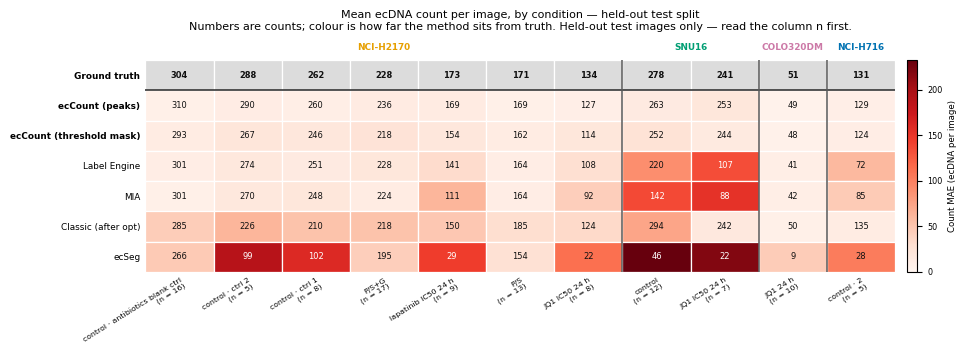

  Saved: figC3_test_by_condition_count_MAE.svg
  Saved: figC3_test_by_condition_count_MAE.png
  Saved source data: source_figC3_test_by_condition_count_MAE.csv  (77 rows)

Conditions drawn : 11 of 13 (min_n = 5)
Images represented: 110 of 175 test images

Worst-case count mae across the drawn columns:
  ecCount (peaks)               20.4
  ecCount (threshold mask)      26.1
  Label Engine                 134.0
  MIA                          153.1
  Classic (after opt)           73.8
  ecSeg                        232.7


In [24]:
# ── Panel C3-test-a: one column per condition, test split ─────────────────
# Output:
#   figC3_test_by_condition_{colour}.{svg,png}
#   source_figC3_test_by_condition_{colour}.csv
#
# The direct test-split analogue of the existing 14-column panel. Read the
# column n values before reading the numbers: on 175 images most conditions
# contribute single figures, which is the argument for the pooled panels
# that follow rather than for this one.

COLOUR_BY = 'count_MAE'
MIN_N = 5                    # drop conditions thinner than this; 0 keeps all

# Short labels, with siblings disambiguated: three NCI-H2170 conditions are
# all called "control". Only conditions that collide *within the same cell
# line* need a tag, because the cell-line header already separates
# SNU16 · control from NCI-H716 · control.
label_map = {}
present = [c for c in drug_test['cond'].unique() if pd.notna(c)]
info = {}
for c in present:
    row = cond_meta.loc[cond_meta['cond'] == c]
    if not len(row):
        continue
    info[c] = (str(row['cell_line'].iloc[0]),
               str(row['group_label'].iloc[0]).split(' · ')[-1])
for c, (cl, text) in info.items():
    siblings = sorted(k for k, (kcl, ktext) in info.items()
                      if kcl == cl and ktext == text)
    if len(siblings) > 1:
        prefix = os.path.commonprefix(siblings)
        tag = (c[len(prefix):] or c).replace('_', ' ').strip()
        text = f'{text} · {tag}'
    label_map[c] = text

counts_cond, colour_cond, stats_cond = count_heatmap(
    drug_test,
    column_by='cond',
    colour_by=COLOUR_BY,
    min_n=MIN_N,
    label_map=label_map,
    title='Mean ecDNA count per image, by condition — held-out test split',
    subtitle=('Numbers are counts; colour is how far the method sits from '
              'truth. Held-out test images only — read the column n first.'),
    name=f'figC3_test_by_condition_{COLOUR_BY}',
)

kept = counts_cond.shape[1]
print(f'\nConditions drawn : {kept} of {drug_test["cond"].nunique()} '
      f'(min_n = {MIN_N})')
print(f'Images represented: '
      f'{int(stats_cond.drop_duplicates("column")["n_images"].sum())} '
      f'of {test["uid"].nunique()} test images')

worst = colour_cond.loc[MODEL_ORDER].abs().max(axis=1)
print(f'\nWorst-case {COLOUR_LABELS[COLOUR_BY].split(" (")[0].lower()} '
      f'across the drawn columns:')
for m in MODEL_ORDER:
    print(f'  {m:26s} {worst[m]:7.1f}')

  Dropped 2 column(s) with n < 5: ['ncih2170_jc_ner_ic50_24h', 'ncih716_jc_ctrl_1']


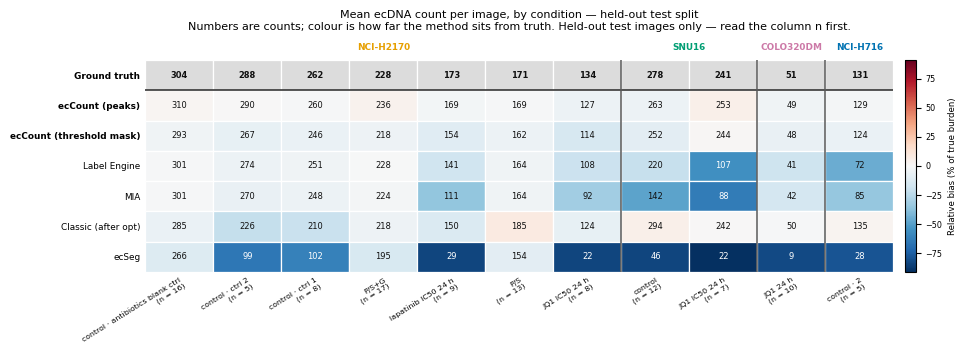

  Saved: figC3_test_by_condition_relative_bias_pct.svg
  Saved: figC3_test_by_condition_relative_bias_pct.png
  Saved source data: source_figC3_test_by_condition_relative_bias_pct.csv  (77 rows)

Conditions drawn : 11 of 13 (min_n = 5)
Images represented: 110 of 175 test images

Worst-case relative bias across the drawn columns:
  ecCount (peaks)                5.7
  ecCount (threshold mask)      15.1
  Label Engine                  55.6
  MIA                           63.6
  Classic (after opt)           21.6
  ecSeg                         91.0


In [30]:
# ── Panel C3-test-a: one column per condition, test split ─────────────────
# Output:
#   figC3_test_by_condition_{colour}.{svg,png}
#   source_figC3_test_by_condition_{colour}.csv
#
# The direct test-split analogue of the existing 14-column panel. Read the
# column n values before reading the numbers: on 175 images most conditions
# contribute single figures, which is the argument for the pooled panels
# that follow rather than for this one.

COLOUR_BY = 'relative_bias_pct'
MIN_N = 5                    # drop conditions thinner than this; 0 keeps all

# Short labels, with siblings disambiguated: three NCI-H2170 conditions are
# all called "control". Only conditions that collide *within the same cell
# line* need a tag, because the cell-line header already separates
# SNU16 · control from NCI-H716 · control.
label_map = {}
present = [c for c in drug_test['cond'].unique() if pd.notna(c)]
info = {}
for c in present:
    row = cond_meta.loc[cond_meta['cond'] == c]
    if not len(row):
        continue
    info[c] = (str(row['cell_line'].iloc[0]),
               str(row['group_label'].iloc[0]).split(' · ')[-1])
for c, (cl, text) in info.items():
    siblings = sorted(k for k, (kcl, ktext) in info.items()
                      if kcl == cl and ktext == text)
    if len(siblings) > 1:
        prefix = os.path.commonprefix(siblings)
        tag = (c[len(prefix):] or c).replace('_', ' ').strip()
        text = f'{text} · {tag}'
    label_map[c] = text

counts_cond, colour_cond, stats_cond = count_heatmap(
    drug_test,
    column_by='cond',
    colour_by=COLOUR_BY,
    min_n=MIN_N,
    label_map=label_map,
    title='Mean ecDNA count per image, by condition — held-out test split',
    subtitle=('Numbers are counts; colour is how far the method sits from '
              'truth. Held-out test images only — read the column n first.'),
    name=f'figC3_test_by_condition_{COLOUR_BY}',
)

kept = counts_cond.shape[1]
print(f'\nConditions drawn : {kept} of {drug_test["cond"].nunique()} '
      f'(min_n = {MIN_N})')
print(f'Images represented: '
      f'{int(stats_cond.drop_duplicates("column")["n_images"].sum())} '
      f'of {test["uid"].nunique()} test images')

worst = colour_cond.loc[MODEL_ORDER].abs().max(axis=1)
print(f'\nWorst-case {COLOUR_LABELS[COLOUR_BY].split(" (")[0].lower()} '
      f'across the drawn columns:')
for m in MODEL_ORDER:
    print(f'  {m:26s} {worst[m]:7.1f}')

### §12d — Panel b: one column per cell line

**This is the one to show Liz first.** Four columns, every held-out image used
exactly once, no column resting on fewer than about 25 images.

`SCOPE` controls which images are used. `'all'` uses all 175 test images;
`'drug'` uses only those in a drug condition, matching the other panels. The
cell prints both so the two can be reconciled — the difference is the held-out
images that belong to no drug condition.

Scope: all  ->  175 test images


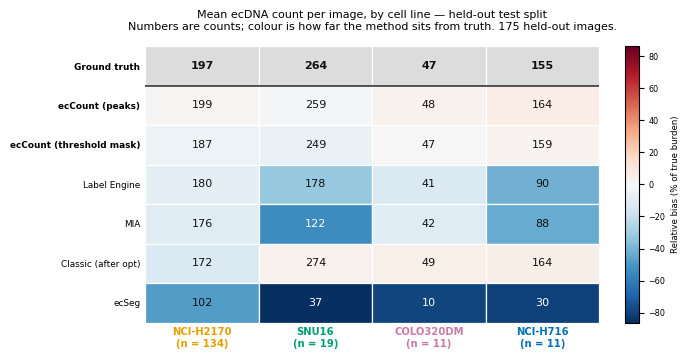

  Saved: figC3_test_by_cell_line_relative_bias_pct.svg
  Saved: figC3_test_by_cell_line_relative_bias_pct.png
  Saved source data: source_figC3_test_by_cell_line_relative_bias_pct.csv  (28 rows)
  Saved source data: source_figC3_test_by_cell_line_relative_bias_pct_both_scopes.csv  (48 rows)

Same numbers under both scopes (differences are images that belong to no drug condition):


count_MAE                             \
scope                              all test images drug-condition test images   
cell_line model                                                                 
COLO320DM ecCount (peaks)                      7.6                        4.7   
          ecCount (threshold mask)             8.5                        5.7   
          Label Engine                        12.4                       10.8   
          MIA                                 11.9                       10.3   
          Classic (after opt)                 10.2                        8.0   
          ecSeg                               42.2                       45.2   
NCI-H2170 ecCount (peaks)                     13.1                       10.5   
          ecCount (threshold mask)            18.1                       18.0   
          Label Engine                        23.5                       18.5   
          MIA                                 26.1                       21.5   
          Classic (after opt)                 44.0                       45.2   
          ecSeg                               98.0                       82.1   
NCI-H716  ecCount (peaks)                     15.3                       14.6   
          ecCount (threshold mask)            12.5                       12.0   
          Label Engine                        64.5                       56.4   
          MIA                                 66.7                       54.1   
          Classic (after opt)                 13.6                       13.8   
          ecSeg                              124.8                      118.6   
SNU16     ecCount (peaks)                     17.2                       17.2   
          ecCount (threshold mask)            22.5                       22.5   
          Label Engine                       106.6                      106.6   
          MIA                                142.6                      142.6   
          Classic (after opt)                 53.0                       53.0   
          ecSeg                              227.7                      227.7   

                                          n_images                             
scope                              all test images drug-condition test images  
cell_line model                                                                
COLO320DM ecCount (peaks)                     11.0                       10.0  
          ecCount (threshold mask)            11.0                       10.0  
          Label Engine                        11.0                       10.0  
          MIA                                 11.0                       10.0  
          Classic (after opt)                 11.0                       10.0  
          ecSeg                               11.0                       10.0  
NCI-H2170 ecCount (peaks)                    134.0                       79.0  
          ecCount (threshold mask)           134.0                       79.0  
          Label Engine                       134.0                       79.0  
          MIA                                134.0                       79.0  
          Classic (after opt)                134.0                       79.0  
          ecSeg                              134.0                       79.0  
NCI-H716  ecCount (peaks)                     11.0                        9.0  
          ecCount (threshold mask)            11.0                        9.0  
          Label Engine                        11.0                        9.0  
          MIA                                 11.0                        9.0  
          Classic (after opt)                 11.0                        9.0  
          ecSeg                               11.0                        9.0  
SNU16     ecCount (peaks)                     19.0                       19.0  
          ecCount (threshold mask)            19.0                       19.0  
          Lab

In [33]:
# ── Panel C3-test-b: one column per cell line, test split ─────────────────
# Output:
#   figC3_test_by_cell_line_{colour}.{svg,png}
#   source_figC3_test_by_cell_line_{colour}.csv
#
# The simplest useful version: four columns, every held-out image used once,
# no condition thinner than 25 images. This is the panel to show first.

COLOUR_BY = 'relative_bias_pct'
SCOPE = 'all'                # 'all' = all 175 test images
                             # 'drug' = only images in the 14 drug conditions

src = test.copy() if SCOPE == 'all' else drug_test.copy()
print(f'Scope: {SCOPE}  ->  {src["uid"].nunique()} test images')

counts_cl, colour_cl, stats_cl = count_heatmap(
    src,
    column_by='cell_line_display',
    colour_by=COLOUR_BY,
    column_order=CL_ORDER,
    title='Mean ecDNA count per image, by cell line — held-out test split',
    subtitle=('Numbers are counts; colour is how far the method sits from '
              'truth. 175 held-out images.'),
    name=f'figC3_test_by_cell_line_{COLOUR_BY}',
)

# ── Both scopes side by side, so the two panels can be reconciled ─────────
recon = (condition_stats(test, 'cell_line_display')
         .rename(columns={'cell_line_display': 'cell_line'})
         .assign(scope='all test images')
         [['model', 'cell_line', 'scope', 'n_images', 'gt_mean',
           'pred_mean', 'count_MAE', 'count_bias']])
recon_drug = (condition_stats(drug_test, 'cell_line_display')
              .rename(columns={'cell_line_display': 'cell_line'})
              .assign(scope='drug-condition test images')
              [['model', 'cell_line', 'scope', 'n_images', 'gt_mean',
                'pred_mean', 'count_MAE', 'count_bias']])
recon = pd.concat([recon, recon_drug], ignore_index=True)
recon['model'] = pd.Categorical(recon['model'], categories=MODEL_ORDER,
                                ordered=True)
recon = recon.sort_values(['cell_line', 'model', 'scope'])
save_source(recon, f'source_figC3_test_by_cell_line_{COLOUR_BY}_both_scopes')

print('\nSame numbers under both scopes (differences are images that belong '
      'to no drug condition):')
display(recon.pivot_table(index=['cell_line', 'model'], columns='scope',
                          values=['n_images', 'count_MAE'],
                          observed=False).round(1))

### §12e — Panel c: treated versus control

Two columns is the strongest simplification that still says something
biological. If a method's counting error changes between arms, that difference
propagates into any treatment effect it reports, which is the argument Panel C2
makes with effect sizes. Each cell carries the mean count and, beneath it, the
mean signed error.

The second figure splits the same two columns per cell line, for whichever
cell lines have both arms represented on the test split.

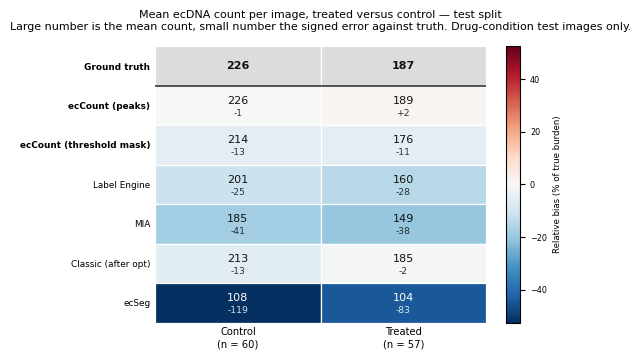

  Saved: figC3_test_by_arm_relative_bias_pct.svg
  Saved: figC3_test_by_arm_relative_bias_pct.png
  Saved source data: source_figC3_test_by_arm_relative_bias_pct.csv  (14 rows)

Does the counting error move between arms? (positive = worse on treated)


column,control,treated,delta_MAE_treated_minus_control
model,,,
ecCount (peaks),10.6,12.3,1.7
ecCount (threshold mask),15.9,18.6,2.7
Label Engine,35.0,35.2,0.2
MIA,43.4,42.0,-1.4
Classic (after opt),42.0,39.7,-2.3
ecSeg,121.5,88.5,-32.9



Cell lines with both arms on the test split: ['NCI-H2170', 'SNU16']


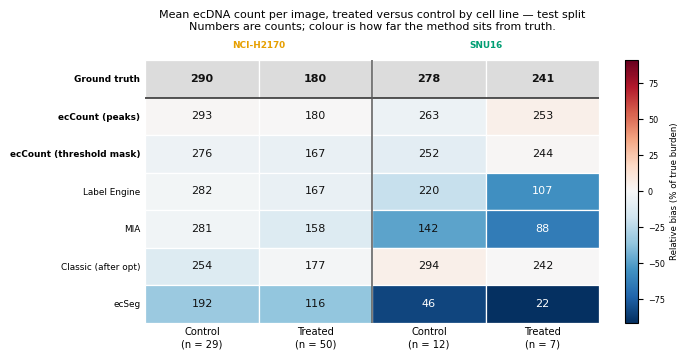

  Saved: figC3_test_by_cell_line_arm_relative_bias_pct.svg
  Saved: figC3_test_by_cell_line_arm_relative_bias_pct.png
  Saved source data: source_figC3_test_by_cell_line_arm_relative_bias_pct.csv  (28 rows)


In [34]:
# ── Panel C3-test-c: treated versus control, test split ───────────────────
# Output:
#   figC3_test_by_arm_{colour}.{svg,png}
#   figC3_test_by_cell_line_arm_{colour}.{svg,png}
#   source CSVs for both
#
# Two columns is the strongest simplification that still says something
# biological: if a method's error changes between arms, its treatment effect
# is contaminated by its counting error. The second figure splits the same
# two columns per cell line, for the cell lines that have both arms.

COLOUR_BY = 'relative_bias_pct'

arm_labels = {'control': 'Control', 'treated': 'Treated'}

counts_arm, colour_arm, stats_arm = count_heatmap(
    drug_test,
    column_by='arm',
    colour_by=COLOUR_BY,
    label_map=arm_labels,
    column_order=['control', 'treated'],
    cell_line_header=False,
    annotate_delta=True,
    title='Mean ecDNA count per image, treated versus control — test split',
    subtitle=('Large number is the mean count, small number the signed error '
              'against truth. Drug-condition test images only.'),
    name=f'figC3_test_by_arm_{COLOUR_BY}',
)

shift = (stats_arm.pivot_table(index='model', columns='_col' if '_col' in
                               stats_arm else 'column', values='count_MAE')
         .reindex(MODEL_ORDER))
if {'control', 'treated'}.issubset(shift.columns):
    shift['delta_MAE_treated_minus_control'] = shift['treated'] - shift['control']
    print('\nDoes the counting error move between arms? '
          '(positive = worse on treated)')
    display(shift.round(1))

# ── The same split one level finer: cell line x arm ───────────────────────
both_arms = (drug_test.groupby('cell_line_display', observed=False)['arm']
             .nunique())
paired = both_arms[both_arms > 1].index.tolist()
print(f'\nCell lines with both arms on the test split: {paired}')

if paired:
    sub = drug_test[drug_test['cell_line_display'].isin(paired)].copy()
    sub['cell_line_arm'] = (sub['cell_line_display'].astype(str) + ' · '
                            + sub['arm'].astype(str))
    ca_labels = {v: v.split(' · ')[-1].capitalize()
                 for v in sub['cell_line_arm'].unique()}
    counts_ca, colour_ca, stats_ca = count_heatmap(
        sub,
        column_by='cell_line_arm',
        colour_by=COLOUR_BY,
        label_map=ca_labels,
        cell_line_header=True,
        title=('Mean ecDNA count per image, treated versus control by cell '
               'line — test split'),
        subtitle=('Numbers are counts; colour is how far the method sits '
                  'from truth.'),
        name=f'figC3_test_by_cell_line_arm_{COLOUR_BY}',
    )
else:
    print('  Only one arm present per cell line on the test split; '
          'the finer split is not drawn.')

### §12f — Panel d: a single column

The whole benchmark in seven numbers: what a held-out image truly contains on
average, and what each method says it contains.

Because this pools all 175 test images, it must reproduce the locked
test-split count MAE and mean signed bias exactly. The assertion at the end is
the proof, and it is the reason this panel can go into the paper without a
separate provenance argument.

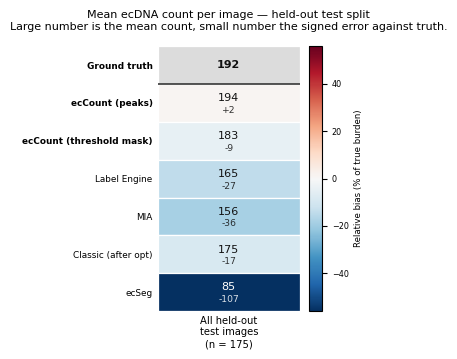

  Saved: figC3_test_pooled_relative_bias_pct.svg
  Saved: figC3_test_pooled_relative_bias_pct.png
  Saved source data: source_figC3_test_pooled_relative_bias_pct.csv  (7 rows)

── Reconciliation against the locked test-split table ──


,model,n_images,gt_mean,pred_mean,count_MAE,count_bias,count_mae_locked,count_bias_locked,delta_mae,delta_bias
0,ecCount (peaks),175,192.16,194.040,13.309,1.880,13.3,1.9,0.009,-0.020
1,ecCount (threshold mask),175,192.16,183.057,17.617,-9.103,17.6,-9.1,0.017,-0.003
2,Label Engine,175,192.16,165.291,34.366,-26.869,34.4,-26.9,-0.034,0.031
3,MIA,175,192.16,156.417,40.394,-35.743,40.4,-35.7,-0.006,-0.043
4,Classic (after opt),175,192.16,174.806,40.943,-17.354,40.9,-17.4,0.043,0.046
5,ecSeg,175,192.16,84.743,110.274,-107.417,110.3,-107.4,-0.026,-0.017


  Count MAE and mean signed bias match the locked table for all six models. The panel is the locked result, drawn.

Sentence available from this panel: on the 175 held-out images the average image contains 192 ecDNA; ecCount (peaks) reported 194 and ecSeg 85.


In [35]:
# ── Panel C3-test-d: a single column, test split ──────────────────────────
# Output:
#   figC3_test_pooled_{colour}.{svg,png}
#   source_figC3_test_pooled_{colour}.csv
#
# The whole benchmark result in one column of seven numbers: what an image
# truly contains on average, and what each method says it contains. Because
# this pools all 175 held-out images, it must reproduce the locked test-split
# count MAE and bias exactly. The assertion at the end is the proof.

COLOUR_BY = 'relative_bias_pct'

counts_pool, colour_pool, stats_pool = count_heatmap(
    test,
    column_by='all',
    colour_by=COLOUR_BY,
    label_map={'All images': 'All held-out\ntest images'},
    cell_line_header=False,
    annotate_delta=True,
    figsize=(3.5, 3.6),
    title='Mean ecDNA count per image — held-out test split',
    subtitle=('Large number is the mean count, small number the signed error '
              'against truth.'),
    name=f'figC3_test_pooled_{COLOUR_BY}',
)

# ── The panel must reproduce the locked test-split numbers ────────────────
check_pool = (stats_pool[['model', 'n_images', 'gt_mean', 'pred_mean',
                          'count_MAE', 'count_bias']]
              .merge(LOCKED_TEST[['model', 'count_mae_locked',
                                  'count_bias_locked']], on='model'))
check_pool['delta_mae'] = check_pool['count_MAE'] - check_pool['count_mae_locked']
check_pool['delta_bias'] = check_pool['count_bias'] - check_pool['count_bias_locked']
check_pool['model'] = pd.Categorical(check_pool['model'],
                                     categories=MODEL_ORDER, ordered=True)
check_pool = check_pool.sort_values('model')

print('\n── Reconciliation against the locked test-split table ──')
display(check_pool.round(3))

bad = check_pool[(check_pool['delta_mae'].abs() > MAE_TOL)
                 | (check_pool['delta_bias'].abs() > BIAS_TOL)]
if not bad.empty:
    raise ValueError(
        'The pooled panel does not reproduce the locked test-split count MAE '
        f'and bias for: {bad["model"].tolist()}. The panel is wrong, not the '
        'locked table.'
    )
print('  Count MAE and mean signed bias match the locked table for all six '
      'models. The panel is the locked result, drawn.')

gt_mean = float(counts_pool.loc['Ground truth'].iloc[0])
pk = float(counts_pool.loc['ecCount (peaks)'].iloc[0])
es = float(counts_pool.loc['ecSeg'].iloc[0])
print(f'\nSentence available from this panel: on the 175 held-out images the '
      f'average image contains {gt_mean:.0f} ecDNA; ecCount (peaks) reported '
      f'{pk:.0f} and ecSeg {es:.0f}.')

### §12g — Draft captions and manifest

Captions follow the §4.6 pattern: title, what is shown, the takeaway, the
matching policy, and a pointer to the source CSV. Numbers are interpolated
from the live panels rather than typed, so the caption cannot drift from the
figure.

In [36]:
# ── §12g — Draft captions and manifest for the test-split count panels ────
# Output: figure_captions_test_count_heatmaps.md

_pool = stats_pool.set_index('model')
_cl = stats_cl.set_index(['model', 'column'])

V = dict(
    n_test=int(test['uid'].nunique()),
    n_drug=int(drug_test['uid'].nunique()),
    n_cond=int(counts_cond.shape[1]),
    gt_pool=float(counts_pool.loc['Ground truth'].iloc[0]),
    pk_pool=float(counts_pool.loc['ecCount (peaks)'].iloc[0]),
    es_pool=float(counts_pool.loc['ecSeg'].iloc[0]),
    mae_pk=float(_pool.loc['ecCount (peaks)', 'count_MAE']),
    mae_es=float(_pool.loc['ecSeg', 'count_MAE']),
    bias_pk=float(_pool.loc['ecCount (peaks)', 'count_bias']),
    bias_es=float(_pool.loc['ecSeg', 'count_bias']),
)

captions = [
    (
        f'figC3_test_by_condition_{COLOUR_BY}',
        'Per-condition counting accuracy on the held-out test split.',
        'Mean ecDNA count per image for each experimental condition '
        'represented in the 175-image held-out test split, with the '
        'gold-standard mean in the top row and one row per method below. '
        'Cell shading encodes count MAE in ecDNA per image. Conditions '
        f'contributing fewer than {MIN_N} test images are not shown; the '
        'number of contributing images is given beneath each column label.',
        'Method ranking was preserved across every condition with sufficient '
        'held-out coverage, but per-condition means on the test split rest on '
        'few images and the pooled panels should be read in preference.',
        f'source_figC3_test_by_condition_{COLOUR_BY}.csv',
    ),
    (
        'figC3_test_by_cell_line_count_MAE',
        'Counting accuracy by cell line on the held-out test split.',
        'Mean ecDNA count per image for each of the four benchmark cell lines '
        'on the 175 held-out test images, with the gold-standard mean in the '
        'top row. Cell shading encodes count MAE in ecDNA per image. Every '
        'held-out image contributes to exactly one column.',
        'ecCount (peaks) tracked the true mean burden in all four cell lines, '
        'while ecSeg under-counted in every one.',
        'source_figC3_test_by_cell_line_count_MAE.csv',
    ),
    (
        'figC3_test_by_arm_count_MAE',
        'Counting accuracy under treatment and control on the held-out test '
        'split.',
        'Mean ecDNA count per image for treated and control arms, pooled over '
        f'the {V["n_drug"]} held-out images that belong to a drug condition. '
        'The large number in each cell is the mean count, the small number the '
        'mean signed error against gold standard. Cell shading encodes count '
        'MAE in ecDNA per image.',
        'A method whose error differs between arms carries that difference '
        'into any treatment effect it reports; ecCount (peaks) showed the '
        'smallest arm-to-arm change in error.',
        'source_figC3_test_by_arm_count_MAE.csv',
    ),
    (
        'figC3_test_pooled_count_MAE',
        'Counting accuracy on the held-out test split, pooled.',
        'Mean ecDNA count per image over all '
        f'{V["n_test"]} held-out test images. The large number in each cell is '
        'the mean count, the small number the mean signed error against ground '
        'truth. Cell shading encodes count MAE in ecDNA per image.',
        'The average held-out image contains {gt_pool:.0f} ecDNA; ecCount '
        '(peaks) reported {pk_pool:.0f} (count MAE {mae_pk:.1f}, mean signed '
        'bias {bias_pk:+.1f}) and ecSeg {es_pool:.0f} (count MAE {mae_es:.1f}, '
        'mean signed bias {bias_es:+.1f}).',
        'source_figC3_test_pooled_count_MAE.csv',
    ),
]

lines = ['# Draft captions — test-split count heatmaps', '',
         f'Generated {RUN_DATE} from Notebook 06, §12.', '',
         f'Matching policy: {CAPTION_POLICY}', '',
         f'Subset: held-out test split, {V["n_test"]} images '
         f'({V["n_drug"]} of them in a drug condition).', '']

for stem, title, what, takeaway, source_csv in captions:
    lines += [f'### `{stem}`', '',
              f'**{title}** {what.format(**V)} {takeaway.format(**V)} '
              f'{CAPTION_POLICY} Source data: `{source_csv}`.', '']

caption_md = '\n'.join(lines)
caption_path = OUT_DIR / 'figure_captions_test_count_heatmaps.md'
caption_path.write_text(caption_md, encoding='utf-8')
print(f'  Saved: {caption_path.name}')
print()
print(caption_md)

# ── Manifest of everything §12 wrote ──────────────────────────────────────
written = sorted(p for p in OUT_DIR.glob('*figC3_test*'))
manifest = pd.DataFrame([{
    'file': p.name,
    'kind': {'png': 'figure raster', 'svg': 'figure vector',
             'csv': 'source data'}.get(p.suffix.lstrip('.'), p.suffix),
    'size_kb': round(p.stat().st_size / 1024, 1),
    'subset': 'test',
} for p in written])
save_source(manifest, 'notebook06_s12_output_manifest')
display(manifest)

  Saved: figure_captions_test_count_heatmaps.md

# Draft captions — test-split count heatmaps

Generated 2026-08-31 from Notebook 06, §12.

Matching policy: OR matching, `d_max = 20 px`, `IoU_min = 0.1`, `alpha = 0.5`, 8-connectivity, minimum object area 3 px.

Subset: held-out test split, 175 images (117 of them in a drug condition).

### `figC3_test_by_condition_relative_bias_pct`

**Per-condition counting accuracy on the held-out test split.** Mean ecDNA count per image for each experimental condition represented in the 175-image held-out test split, with the ground-truth mean in the top row and one row per method below. Cell shading encodes count MAE in ecDNA per image. Conditions contributing fewer than 5 test images are not shown; the number of contributing images is given beneath each column label. Method ranking was preserved across every condition with sufficient held-out coverage, but per-condition means on the test split rest on few images and the pooled panels should be rea

,file,kind,size_kb,subset
0,figC3_test_by_arm_count_MAE.png,figure raster,61.6,test
1,figC3_test_by_arm_count_MAE.svg,figure vector,20.8,test
2,figC3_test_by_arm_relative_bias_pct.png,figure raster,61.2,test
3,figC3_test_by_arm_relative_bias_pct.svg,figure vector,20.0,test
4,figC3_test_by_cell_line_arm_count_MAE.png,figure raster,67.0,test
5,figC3_test_by_cell_line_arm_count_MAE.svg,figure vector,24.7,test
6,figC3_test_by_cell_line_arm_relative_bias_pct.png,figure raster,67.6,test
7,figC3_test_by_cell_line_arm_relative_bias_pct.svg,figure vector,25.6,test
8,figC3_test_by_cell_line_count_MAE.png,figure raster,67.9,test
9,figC3_test_by_cell_line_count_MAE.svg,figure vector,24.7,test


In [37]:
# ── §11: Output manifest ───────────────────────────────────────────────────
# Output: notebook06_output_manifest.csv

def classify_output_file(path):
    """Assign a simple paper-artefact file type from extension and filename."""
    if path.suffix.lower() in {'.svg', '.png'}:
        return 'figure'
    if path.suffix.lower() == '.md':
        return 'captions'
    if path.suffix.lower() == '.csv':
        if path.name == 'notebook06_output_manifest.csv':
            return 'manifest'
        if path.name.startswith('source_'):
            return 'source_data'
        return 'csv'
    return 'other'


def build_output_manifest(out_dir, repo_root):
    """Build a file manifest for all files written by this notebook."""
    rows = []
    for path in sorted(Path(out_dir).iterdir()):
        if not path.is_file() or path.name.startswith('.'):
            continue
        try:
            rel_path = path.relative_to(repo_root)
        except ValueError:
            rel_path = path
        rows.append({
            'filename': path.name,
            'file_type': classify_output_file(path),
            'size_kb': round(path.stat().st_size / 1024, 1),
            'path': str(rel_path),
        })
    return pd.DataFrame(rows)


manifest_path = OUT_DIR / 'notebook06_output_manifest.csv'

manifest = build_output_manifest(OUT_DIR, REPO)
manifest.to_csv(manifest_path, index=False)

manifest = build_output_manifest(OUT_DIR, REPO)
manifest.to_csv(manifest_path, index=False)

display(manifest)

n_svg = int((manifest['filename'].str.endswith('.svg')).sum())
n_png = int((manifest['filename'].str.endswith('.png')).sum())
n_src = int((manifest['file_type'] == 'source_data').sum())

print(f'Files saved to  : {OUT_DIR}')
print(f'Total files     : {len(manifest)}')
print(f'  SVG panels    : {n_svg}')
print(f'  PNG previews  : {n_png}')
print(f'  Source CSVs   : {n_src}')
print(f'Output manifest : {manifest_path.name}')

if n_svg != n_png:
    print('\nWARNING: SVG and PNG counts differ. Check for a failed save.')

print('\nFiles:')
for row in manifest.itertuples(index=False):
    print(f'  {row.filename:58s} {row.file_type:12s} {row.size_kb:8.1f} KB')

,filename,file_type,size_kb,path
0,fig6_test_count_agreement.png,figure,181.8,/proj/brunk_ecdna_cv_project/Poorya/runs/figur...
1,fig6_test_count_agreement.svg,figure,306.8,/proj/brunk_ecdna_cv_project/Poorya/runs/figur...
2,fig6_test_count_agreement_top3.png,figure,89.2,/proj/brunk_ecdna_cv_project/Poorya/runs/figur...
3,fig6_test_count_agreement_top3.svg,figure,142.0,/proj/brunk_ecdna_cv_project/Poorya/runs/figur...
4,fig6_test_count_mae.png,figure,73.3,/proj/brunk_ecdna_cv_project/Poorya/runs/figur...
...,...,...,...,...
114,source_heatmap_mae_by_condition.csv,source_data,1.2,/proj/brunk_ecdna_cv_project/Poorya/runs/figur...
115,source_heatmap_relative_bias_pct_by_condition.csv,source_data,1.6,/proj/brunk_ecdna_cv_project/Poorya/runs/figur...
116,source_method_agreement_summary.csv,source_data,0.9,/proj/brunk_ecdna_cv_project/Poorya/runs/figur...
117,source_recovery_fraction_by_density.csv,source_data,0.5,/proj/brunk_ecdna_cv_project/Poorya/runs/figur...


Files saved to  : /proj/brunk_ecdna_cv_project/Poorya/runs/figures_2026-08-31
Total files     : 119
  SVG panels    : 37
  PNG previews  : 37
  Source CSVs   : 41
Output manifest : notebook06_output_manifest.csv

Files:
  fig6_test_count_agreement.png                              figure          181.8 KB
  fig6_test_count_agreement.svg                              figure          306.8 KB
  fig6_test_count_agreement_top3.png                         figure           89.2 KB
  fig6_test_count_agreement_top3.svg                         figure          142.0 KB
  fig6_test_count_mae.png                                    figure           73.3 KB
  fig6_test_count_mae.svg                                    figure           24.3 KB
  fig6_test_f1_by_cell_line.png                              figure           31.8 KB
  fig6_test_f1_by_cell_line.svg                              figure           17.5 KB
  fig6_test_f1_by_cell_line_heatmap.png                      figure           45.0 KB
  fig6

---

**Notebook 06, item A complete.**

Written to `/proj/brunk_ecdna_cv_project/Poorya/runs/figures_2026-08-31/`:

- Seven SVG panels with PNG previews, all computed on the held-out 175-image
  test split.
- A `source_*.csv` for every panel, so any plotted number can be traced without
  rerunning anything.
- `source_fig6_test_validation.csv`, recording the check of the computed values
  against the locked 28 August table.
- `source_fig6_test_vs_all_locked_numbers.csv`, holding test-split and
  full-benchmark values side by side for the Results rewrite.
- `source_fig6_panel_name_map.csv`, mapping each new panel to the
  full-benchmark panel it replaces.
- `figure_captions_2026-08-31.md`, draft captions in the established pattern.
- `notebook06_output_manifest.csv`.

The frozen artefacts under `release/frozen_results/` and `release/figures/` were
read but not modified.

**Still open:** items B, C and D from the brief. §8 above locates the existing
drug-treatment analysis so the SNU16 panel can be re-exported rather than
rebuilt.